In [1]:
siamese_accuracies = []
siamese_precisions = []
siamese_recalls = []
siamese_f1s = []

diplomski_accuracies = []
diplomski_precisions = []
diplomski_recalls = []
diplomski_f1s = []

ExoplANNET_accuracies = []
ExoplANNET_precisions = []
ExoplANNET_recalls = []
ExoplANNET_f1s = []

In [2]:
# from astropy.timeseries import LombScargle
# from scipy.interpolate import interp1d
# from scipy.signal import resample



# for seed in range(42, 47):
#     def seed_everything(seed):
#         import random
#         import torch
#         import numpy as np
    
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = True
    
#     seed_everything(seed)
    
#     import pandas as pd
#     import numpy as np
#     import re
    
#     def parse_image(image_str):
#         image_str = image_str.strip('[] ')
        
#         rows = re.split(r'\]\s*\[', image_str)
#         array = []
#         for row in rows:
#             elements = row.split()
#             array.append([float(e) for e in elements])
#         return np.array(array)
    
#     df = pd.read_csv('/kaggle/input/harps-images/data.csv', converters={'image': parse_image})
#     hires_images = pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs.csv', converters={'image': parse_image})
#     hires_df = pd.DataFrame(pd.read_csv('/kaggle/input/harps-n-dataset/preprocessed_HIRES_data.csv'))
    
#     from torchvision import transforms
    
    
    
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#     ])
    
#     import torch
#     from torch.utils.data import DataLoader, Dataset
#     from sklearn.model_selection import train_test_split
#     import random
    
    
    
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")
    
    
#     positives = df[df['label'] == 1].sample(n=205)
#     negatives = df[df['label'] == 0].sample(n=205)
    
    
#     # train_pos, temp_pos = train_test_split(positives, test_size=0.3, random_state=42)
#     # val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=42)
    
#     # train_neg, temp_neg = train_test_split(negatives, test_size=0.3, random_state=42)
#     # val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=42)
    
    
#     train_pos, temp_pos = train_test_split(positives, test_size=0.4, random_state=seed)
#     val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=seed)  
    
#     train_neg, temp_neg = train_test_split(negatives, test_size=0.4, random_state=seed)
#     val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=seed)  
    
#     # train_pos, val_pos = train_test_split(positives, test_size = 0.3, random_state = 42)
#     # train_neg, val_neg = train_test_split(negatives, test_size = 0.3, random_state = 42)
    
    
    
#     hires_positives = hires_images[hires_images['label'] == 1].sample(n=99)
#     hires_negatives = hires_images[hires_images['label'] == 0].sample(n=99)
    
#     hires_train_pos, hires_temp_pos = train_test_split(hires_positives, test_size=0.4, random_state=seed)
#     hires_val_pos, hires_test_pos = train_test_split(hires_temp_pos, test_size=0.5, random_state=seed)  
    
#     hires_train_neg, hires_temp_neg = train_test_split(hires_negatives, test_size=0.4, random_state=seed)
#     hires_val_neg, hires_test_neg = train_test_split(hires_temp_neg, test_size=0.5, random_state=seed)
    
#     # def generate_pairs(pos_df, neg_df):
#     #     pairs = []
#     #     neg_pairs = []
#     #     labels = []
        
#     #     for i in range(0, len(pos_df)):
#     #         image1 = pos_df.iloc[i][1]
#     #         for j in range(i + 1, len(pos_df)):
#     #             image2 = pos_df.iloc[j][1]
#     #             pairs.append((transform(image1), transform(image2)))
#     #             labels.append(0)
    
#     #     for i in range(0, len(neg_df)):
#     #         image1 = neg_df.iloc[i][1]
#     #         for j in range(i + 1, len(neg_df)):
#     #             image2 = neg_df.iloc[j][1]
#     #             pairs.append((transform(image1), transform(image2)))
#     #             labels.append(0)
    
#     #     for i in range(0, len(pos_df)):
#     #         image1 = pos_df.iloc[i][1]
#     #         for j in range(0, len(neg_df)):
#     #             image2 = neg_df.iloc[j][1]
#     #             neg_pairs.append((transform(image1), transform(image2)))
#     #             labels.append(1)
    
    
    
#     #     remove_idxs = []
#     #     for _ in range(0, len(pos_df)):
#     #         remove_idxs.append(random.randint(0, len(neg_pairs) - 1))
    
#     #     remove_idxs.sort(reverse = True)
#     #     for idx in remove_idxs:
#     #         neg_pairs.pop(idx)
    
#     #     labels = labels[0:-(len(pos_df))]
        
    
#     #     pairs += neg_pairs
    
    
    
#     #     return (torch.from_numpy(np.array(pairs)), labels)
    
    
    
#     def generate_triplets(pos_df, neg_df):
#         triplets = []
    
#         for i in range(len(pos_df)):
#             anchor = pos_df.iloc[i][1]
#             for j in range(len(pos_df)):
#                 if i == j:
#                     continue
                
#                 pos = pos_df.iloc[j][1]
#                 for k in range(len(neg_df)):
#                     neg = neg_df.iloc[k][1]
#                     triplets.append((transform(anchor), transform(pos), transform(neg)))
    
    
#         for i in range(len(neg_df)):
#             anchor = neg_df.iloc[i][1]
#             for j in range(len(neg_df)):
#                 if i == j:
#                     continue
                
#                 pos = neg_df.iloc[j][1]
#                 for k in range(len(pos_df)):
#                     neg = pos_df.iloc[k][1]
#                     triplets.append((transform(anchor), transform(pos), transform(neg)))
    
    
#         return torch.from_numpy(np.array(triplets))
            
    
    
#     # train_data, train_labels = generate_pairs(train_pos, train_neg)
#     # val_data, val_labels = generate_pairs(val_pos, val_neg)
#     # test_data, test_labels = generate_pairs(test_pos, test_neg)
#     # train_data = generate_triplets(train_pos, train_neg)
#     # val_data = generate_triplets(val_pos, val_neg)
#     # test_data = generate_triplets(test_pos, test_neg)
    
    
#     train_data = np.array((pd.concat([train_pos, train_neg, hires_train_pos, hires_train_neg]))['image'])
#     val_data = np.array((pd.concat([val_pos, val_neg, hires_val_pos, hires_val_neg]))['image'])
#     test_data = np.array((pd.concat([test_pos, test_neg, hires_test_pos, hires_test_neg]))['image'])
#     print(len(train_data))
    
    
    
#     # class SiameseDataset(Dataset):
#     #     def __init__(self, pairs, labels):
#     #         self.pairs = pairs
#     #         self.labels = torch.tensor(labels, dtype=torch.float32)
    
#     #     def __len__(self):
#     #         return len(self.labels)
    
#     #     def __getitem__(self, idx):
#     #         x1, x2 = self.pairs[idx]
#     #         label = self.labels[idx]
    
#     #         return x1, x2, label
    
    
#     class TripletDataset(Dataset):
#         def __init__(self, triplets):
#             self.triplets = triplets
    
#         def __len__(self):
#             return len(self.triplets)
    
#         def __getitem__(self, idx):
#             anchor, pos, neg = self.triplets[idx]
            
#             return anchor, pos, neg
    
    
    
    
#     class ImageDataset(Dataset):
#         def __init__(self, images, labels):
#             self.data = images
#             self.labels = labels
    
#         def __len__(self):
#             return len(self.data)
    
#         def __getitem__(self, idx):
#             image = torch.from_numpy(self.data[idx])
#             label = torch.tensor(self.labels[idx])
    
#             return image, label
    
    
#     # train_dataset = SiameseDataset(train_data, train_labels)
#     # val_dataset = SiameseDataset(val_data, val_labels)
#     # test_dataset = SiameseDataset(test_data, test_labels)
    
#     # train_dataset = TripletDataset(train_data)
#     # val_dataset = TripletDataset(val_data)
#     # test_dataset = TripletDataset(test_data)
    
#     train_labels = []
#     val_labels = []
#     test_labels = []
    
#     for i in range(len(train_pos) + len(hires_train_pos)):
#         train_labels.append(1)
#     for i in range(len(train_neg) + len(hires_train_neg)):
#         train_labels.append(0)
    
#     for i in range(len(val_pos) + len(hires_val_pos)):
#         val_labels.append(1)
#     for i in range(len(val_neg) + len(hires_val_neg)):
#         val_labels.append(0)
    
#     for i in range(len(test_pos) + len(hires_test_pos)):
#         test_labels.append(1)
#     for i in range(len(test_neg) + len(hires_test_neg)):
#         test_labels.append(0)
    
#     train_dataset = ImageDataset(train_data, train_labels)
#     val_dataset = ImageDataset(val_data, val_labels)
#     test_dataset = ImageDataset(test_data, test_labels)
    
    
#     batch_size = 26
    
#     train_data = DataLoader(
#         dataset=train_dataset,
#         batch_size=batch_size,
#         shuffle=True,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False 
#     )
    
#     val_data = DataLoader(
#         dataset=val_dataset,
#         batch_size=batch_size,
#         shuffle=False,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False
#     )
    
#     # test_data = DataLoader(
#     #     dataset = test_dataset,
#     #     batch_size = batch_size,
#     #     shuffle = False,
#     #     drop_last = False,
#     #     pin_memory = True if device.type == 'cuda' else False
#     # )
    
#     import torch.nn as nn
#     import torch.nn.functional as F
    
    
    
#     class HARPSNet(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.encoder = nn.Sequential(
#                 nn.Conv2d(1, 4, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(4),
#                 nn.MaxPool2d(2, 2),
#                 nn.Conv2d(4, 8, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(8),
#                 nn.MaxPool2d(2, 2),
#                 nn.Flatten(),
#                 nn.Linear(8*6*6, 256),
#                 nn.Dropout(0.2)
#             )



#             # self.encoder = nn.Sequential(
#             #     nn.Conv2d(1, 3, kernel_size = 2, padding = 0, stride = 1),
#             #     # 3x23x23
#             #     nn.ReLU(),
#             #     nn.MaxPool2d(2, 2),
#             #     # 3x11x11
#             #     nn.Flatten(),
#             #     nn.Linear(3*11*11, 256),
#             #     # nn.Dropout(0.2)
#             # )
        
    
#             # self.classifier = nn.Sequential(
#             #     nn.Linear(64, 1),
#             #     nn.Sigmoid()
#             # )
    
#         def forward(self, a, p, n):
#             emb_anchor = self.encoder(a)
#             # emb1 = F.normalize(emb1, p=2, dim=1)  # L2 normalization
            
#             emb_pos = self.encoder(p)
#             # emb2 = F.normalize(emb2, p=2, dim=1)
    
#             emb_neg = self.encoder(n)
            
            
#             return emb_anchor, emb_pos, emb_neg
            
            
    
#     class ContrastiveLoss(nn.Module):
#         def __init__(self, margin=0.9):
#             super(ContrastiveLoss, self).__init__()
#             self.margin = margin
            
#         def forward(self, output1, output2, label):
#             # cosine_similarity = F.cosine_similarity(output1, output2, dim = 1, eps = 1e-8)
#             euclidean_distance = F.pairwise_distance(output1, output2)
    
#             loss_similar = (1 - label) * torch.pow(euclidean_distance, 2)
#             loss_dissimilar = label * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)
    
#             loss_contrastive = torch.mean(loss_similar + loss_dissimilar)
    
#             return loss_contrastive
    
#             # loss = (1 - label) * torch.pow(1 - euclidean_distance, 2) + label * torch.pow(torch.clamp(euclidean_distance - self.margin, min=0.0), 2)
#             # return torch.mean(loss)
    
    
    
    
#     model = HARPSNet()

    
#     !pip install -q pytorch-metric-learning
#     import torch.optim
#     from pytorch_metric_learning import losses, miners
#     from torch.optim.lr_scheduler import ReduceLROnPlateau
    
    
    
#     model = model.to(device)
    
    
    
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.00001, momentum=0.9, weight_decay = 0.0001)
#     # optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001, weight_decay = 0.0001)
#     optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0001, weight_decay = 0.01)
#     # criterion = nn.BCELoss()
#     # criterion = ContrastiveLoss()
#     margin = 0.9
#     criterion = nn.TripletMarginLoss(margin = margin, p = 2)
    
    
    
#     miner = miners.TripletMarginMiner(
#         margin=margin, # Adjust this margin to match your TripletMarginLoss
#         type_of_triplets="semihard" # <--- THIS IS THE KEY CHANGE for semi-hard mining
#     )
    
#     scheduler = ReduceLROnPlateau(
#         optimizer,
#         mode='min',         
                            
#         factor=0.5,         
#         patience=5,         
#         min_lr=0.00001,     
#         verbose=True        
#     )
    
    
    
#     train_losses = []
#     val_losses = [100]
#     epochs = 100
#     patience = 7
#     patience_counter = 0
    
#     for epoch in range(epochs):
#         epoch_loss = 0
#         model.train()
        
#         for images, labels in train_data:
#             images = images.float().to(device)
#             labels = labels.to(device)
    
#             optimizer.zero_grad()
    
#             current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#             hard_triplet_indices = miner(current_embeddings, labels)
#             if hard_triplet_indices[0].shape[0] == 0:
#                 print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping update.")
#                 continue # Skip this batch if no triplets can be formed
    
#             emb_anchors = current_embeddings[hard_triplet_indices[0]]
#             emb_positives = current_embeddings[hard_triplet_indices[1]]
#             emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#             loss = criterion(emb_anchors, emb_positives, emb_negatives)
    
#             loss.backward()
#             optimizer.step()
    
#             epoch_loss += loss.item()
    
#         avg_train_loss = epoch_loss / len(train_data)
#         train_losses.append(avg_train_loss)
    
    
#         epoch_loss = 0
#         model.eval()
#         with torch.no_grad():
#             for images, labels in val_data:
#                 images = images.float().to(device)
#                 labels = labels.to(device)
    
#                 current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#                 hard_triplet_indices = miner(current_embeddings, labels)
#                 if hard_triplet_indices[0].shape[0] == 0:
#                     print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping.")
#                     continue # Skip this batch if no triplets can be formed
        
#                 emb_anchors = current_embeddings[hard_triplet_indices[0]]
#                 emb_positives = current_embeddings[hard_triplet_indices[1]]
#                 emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#                 loss = criterion(emb_anchors, emb_positives, emb_negatives)
        
#                 epoch_loss += loss.item()
                
#         avg_val_loss = epoch_loss / len(val_data)
#         val_losses.append(avg_val_loss)
        
    
#         print(f'Epoch: {epoch + 1} | Average Train Loss: {avg_train_loss}\t Average Validation Loss: {avg_val_loss}')
    
    
#         if avg_val_loss < val_losses[-2]:
#             patience_counter = 0
#         else:
#             patience_counter += 1
    
    
#         if avg_val_loss == sorted(val_losses)[0]:
#             torch.save(model.state_dict(), '/kaggle/working/model.pth')
#             print(f'model saved at: \t{avg_val_loss}')
    
        
#         if patience_counter >= patience:
#             print("Patience reached")
#             break
    
    
    
#     val_losses.pop(0)
    
#     test_data = pd.concat([test_pos, test_neg, hires_test_pos, hires_test_neg])
#     test_data.to_csv('/kaggle/working/test_data.csv')
    
#     from astropy.io import fits
#     import pandas as pd
    
    
    
#     with fits.open('/kaggle/input/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
#     # Convert to native byte order immediately
#         fits_data = data[1].data
        
#         # Create DataFrame with native byte order arrays
#         df_dict = {}
#         for name in fits_data.dtype.names:
#             arr = fits_data[name]
#             # Convert to native byte order
#             if not arr.dtype.isnative:
#                 arr = arr.astype(arr.dtype.newbyteorder('='))
#             df_dict[name] = arr
        
#         df = pd.DataFrame(df_dict)
#         print(df.iloc[0])
    
#     exo_catalog = pd.DataFrame(pd.read_csv('/kaggle/input/model-and-baselines-evaluation-data/catalog_of_exoplanets.csv'))
    
#     # df['has_exoplanets'] = 0
    
#     stars = list(set(hires_df['main_id_simbad']))
    
#     for star in stars:
#         if str(star[0]) == "*":
#             stars[stars.index(star)] = str(star)[2:]
    
#     print(f'{stars[:20]}\n')
    
    
    
#     confirmed_stars = list(set(list(exo_catalog[exo_catalog['planet_status'] == 'Confirmed']['star_name'].dropna())))
#     # confirmed.extend(list(set(list(exo_catalog[exo_catalog['planet_status'] == 'Confirmed']['star_alternate_names']))))
#     # print(confirmed_stars)
#     alternate_names = list(set(list(exo_catalog[exo_catalog['planet_status'] == 'Confirmed']['star_alternate_names'].dropna())))
#     for star in alternate_names:
#         star = star.split(",")
#         confirmed_stars.extend(star)
    
#     for star in confirmed_stars:
#         idx = confirmed_stars.index(star)
        
#         star = star.split(" ")
#         star = "".join(star)
#         confirmed_stars[idx] = star.lower()
    
#     confirmed_stars[:10]
    
    
    
#     # confirmed_stars += stars
    
#     # count_dict = {}
#     # for value in confirmed_stars:
#     #     if value in count_dict:
#     #         count_dict[value] += 1
#     #     else:
#     #         count_dict[value] = 1
    
#     # # Filter out non-duplicate values
#     # duplicate_values = [value for value, count in count_dict.items() if count > 1]
    
#     # confirmed_stars = duplicate_values
    
#     # print(f'\n{len(confirmed_stars)}\n{confirmed_stars[:20]}')
    
#     # for i in range(0, len(df)):
#     #     star = str(df.loc[i, 'main_id_simbad'])
    
#     #     for confirmed_star in confirmed_stars:
#     #         if star in confirmed_star or confirmed_star in star:
#     #             df.loc[i, 'has_exoplanets'] = 1

#     exoplanet_stars = []
#     for star in stars:
#         idx = stars.index(star)
        
#         star = star.lower().split(" ")
#         star = str("".join(star))
#         if star in confirmed_stars:
#             exoplanet_stars.append(stars[idx])
    
    
    
#     df['has_exoplanets'] = 0
#     for i in range(len(df)):
#         if df.iloc[i]['main_id_simbad'] in exoplanet_stars:
#             df.loc[i, 'has_exoplanets'] = 1
    
    
    
#         if i % 10000 == 0:
#             print(i)
#         elif i == len(df)-1:
#             print(f'\n{i}')
    
#     import h5py as h5
    
    
    
#     def gen_periodogram(star_name):
#         try:
#             # Filter and clean data
#             filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#             filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
            
#             # Skip if insufficient data
#             if len(filtered) < 3:
#                 return 1, 1  # Placeholder for "not enough data"
            
#             # Extract arrays with explicit native conversion
#             def to_native_float64(series):
#                 arr = np.array(series)
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 return arr.astype(np.float64)
            
#             time = to_native_float64(filtered['drs_bjd'])
#             rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#             uncertainty = to_native_float64(filtered['drs_dvrms'])
            
#             # Normalize timestamps for numerical stability
#             time -= np.min(time)
            
#             # Generate periodogram
#             periodogram = LombScargle(time, rad_vel, uncertainty)
#             frequency, power = periodogram.autopower()
            
#             # Resample to 1000 points
#             freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#             power_interp = np.interp(freq_uniform, frequency, power)
            
#             return freq_uniform, power_interp
            
#         except Exception as e:
#             print(f"Error processing {star_name}: {e}")
#             return 1, 1
    
    
    
#     filename = "/kaggle/working/processed_data.h5"
    
#     new_df = pd.DataFrame(pd.read_csv('/kaggle/working/test_data.csv'))
#     stars = list(set(list(new_df['star'])))
#     print(f'd1 {stars[:10]}')
    
    
#     def clean_name(star_name):
#         idx = 0
#         while True:
#             if star_name[idx] == '*' or star_name[idx] == ' ':
#                 idx += 1
#             else:
#                 return star_name[idx:]
    
    
#     # try:
#     with h5.File(filename, 'w') as file:
#         for star in stars:
#             frequency, power = gen_periodogram(star)
#             if type(frequency) == int:
#                 pass
#             else:
#                 # star_group = file.create_group(clean_name(star))
#                 star_group = file.create_group(star)
#                 star_group.create_dataset('frequencies', data = frequency)
#                 star_group.create_dataset('power', data = power)
#     # except Exception as e:
#     #     print(f'Encountered: {e}')
    
#     print("done")
    
#     !python3 /kaggle/input/model-and-baselines-evaluation-data/modified_validateRealData.py /kaggle/working/processed_data.h5 /kaggle/input/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth --threshold 0.73 --catalog_path /kaggle/input/model-and-baselines-evaluation-data/catalog_of_exoplanets.csv
    
#     import pandas as pd
    
    
    
#     # "Re-Labeling" data so that stars with at least one planet are labeled as 1 and then seeing if model predicted at least 1 planet.
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     star_level = pd.DataFrame(columns = preds.columns)
#     # test_data = pd.DataFrame(pd.read_csv('/kaggle/input/model-and-baselines-evaluation-data/test_data.csv')).drop('Unnamed: 0', axis = 1)
#     stars = list(set(preds['Star Name']))
#     preds['Is True Planet'] = preds['Is True Planet'].astype(int)
    
#     for i in range(len(stars)):
#         star_level.loc[i, 'Star Name'] = stars[i]
    
#     for i in range(len(preds)):
#         if preds.iloc[i]['Prediction'] > 0.73:
#             preds.loc[i, 'Prediction'] = 1.0
#         else:
#             preds.loc[i, 'Prediction'] = 0.0
    
        
#         # if preds.iloc[i]['Is True Planet'] == True:
#         #     preds.loc[i, 'Is True Planet'] = 1.0
#         # else:
#         #     preds.loc[i, 'Is True Planet'] = 0.0
    
    
#     for i in range(len(stars)):
#         star = stars[i]
#         prediction = min(sum(list(preds[preds['Star Name'] == star]['Prediction'])), 1)
#         star_level.loc[i, 'Prediction'] = prediction
    
#         # label = sum(list(preds[preds['Star Name'] == star]['Is True Planet']))
#         try:
#             # label = test_data[test_data['star'] == star].iloc[0][-1]
#             for idx in range(len(test_data)):
#                 if star in test_data.iloc[idx][0]:
#                     label = test_data.iloc[idx][-1]
#                     break
#         except Exception as e:
#             print(star)
#             print(test_data[test_data['star'] == star])
#         # print(label)
#         try:
#             star_level.loc[i, 'Is True Planet'] = label
#         except Exception as e:
#             print(e)
#             print(test_data.iloc[idx][0])
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
#     for i in range(len(star_level)):
#         if star_level.iloc[i]['Prediction'] == star_level.iloc[i]['Is True Planet']:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 true_neg += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 true_pos += 1
#         else:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 false_pos += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 false_neg += 1
    
#     import matplotlib.pyplot as plt
    
    
    
#     cm = np.array([[true_neg, false_pos],
#                   [false_neg, true_pos]])
    
#     # Plot configuration
#     plt.figure(figsize=(6, 6))
#     plt.imshow(cm, cmap='Blues', interpolation='nearest')
#     plt.colorbar(shrink=0.6)
    
#     # Labels
#     classes = ['Negative', 'Positive']
#     plt.xticks([0, 1], classes, fontsize=12)
#     plt.yticks([0, 1], classes, fontsize=12)
#     plt.xlabel('Predicted Label', fontsize=14)
#     plt.ylabel('True Label', fontsize=14)
#     plt.title('Confusion Matrix', fontsize=16)
    
#     # Add value annotations
#     for i in range(2):
#         for j in range(2):
#             plt.text(j, i, f'{cm[i, j]}',
#                      ha='center', va='center',
#                      fontsize=16, color='red')
    
#     plt.tight_layout()
#     plt.show()
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     print(f'Accuracy: {accuracy}')
#     print(f'Precision: {precision}')
#     print(f'Recall: {recall}')
#     print(f'F1 Score: {f1}')

#     diplomski_accuracies.append(accuracy)
#     diplomski_precisions.append(precision)
#     diplomski_recalls.append(recall)
#     diplomski_f1s.append(f1)
    
#     model.eval()
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     pred_stars = list(set(preds['Star Name']))
    
#     test_df = pd.read_csv('/kaggle/working/test_data.csv', converters={'image': parse_image}).drop('Unnamed: 0', axis = 1)
#     temp = pd.DataFrame(columns = test_df.columns)
#     stars = list(test_df['star'])
#     for pred_star in pred_stars:
#         # print("".join(pred_star.split()))
#         for star in stars:
#             if "".join(pred_star.split()) == "".join(star.split()):
#             # score = fuzz.ratio(pred_star, star)
#             # if score >= 91:
#                 temp = pd.concat([temp, test_df[test_df['star'] == star]])
#                 break
    
#     test_pos = temp[temp['label'] == 1]
#     test_neg = temp[temp['label'] == 0]
    
#     pos_embeddings = []
#     placeholder = torch.tensor(train_pos.iloc[0]['image']).float().to(device).view(1, -1, 24, 24)
    
#     for i in range(len(train_pos)):
#         image = torch.tensor(train_pos.iloc[i]['image']).float().to(device).view(1, -1, 24, 24)
#         with torch.no_grad():
#             embedding, placeholder_embedding, placeholder_embedding2 = model.forward(image, placeholder, placeholder)
#         pos_embeddings.append(embedding.detach())
    
#     pos_prototype = torch.mean(torch.stack(pos_embeddings), axis = 0)
    
    
#     neg_embeddings = []
#     placeholder = torch.tensor(train_neg.iloc[0]['image']).float().to(device).view(1, -1, 24, 24)
    
#     for i in range(len(train_neg)):
#         image = torch.tensor(train_neg.iloc[i]['image']).float().to(device).view(1, -1, 24, 24)
#         with torch.no_grad():
#             embedding, placeholder_embedding, placeholder_embedding2 = model.forward(image, placeholder, placeholder)
#         neg_embeddings.append(embedding.detach())
    
#     neg_prototype = torch.mean(torch.stack(neg_embeddings), axis = 0)
    
#     true_pos = 0
#     false_pos = 0
#     true_neg = 0
#     false_neg = 0
    
#     placeholder = torch.tensor(train_neg.iloc[0]['image']).float().to(device).view(1, -1, 24, 24)
    
#     losses = []
#     for i in range(0, len(test_pos)):
#         test_image = torch.tensor(test_pos.iloc[i][1]).view(1, -1, 24, 24).float().to(device)
    
#         with torch.no_grad():
#             emb = model.encoder(test_image)
#         # pos_dist = F.pairwise_distance(output1, pos_prototype)
#         pos_dist = F.cosine_similarity(emb, pos_prototype)
#         # loss = criterion(emb, pos_prototype, torch.tensor(0).to(device))
#         # losses.append(loss)
    
    
#         # output1, output2 = model.forward(test_image, placeholder)
#         # neg_dist = F.pairwise_distance(output1, neg_prototype)
#         neg_dist = F.cosine_similarity(emb, neg_prototype)
#         # loss = criterion(emb, neg_prototype, torch.tensor(1).to(device))
#         # losses.append(loss)
    
    
#         if pos_dist > neg_dist:
#             true_pos += 1
#         else:
#             false_neg += 1
    
    
#     for i in range(0, len(test_neg)):
#         test_image = torch.tensor(test_neg.iloc[i][1]).view(1, -1, 24, 24).float().to(device)
    
#         with torch.no_grad():
#             emb = model.encoder(test_image)
#         # pos_dist = F.pairwise_distance(output1, pos_prototype)
#         pos_dist = F.cosine_similarity(emb, pos_prototype)
#         # loss = criterion(emb, pos_prototype, torch.tensor(1).to(device))
#         # losses.append(loss)
    
    
#         # output1, output2 = model.forward(test_image, placeholder)
#         # neg_dist = F.pairwise_distance(output1, neg_prototype)
#         neg_dist = F.cosine_similarity(emb, neg_prototype)
#         # loss = criterion(emb, neg_prototype, torch.tensor(0).to(device))
#         # losses.append(loss)
    
    
#         if pos_dist > neg_dist:
#             false_pos += 1
#         else:
#             true_neg += 1
    
#     import matplotlib.pyplot as plt
    
    
    
#     cm = np.array([[true_neg, false_pos],
#                   [false_neg, true_pos]])
    
#     # Plot configuration
#     plt.figure(figsize=(6, 6))
#     plt.imshow(cm, cmap='Blues', interpolation='nearest')
#     plt.colorbar(shrink=0.6)
    
#     # Labels
#     classes = ['Negative', 'Positive']
#     plt.xticks([0, 1], classes, fontsize=12)
#     plt.yticks([0, 1], classes, fontsize=12)
#     plt.xlabel('Predicted Label', fontsize=14)
#     plt.ylabel('True Label', fontsize=14)
#     plt.title('Confusion Matrix', fontsize=16)
    
#     # Add value annotations
#     for i in range(2):
#         for j in range(2):
#             plt.text(j, i, f'{cm[i, j]}',
#                      ha='center', va='center',
#                      fontsize=16, color='red')
    
#     plt.tight_layout()
#     plt.show()
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     print(f'Accuracy: {accuracy}')
#     print(f'Precision: {precision}')
#     print(f'Recall: {recall}')
#     print(f'F1 Score: {f1}')

#     siamese_accuracies.append(accuracy)
#     siamese_precisions.append(precision)
#     siamese_recalls.append(recall)
#     siamese_f1s.append(f1)
    
#     def gen_pg(star_name):
#         try:
#             # Filter and clean data
#             filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#             filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
            
#             # Skip if insufficient data
#             if len(filtered) < 3:
#                 return 1, 1  # Placeholder for "not enough data"
            
#             # Extract arrays with explicit native conversion
#             def to_native_float64(series):
#                 arr = np.array(series)
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 return arr.astype(np.float64)
            
#             time = to_native_float64(filtered['drs_bjd'])
#             rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#             uncertainty = to_native_float64(filtered['drs_dvrms'])
            
#             # Normalize timestamps for numerical stability
#             time -= np.min(time)
            
#             # Generate periodogram
#             periodogram = LombScargle(time, rad_vel, uncertainty)
#             frequency, power = periodogram.autopower()
            
#             # Resample to 1000 points
#             freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#             power_interp = np.interp(freq_uniform, frequency, power)
            
#             return freq_uniform, power_interp
            
#         except Exception as e:
#             print(f"Error processing {star_name}: {e}")
#             return 1, 1
    
    
#     def gen_peak_pow(power):
#         peak_pow = max(list(power))
#         peak = list(power).index(max(list(power)))
    
#         return peak, peak_pow
    
#     from tensorflow import keras
#     from keras.models import Model
#     # from keras.utils.vis_utils import plot_model
#     from keras.utils import plot_model #I had to make this change, as the import statement above is not supported by current keras version
#     from keras.models import load_model
#     import tensorflow as tf
    
    
    
#     model = load_model("/kaggle/input/model-and-baselines-evaluation-data/exoplANNET_trained.h5")
    
#     def run_inference(star_name):
#         freq, power = gen_pg(star_name)
#         peak, peak_pow = gen_peak_pow(power)
    
#         pg = np.transpose(np.array([power]))
#         peak_pow = np.transpose(np.array([[peak, peak_pow]]))
    
#         pg = np.expand_dims(pg, 0)
#         peak_pow = np.expand_dims(peak_pow, 0)
    
#         output = model.predict([pg, peak_pow])
#         # print(output)
#         if output < 0.77:
#             output = 0
#         else:
#             output = 1
    
#         return output
    
    
    
#     predictions = {}
#     for star in pred_stars:
#         output = run_inference(star)
#         predictions[star] = output
#     predictions
    
#     test_data = pd.DataFrame(pd.read_csv('/kaggle/working/test_data.csv'))
    
    
    
#     false_pos = 0
#     true_pos = 0
#     false_neg = 0
#     true_neg = 0
    
#     for star in pred_stars:
#         pred = predictions[star]
#         label = test_data[test_data['star'] == star]['label'].item()
    
#         if pred == 0:
#             if label == 0:
#                 true_neg += 1
#             else:
#                 false_neg += 1
#         else:
#             if label == 0:
#                 false_pos += 1
#             else:
#                 true_pos += 1
    
#     import matplotlib.pyplot as plt
    
    
    
#     cm = np.array([[true_neg, false_pos],
#                   [false_neg, true_pos]])
    
#     # Plot configuration
#     plt.figure(figsize=(6, 6))
#     plt.imshow(cm, cmap='Blues', interpolation='nearest')
#     plt.colorbar(shrink=0.6)
    
#     # Labels
#     classes = ['Negative', 'Positive']
#     plt.xticks([0, 1], classes, fontsize=12)
#     plt.yticks([0, 1], classes, fontsize=12)
#     plt.xlabel('Predicted Label', fontsize=14)
#     plt.ylabel('True Label', fontsize=14)
#     plt.title('Confusion Matrix', fontsize=16)
    
#     # Add value annotations
#     for i in range(2):
#         for j in range(2):
#             plt.text(j, i, f'{cm[i, j]}',
#                      ha='center', va='center',
#                      fontsize=16, color='red')
    
#     plt.tight_layout()
#     plt.show()
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     print(f'Accuracy: {accuracy}')
#     print(f'Precision: {precision}')
#     print(f'Recall: {recall}')
#     print(f'F1 Score: {f1}')

#     ExoplANNET_accuracies.append(accuracy)
#     ExoplANNET_precisions.append(precision)
#     ExoplANNET_recalls.append(recall)
#     ExoplANNET_f1s.append(f1)

In [3]:
# for seed in range(42, 47):
#     def seed_everything(seed):
#         import random
#         import torch
#         import numpy as np
    
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = True
        
#     seed_everything(seed)



#     import pandas as pd
#     import numpy as np
#     import re
#     from astropy.io import fits
    
#     def parse_image(image_str):
#         image_str = image_str.strip('[] ')
        
#         rows = re.split(r'\]\s*\[', image_str)
#         array = []
#         for row in rows:
#             elements = row.split()
#             array.append([float(e) for e in elements])
#         return np.array(array)
    
#     # harps_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/data.csv', converters={'image': parse_image}))
#     harps_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HARPS_GAFs_with_Candidates.csv', converters = {'image': parse_image}))
#     # hires_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs.csv', converters={'image': parse_image}))
#     hires_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs_with_candidates.csv', converters = {'image': parse_image}))
#     hires_df = pd.read_csv('/kaggle/input/harps-n-dataset/preprocessed_HIRES_data.csv')
#     with fits.open('/kaggle/input/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
#         # Convert to native byte order immediately
#             fits_data = data[1].data
            
#             # Create DataFrame with native byte order arrays
#             df_dict = {}
#             for name in fits_data.dtype.names:
#                 arr = fits_data[name]
#                 # Convert to native byte order
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 df_dict[name] = arr
            
#             harps_df = pd.DataFrame(df_dict)
    
    
    
    
    
#     from torchvision import transforms
    
    
    
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#     ])
    
    
    
    
    
#     import torch
#     from torch.utils.data import DataLoader, Dataset
#     from sklearn.model_selection import train_test_split
#     import random
    
    
    
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")
    
    
#     positives = harps_images[harps_images['label'] == 1].sample(n=(len(harps_images[harps_images['label'] == 1])))
#     negatives = harps_images[harps_images['label'] == 0].sample(n=(len(harps_images[harps_images['label'] == 1])))
    
#     train_pos, temp_pos = train_test_split(positives, test_size=0.3, random_state=seed)
#     val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=seed)  
    
#     train_neg, temp_neg = train_test_split(negatives, test_size=0.3, random_state=seed)
#     val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=seed)  
    
    
    
#     hires_positives = hires_images[hires_images['label'] == 1].sample(n=(len(hires_images[hires_images['label'] == 1])))
#     hires_negatives = hires_images[hires_images['label'] == 0].sample(n=(len(hires_images[hires_images['label'] == 1])))
    
#     hires_train_pos, hires_temp_pos = train_test_split(hires_positives, test_size=0.3, random_state=seed)
#     hires_val_pos, hires_test_pos = train_test_split(hires_temp_pos, test_size=0.5, random_state=seed)  
    
#     hires_train_neg, hires_temp_neg = train_test_split(hires_negatives, test_size=0.3, random_state=seed)
#     hires_val_neg, hires_test_neg = train_test_split(hires_temp_neg, test_size=0.5, random_state=seed)
    
    
    
#     train_data = np.array((pd.concat([train_pos, train_neg, hires_train_pos, hires_train_neg]))['image'])
#     val_data = np.array((pd.concat([val_pos, val_neg, hires_val_pos, hires_val_neg]))['image'])
#     test_data = pd.concat([test_pos, test_neg, hires_test_pos, hires_test_neg])
    
    
    
#     class TripletDataset(Dataset):
#         def __init__(self, triplets):
#             self.triplets = triplets
    
#         def __len__(self):
#             return len(self.triplets)
    
#         def __getitem__(self, idx):
#             anchor, pos, neg = self.triplets[idx]
            
#             return anchor, pos, neg
    
    
    
    
#     class ImageDataset(Dataset):
#         def __init__(self, images, labels):
#             self.data = images
#             self.labels = labels
    
#         def __len__(self):
#             return len(self.data)
    
#         def __getitem__(self, idx):
#             image = torch.from_numpy(self.data[idx])
#             label = torch.tensor(self.labels[idx])
    
#             return image, label
    
    
#     train_labels = []
#     val_labels = []
#     test_labels = []
    
#     for i in range(len(train_pos) + len(hires_train_pos)):
#         train_labels.append(1)
#     for i in range(len(train_neg) + len(hires_train_neg)):
#         train_labels.append(0)
    
#     for i in range(len(val_pos) + len(hires_val_pos)):
#         val_labels.append(1)
#     for i in range(len(val_neg) + len(hires_val_neg)):
#         val_labels.append(0)
    
#     for i in range(len(test_pos) + len(hires_test_pos)):
#         test_labels.append(1)
#     for i in range(len(test_neg) + len(hires_test_neg)):
#         test_labels.append(0)
    
#     train_dataset = ImageDataset(train_data, train_labels)
#     val_dataset = ImageDataset(val_data, val_labels)
#     # test_dataset = ImageDataset(test_data, test_labels)
    
    
#     batch_size = 32
    
#     train_data = DataLoader(
#         dataset=train_dataset,
#         batch_size=batch_size,
#         # batch_size = len(train_dataset),
#         shuffle=True,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False 
#     )
    
#     val_data = DataLoader(
#         dataset=val_dataset,
#         batch_size=batch_size,
#         # batch_size = len(val_dataset),
#         shuffle=False,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False
#     )
    
#     # print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
#     print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
    
    
    
    
    
#     import torch.nn as nn
#     import torch.nn.functional as F
    
    
    
#     class HARPSNet(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.encoder = nn.Sequential(
#                 nn.Conv2d(1, 4, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(4),
#                 nn.MaxPool2d(2, 2),
#                 # nn.Conv2d(4, 8, kernel_size=3, padding=1),
#                 # nn.BatchNorm2d(8),
#                 # nn.MaxPool2d(2, 2),
#                 nn.Flatten(),
#                 nn.Linear(4*12*12, 256),
#                 # nn.Linear(8*6*6, 256),
#                 nn.Dropout(0.2)
                
#             )
    
#         def forward(self, a, p, n):
#             emb_anchor = self.encoder(a)
#             # emb1 = F.normalize(emb1, p=2, dim=1)  # L2 normalization
            
#             emb_pos = self.encoder(p)
#             # emb2 = F.normalize(emb2, p=2, dim=1)
    
#             emb_neg = self.encoder(n)
            
            
#             return emb_anchor, emb_pos, emb_neg
    
    
    
    
#     model = HARPSNet()
    
    
    
    
    
#     !pip install -q pytorch-metric-learning
    
    
    
    
#     import torch.optim
#     from pytorch_metric_learning import losses, miners
#     from torch.optim.lr_scheduler import ReduceLROnPlateau
    
    
    
#     model = model.to(device)
    
    
    
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
#     optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9, weight_decay = 0.001)
#     # optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001, weight_decay = 0.0001)
#     # optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0001, weight_decay = 0.01)
#     # criterion = nn.BCELoss()
#     # criterion = ContrastiveLoss()
#     margin = 0.9
#     criterion = nn.TripletMarginLoss(margin = margin, p = 2)
    
    
    
#     miner = miners.TripletMarginMiner(
#         margin=margin,
#         type_of_triplets="semihard"
#     )
    
#     scheduler = ReduceLROnPlateau(
#         optimizer,
#         mode='min',         
                            
#         factor=0.5,         
#         patience=5,         
#         min_lr=0.0001,     
#         verbose=True        
#     )
    
    
    
#     train_losses = []
#     val_losses = [100]
#     epochs = 1
#     patience = 7
#     patience_counter = 0
    
#     for epoch in range(epochs):
#         epoch_loss = 0
#         model.train()
        
#         for images, labels in train_data:
#             images = images.float().to(device)
#             labels = labels.to(device)
    
#             optimizer.zero_grad()
    
#             current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#             hard_triplet_indices = miner(current_embeddings, labels)
#             if hard_triplet_indices[0].shape[0] == 0:
#                 # print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping update.")
#                 continue
    
#             emb_anchors = current_embeddings[hard_triplet_indices[0]]
#             emb_positives = current_embeddings[hard_triplet_indices[1]]
#             emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#             loss = criterion(emb_anchors, emb_positives, emb_negatives)
    
#             loss.backward()
#             optimizer.step()
    
#             epoch_loss += loss.item()
    
#         avg_train_loss = epoch_loss / len(train_data)
#         train_losses.append(avg_train_loss)
    
    
#         epoch_loss = 0
#         model.eval()
#         with torch.no_grad():
#             for images, labels in val_data:
#                 images = images.float().to(device)
#                 labels = labels.to(device)
    
#                 current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#                 hard_triplet_indices = miner(current_embeddings, labels)
#                 if hard_triplet_indices[0].shape[0] == 0:
#                     # print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping.")
#                     continue # Skip this batch if no triplets can be formed
        
#                 emb_anchors = current_embeddings[hard_triplet_indices[0]]
#                 emb_positives = current_embeddings[hard_triplet_indices[1]]
#                 emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#                 loss = criterion(emb_anchors, emb_positives, emb_negatives)
        
#                 epoch_loss += loss.item()
                
#         avg_val_loss = epoch_loss / len(val_data)
#         val_losses.append(avg_val_loss)
        
    
#         # print(f'Epoch: {epoch + 1} | Average Train Loss: {avg_train_loss}\t Average Validation Loss: {avg_val_loss}')
    
    
#         if avg_val_loss < val_losses[-2]:
#             patience_counter = 0
#         else:
#             patience_counter += 1
    
    
#         if avg_val_loss == sorted(val_losses)[0]:
#             torch.save(model.state_dict(), '/kaggle/working/model.pth')
#             # print(f'model saved at: \t{avg_val_loss}')
    
        
#         if patience_counter >= patience:
#             print("Patience reached")
#             break
    
    
#     val_losses.pop(0)
#     print("Model training finished")
    
    
    
    
    
#     import h5py as h5
#     from astropy.timeseries import LombScargle
    
    
    
#     def gen_periodogram(star_name):
#             try:
#                 # Filter and clean data
#                 filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     # Filter and clean data
#                     filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                     filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                    
#                     # Skip if insufficient data
#                     if len(filtered) < 3:
#                         return 1, 1  # Placeholder for "not enough data"
                    
#                     # Extract arrays with explicit native conversion
#                     def to_native_float64(series):
#                         arr = np.array(series)
#                         if not arr.dtype.isnative:
#                             arr = arr.astype(arr.dtype.newbyteorder('='))
#                         return arr.astype(np.float64)
                    
#                     time = to_native_float64(filtered['drs_bjd'])
#                     rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                     uncertainty = to_native_float64(filtered['drs_dvrms'])
                    
#                     # Normalize timestamps for numerical stability
#                     time -= np.min(time)
                    
#                     # Generate periodogram
#                     periodogram = LombScargle(time, rad_vel, uncertainty)
#                     frequency, power = periodogram.autopower()
                    
#                     # Resample to 1000 points
#                     freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                     power_interp = np.interp(freq_uniform, frequency, power)
                    
#                     return freq_uniform, power_interp
                    
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
                
#             except Exception as e:
#                 print(f"Error processing {star_name}: {e}")
#                 return 1, 1
    
    
    
#     stars = list(test_data['star'])
    
#     filename = "/kaggle/working/processed_data.h5"
#     with h5.File(filename, 'w') as file:
#             for star in stars:
#                 frequency, power = gen_periodogram(star)
#                 if type(frequency) == int:
#                     pass
#                 else:
#                     # star_group = file.create_group(clean_name(star))
#                     star_group = file.create_group(star)
#                     star_group.create_dataset('frequencies', data = frequency)
#                     star_group.create_dataset('power', data = power)
    
#     print("Test data h5 file created for Ante's model.")
#     #Evaluate on test data using Ante's Model
#     !python3 /kaggle/input/model-and-baselines-evaluation-data/modified_validateRealData.py /kaggle/working/processed_data.h5 /kaggle/input/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth --threshold 0.73 --catalog_path /kaggle/input/model-and-baselines-evaluation-data/catalog_of_exoplanets.csv
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     star_level = pd.DataFrame(columns = preds.columns)
#     # test_data = pd.DataFrame(pd.read_csv('/kaggle/input/model-and-baselines-evaluation-data/test_data.csv')).drop('Unnamed: 0', axis = 1)
#     stars = list(set(preds['Star Name']))
#     preds['Is True Planet'] = preds['Is True Planet'].astype(int)
    
#     for i in range(len(stars)):
#         star_level.loc[i, 'Star Name'] = stars[i]
    
#     for i in range(len(preds)):
#         if preds.iloc[i]['Prediction'] > 0.73:
#             preds.loc[i, 'Prediction'] = 1.0
#         else:
#             preds.loc[i, 'Prediction'] = 0.0
    
        
#         # if preds.iloc[i]['Is True Planet'] == True:
#         #     preds.loc[i, 'Is True Planet'] = 1.0
#         # else:
#         #     preds.loc[i, 'Is True Planet'] = 0.0
    
    
#     for i in range(len(stars)):
#         star = stars[i]
#         prediction = min(sum(list(preds[preds['Star Name'] == star]['Prediction'])), 1)
#         star_level.loc[i, 'Prediction'] = prediction
    
#         # label = sum(list(preds[preds['Star Name'] == star]['Is True Planet']))
#         try:
#             # label = test_data[test_data['star'] == star].iloc[0][-1]
#             for idx in range(len(test_data)):
#                 if star in test_data.iloc[idx][0]:
#                     label = test_data.iloc[idx][-1]
#                     break
#         except Exception as e:
#             print(star)
#             print(test_data[test_data['star'] == star])
#         # print(label)
#         try:
#             star_level.loc[i, 'Is True Planet'] = label
#         except Exception as e:
#             print(e)
#             print(test_data.iloc[idx][0])
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
#     for i in range(len(star_level)):
#         if star_level.iloc[i]['Prediction'] == star_level.iloc[i]['Is True Planet']:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 true_neg += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 true_pos += 1
#         else:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 false_pos += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 false_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     diplomski_accuracies.append(accuracy)
#     diplomski_precisions.append(precision)
#     diplomski_recalls.append(recall)
#     diplomski_f1s.append(f1)
    
    
    
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     pred_stars = list(set(preds['Star Name']))
    
#     # test_df = pd.read_csv('/kaggle/working/test_data.csv', converters={'image': parse_image}).drop('Unnamed: 0', axis = 1)
#     temp = pd.DataFrame(columns = test_data.columns)
#     stars = list(test_data['star'])
#     for pred_star in pred_stars:
#         # print("".join(pred_star.split()))
#         for star in stars:
#             if "".join(pred_star.split()) == "".join(star.split()):
#             # score = fuzz.ratio(pred_star, star)
#             # if score >= 91:
#                 temp = pd.concat([temp, test_data[test_data['star'] == star]])
#                 break
    
#     test_pos = temp[temp['label'] == 1]
#     test_neg = temp[temp['label'] == 0]
    
    
    
    
#     model.eval()
    
#     pos_embeddings = []
#     for idx in range(len(train_pos)):
#         with torch.no_grad():
#             image = torch.tensor(train_pos.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
#             embedding = model.encoder(image)
#             pos_embeddings.append(embedding)
    
#     pos_prototype = torch.mean(torch.stack(pos_embeddings), axis = 0)
    
    
#     neg_embeddings = []
#     for idx in range(len(train_neg)):
#         with torch.no_grad():
#             image = torch.tensor(train_neg.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
#             embedding = model.encoder(image)
#             neg_embeddings.append(embedding)
    
#     neg_prototype = torch.mean(torch.stack(neg_embeddings), axis = 0)
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
    
#     for idx in range(len(test_pos)):
#         test_image = torch.tensor(test_pos.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             true_pos += 1
#         else:
#             false_neg += 1
    
#     for idx in range(len(test_neg)):
#         test_image = torch.tensor(test_neg.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             false_pos += 1
#         else:
#             true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     siamese_accuracies.append(accuracy)
#     siamese_precisions.append(precision)
#     siamese_recalls.append(recall)
#     siamese_f1s.append(f1)
    
#     print("Model Evaluation Complete")
    
    
    
    
    
#     def gen_pg(star_name):
#         try:
#             # Filter and clean data
#             filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#             filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
            
#             # Skip if insufficient data
#             if len(filtered) < 3:
#                 filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     return 1, 1  # Placeholder for "not enough data"
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
            
#             # Extract arrays with explicit native conversion
#             def to_native_float64(series):
#                 arr = np.array(series)
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 return arr.astype(np.float64)
            
#             time = to_native_float64(filtered['drs_bjd'])
#             rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#             uncertainty = to_native_float64(filtered['drs_dvrms'])
            
#             # Normalize timestamps for numerical stability
#             time -= np.min(time)
            
#             # Generate periodogram
#             periodogram = LombScargle(time, rad_vel, uncertainty)
#             frequency, power = periodogram.autopower()
            
#             # Resample to 1000 points
#             freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#             power_interp = np.interp(freq_uniform, frequency, power)
            
#             return freq_uniform, power_interp
            
#         except Exception as e:
#             print(f"Error processing {star_name}: {e}")
#             return 1, 1
    
    
#     def gen_peak_pow(power):
#         peak_pow = max(list(power))
#         peak = list(power).index(max(list(power)))
    
#         return peak, peak_pow
    
    
    
    
    
    
#     from tensorflow import keras
#     from keras.models import Model
#     # from keras.utils.vis_utils import plot_model
#     from keras.utils import plot_model #I had to make this change, as the import statement above is not supported by current keras version
#     from keras.models import load_model
#     import tensorflow as tf
    
    
    
#     model = load_model("/kaggle/input/model-and-baselines-evaluation-data/exoplANNET_trained.h5")
    
#     def run_inference(star_name):
#         freq, power = gen_pg(star_name)
#         peak, peak_pow = gen_peak_pow(power)
    
#         pg = np.transpose(np.array([power]))
#         peak_pow = np.transpose(np.array([[peak, peak_pow]]))
    
#         pg = np.expand_dims(pg, 0)
#         peak_pow = np.expand_dims(peak_pow, 0)
    
#         output = model.predict([pg, peak_pow])
#         # print(output)
#         if output < 0.77:
#             output = 0
#         else:
#             output = 1
    
#         return output
    
    
    
#     predictions = {}
#     for star in pred_stars:
#         output = run_inference(star)
#         predictions[star] = output
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
#     for star in predictions:
#         prediction = predictions[star]
#         label = int(test_data[test_data['star'] == star]['label'])
    
#         if label == 1:
#             if prediction == 1:
#                 true_pos += 1
#             else:
#                 false_neg += 1
#         else:
#             if prediction == 1:
#                 false_pos += 1
#             else:
#                 true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     ExoplANNET_accuracies.append(accuracy)
#     ExoplANNET_precisions.append(precision)
#     ExoplANNET_recalls.append(recall)
#     ExoplANNET_f1s.append(f1)
    
#     print('ExoplANNET evaluation complete.')

In [4]:
# for seed in range(42, 47):
#     def seed_everything(seed):
#         import random
#         import torch
#         import numpy as np
    
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = True
    
#     seed_everything(seed)



#     import pandas as pd
#     import numpy as np
#     import re
#     from astropy.io import fits
    
#     def parse_image(image_str):
#         image_str = image_str.strip('[] ')
        
#         rows = re.split(r'\]\s*\[', image_str)
#         array = []
#         for row in rows:
#             elements = row.split()
#             array.append([float(e) for e in elements])
#         return np.array(array)
    
#     harps_images = pd.read_csv('/kaggle/input/harps-images/data.csv', converters={'image': parse_image})
#     hires_images = pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs.csv', converters={'image': parse_image})
#     hires_df = pd.read_csv('/kaggle/input/harps-n-dataset/preprocessed_HIRES_data.csv')
#     with fits.open('/kaggle/input/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
#         # Convert to native byte order immediately
#             fits_data = data[1].data
            
#             # Create DataFrame with native byte order arrays
#             df_dict = {}
#             for name in fits_data.dtype.names:
#                 arr = fits_data[name]
#                 # Convert to native byte order
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 df_dict[name] = arr
            
#             harps_df = pd.DataFrame(df_dict)
    
    
    
    
    
#     from torchvision import transforms
    
    
    
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#     ])
    
    
    
    
    
#     import torch
#     from torch.utils.data import DataLoader, Dataset
#     from sklearn.model_selection import train_test_split
#     import random
    
    
    
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")
    
    
#     positives = harps_images[harps_images['label'] == 1].sample(n=205)
#     negatives = harps_images[harps_images['label'] == 0].sample(n=205)
    
#     # train_pos, temp_pos = train_test_split(positives, test_size=0.4, random_state=seed)
#     # val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=seed)  
    
#     # train_neg, temp_neg = train_test_split(negatives, test_size=0.4, random_state=seed)
#     # val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=seed)  

#     train_pos, val_pos = train_test_split(positives, test_size = 0.4, random_state = seed)
#     train_neg, val_neg = train_test_split(negatives, test_size = 0.4, random_state = seed)
    
    
    
#     hires_positives = hires_images[hires_images['label'] == 1].sample(n=99)
#     hires_negatives = hires_images[hires_images['label'] == 0].sample(n=99)
    
#     # hires_train_pos, hires_temp_pos = train_test_split(hires_positives, test_size=0.4, random_state=seed)
#     # hires_val_pos, hires_test_pos = train_test_split(hires_temp_pos, test_size=0.5, random_state=seed)  
    
#     # hires_train_neg, hires_temp_neg = train_test_split(hires_negatives, test_size=0.4, random_state=seed)
#     # hires_val_neg, hires_test_neg = train_test_split(hires_temp_neg, test_size=0.5, random_state=seed)

#     test_pos = hires_positives
#     test_neg = hires_negatives
    
    
    
#     # train_data = np.array((pd.concat([train_pos, train_neg, hires_train_pos, hires_train_neg]))['image'])
#     # val_data = np.array((pd.concat([val_pos, val_neg, hires_val_pos, hires_val_neg]))['image'])
#     # test_data = pd.concat([test_pos, test_neg, hires_test_pos, hires_test_neg])

#     train_data = np.array((pd.concat([train_pos, train_neg]))['image'])
#     val_data = np.array((pd.concat([val_pos, val_neg]))['image'])
#     test_data = pd.concat([test_pos, test_neg])
    
    
    
#     class TripletDataset(Dataset):
#         def __init__(self, triplets):
#             self.triplets = triplets
    
#         def __len__(self):
#             return len(self.triplets)
    
#         def __getitem__(self, idx):
#             anchor, pos, neg = self.triplets[idx]
            
#             return anchor, pos, neg
    
    
    
    
#     class ImageDataset(Dataset):
#         def __init__(self, images, labels):
#             self.data = images
#             self.labels = labels
    
#         def __len__(self):
#             return len(self.data)
    
#         def __getitem__(self, idx):
#             image = torch.from_numpy(self.data[idx])
#             label = torch.tensor(self.labels[idx])
    
#             return image, label
    
    
#     train_labels = []
#     val_labels = []
#     test_labels = []
    
#     # for i in range(len(train_pos) + len(hires_train_pos)):
#     #     train_labels.append(1)
#     # for i in range(len(train_neg) + len(hires_train_neg)):
#     #     train_labels.append(0)
    
#     # for i in range(len(val_pos) + len(hires_val_pos)):
#     #     val_labels.append(1)
#     # for i in range(len(val_neg) + len(hires_val_neg)):
#     #     val_labels.append(0)
    
#     # for i in range(len(test_pos) + len(hires_test_pos)):
#     #     test_labels.append(1)
#     # for i in range(len(test_neg) + len(hires_test_neg)):
#     #     test_labels.append(0)

#     for i in range(len(train_pos)):
#         train_labels.append(1)
#     for i in range(len(train_neg)):
#         train_labels.append(0)
    
#     for i in range(len(val_pos)):
#         val_labels.append(1)
#     for i in range(len(val_neg)):
#         val_labels.append(0)
    
#     for i in range(len(test_pos)):
#         test_labels.append(1)
#     for i in range(len(test_neg)):
#         test_labels.append(0)
    
#     train_dataset = ImageDataset(train_data, train_labels)
#     val_dataset = ImageDataset(val_data, val_labels)
#     # test_dataset = ImageDataset(test_data, test_labels)
    
    
#     batch_size = 41
    
#     train_data = DataLoader(
#         dataset=train_dataset,
#         batch_size=batch_size,
#         shuffle=True,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False 
#     )
    
#     val_data = DataLoader(
#         dataset=val_dataset,
#         batch_size=batch_size,
#         shuffle=False,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False
#     )
    
#     print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
    
    
    
    
    
#     import torch.nn as nn
#     import torch.nn.functional as F
    
    
    
#     class HARPSNet(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.encoder = nn.Sequential(
#                 nn.Conv2d(1, 4, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(4),
#                 nn.MaxPool2d(2, 2),
#                 nn.Conv2d(4, 8, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(8),
#                 nn.MaxPool2d(2, 2),
#                 nn.Flatten(),
#                 nn.Linear(8*6*6, 256),
#                 nn.Dropout(0.2)
#             )
    
#         def forward(self, a, p, n):
#             emb_anchor = self.encoder(a)
#             # emb1 = F.normalize(emb1, p=2, dim=1)  # L2 normalization
            
#             emb_pos = self.encoder(p)
#             # emb2 = F.normalize(emb2, p=2, dim=1)
    
#             emb_neg = self.encoder(n)
            
            
#             return emb_anchor, emb_pos, emb_neg
    
    
    
    
#     model = HARPSNet()
    
    
    
    
    
#     !pip install -q pytorch-metric-learning
    
    
    
    
#     import torch.optim
#     from pytorch_metric_learning import losses, miners
#     from torch.optim.lr_scheduler import ReduceLROnPlateau
    
    
    
#     model = model.to(device)
    
    
    
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.00001, momentum=0.9, weight_decay = 0.0001)
#     # optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001, weight_decay = 0.0001)
#     optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0001, weight_decay = 0.01)
#     # criterion = nn.BCELoss()
#     # criterion = ContrastiveLoss()
#     margin = 0.9
#     criterion = nn.TripletMarginLoss(margin = margin, p = 2)
    
    
    
#     miner = miners.TripletMarginMiner(
#         margin=margin,
#         type_of_triplets="semihard"
#     )
    
#     scheduler = ReduceLROnPlateau(
#         optimizer,
#         mode='min',         
                            
#         factor=0.5,         
#         patience=5,         
#         min_lr=0.00001,     
#         verbose=True        
#     )
    
    
    
#     train_losses = []
#     val_losses = [100]
#     epochs = 100
#     patience = 7
#     patience_counter = 0
    
#     for epoch in range(epochs):
#         epoch_loss = 0
#         model.train()
        
#         for images, labels in train_data:
#             images = images.float().to(device)
#             labels = labels.to(device)
    
#             optimizer.zero_grad()
    
#             current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#             hard_triplet_indices = miner(current_embeddings, labels)
#             if hard_triplet_indices[0].shape[0] == 0:
#                 # print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping update.")
#                 continue
    
#             emb_anchors = current_embeddings[hard_triplet_indices[0]]
#             emb_positives = current_embeddings[hard_triplet_indices[1]]
#             emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#             loss = criterion(emb_anchors, emb_positives, emb_negatives)
    
#             loss.backward()
#             optimizer.step()
    
#             epoch_loss += loss.item()
    
#         avg_train_loss = epoch_loss / len(train_data)
#         train_losses.append(avg_train_loss)
    
    
#         epoch_loss = 0
#         model.eval()
#         with torch.no_grad():
#             for images, labels in val_data:
#                 images = images.float().to(device)
#                 labels = labels.to(device)
    
#                 current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#                 hard_triplet_indices = miner(current_embeddings, labels)
#                 if hard_triplet_indices[0].shape[0] == 0:
#                     # print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping.")
#                     continue # Skip this batch if no triplets can be formed
        
#                 emb_anchors = current_embeddings[hard_triplet_indices[0]]
#                 emb_positives = current_embeddings[hard_triplet_indices[1]]
#                 emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#                 loss = criterion(emb_anchors, emb_positives, emb_negatives)
        
#                 epoch_loss += loss.item()
                
#         avg_val_loss = epoch_loss / len(val_data)
#         val_losses.append(avg_val_loss)
        
    
#         # print(f'Epoch: {epoch + 1} | Average Train Loss: {avg_train_loss}\t Average Validation Loss: {avg_val_loss}')
    
    
#         if avg_val_loss < val_losses[-2]:
#             patience_counter = 0
#         else:
#             patience_counter += 1
    
    
#         if avg_val_loss == sorted(val_losses)[0]:
#             torch.save(model.state_dict(), '/kaggle/working/model.pth')
#             # print(f'model saved at: \t{avg_val_loss}')
    
        
#         if patience_counter >= patience:
#             print("Patience reached")
#             break
    
    
#     val_losses.pop(0)
#     print("Model training finished")
    
    
    
    
    
#     import h5py as h5
#     from astropy.timeseries import LombScargle
    
    
    
#     def gen_periodogram(star_name):
#             try:
#                 # Filter and clean data
#                 filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     # Filter and clean data
#                     filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                     filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                    
#                     # Skip if insufficient data
#                     if len(filtered) < 3:
#                         return 1, 1  # Placeholder for "not enough data"
                    
#                     # Extract arrays with explicit native conversion
#                     def to_native_float64(series):
#                         arr = np.array(series)
#                         if not arr.dtype.isnative:
#                             arr = arr.astype(arr.dtype.newbyteorder('='))
#                         return arr.astype(np.float64)
                    
#                     time = to_native_float64(filtered['drs_bjd'])
#                     rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                     uncertainty = to_native_float64(filtered['drs_dvrms'])
                    
#                     # Normalize timestamps for numerical stability
#                     time -= np.min(time)
                    
#                     # Generate periodogram
#                     periodogram = LombScargle(time, rad_vel, uncertainty)
#                     frequency, power = periodogram.autopower()
                    
#                     # Resample to 1000 points
#                     freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                     power_interp = np.interp(freq_uniform, frequency, power)
                    
#                     return freq_uniform, power_interp
                    
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
                
#             except Exception as e:
#                 print(f"Error processing {star_name}: {e}")
#                 return 1, 1
    
    
    
#     stars = list(test_data['star'])
    
#     filename = "/kaggle/working/processed_data.h5"
#     with h5.File(filename, 'w') as file:
#             for star in stars:
#                 frequency, power = gen_periodogram(star)
#                 if type(frequency) == int:
#                     pass
#                 else:
#                     # star_group = file.create_group(clean_name(star))
#                     star_group = file.create_group(star)
#                     star_group.create_dataset('frequencies', data = frequency)
#                     star_group.create_dataset('power', data = power)
    
#     print("Test data h5 file created for Ante's model.")
#     #Evaluate on test data using Ante's Model
#     !python3 /kaggle/input/model-and-baselines-evaluation-data/modified_validateRealData.py /kaggle/working/processed_data.h5 /kaggle/input/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth --threshold 0.73 --catalog_path /kaggle/input/model-and-baselines-evaluation-data/catalog_of_exoplanets.csv
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     star_level = pd.DataFrame(columns = preds.columns)
#     # test_data = pd.DataFrame(pd.read_csv('/kaggle/input/model-and-baselines-evaluation-data/test_data.csv')).drop('Unnamed: 0', axis = 1)
#     stars = list(set(preds['Star Name']))
#     preds['Is True Planet'] = preds['Is True Planet'].astype(int)
    
#     for i in range(len(stars)):
#         star_level.loc[i, 'Star Name'] = stars[i]
    
#     for i in range(len(preds)):
#         if preds.iloc[i]['Prediction'] > 0.73:
#             preds.loc[i, 'Prediction'] = 1.0
#         else:
#             preds.loc[i, 'Prediction'] = 0.0
    
        
#         # if preds.iloc[i]['Is True Planet'] == True:
#         #     preds.loc[i, 'Is True Planet'] = 1.0
#         # else:
#         #     preds.loc[i, 'Is True Planet'] = 0.0
    
    
#     for i in range(len(stars)):
#         star = stars[i]
#         prediction = min(sum(list(preds[preds['Star Name'] == star]['Prediction'])), 1)
#         star_level.loc[i, 'Prediction'] = prediction
    
#         # label = sum(list(preds[preds['Star Name'] == star]['Is True Planet']))
#         try:
#             # label = test_data[test_data['star'] == star].iloc[0][-1]
#             for idx in range(len(test_data)):
#                 if star in test_data.iloc[idx][0]:
#                     label = test_data.iloc[idx][-1]
#                     break
#         except Exception as e:
#             print(star)
#             print(test_data[test_data['star'] == star])
#         # print(label)
#         try:
#             star_level.loc[i, 'Is True Planet'] = label
#         except Exception as e:
#             print(e)
#             print(test_data.iloc[idx][0])
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
#     for i in range(len(star_level)):
#         if star_level.iloc[i]['Prediction'] == star_level.iloc[i]['Is True Planet']:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 true_neg += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 true_pos += 1
#         else:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 false_pos += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 false_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     diplomski_accuracies.append(accuracy)
#     diplomski_precisions.append(precision)
#     diplomski_recalls.append(recall)
#     diplomski_f1s.append(f1)
    
    
    
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     pred_stars = list(set(preds['Star Name']))
    
#     # test_df = pd.read_csv('/kaggle/working/test_data.csv', converters={'image': parse_image}).drop('Unnamed: 0', axis = 1)
#     temp = pd.DataFrame(columns = test_data.columns)
#     stars = list(test_data['star'])
#     for pred_star in pred_stars:
#         # print("".join(pred_star.split()))
#         for star in stars:
#             if "".join(pred_star.split()) == "".join(star.split()):
#             # score = fuzz.ratio(pred_star, star)
#             # if score >= 91:
#                 temp = pd.concat([temp, test_data[test_data['star'] == star]])
#                 break
    
#     test_pos = temp[temp['label'] == 1]
#     test_neg = temp[temp['label'] == 0]
    
    
    
    
#     model.eval()
    
#     pos_embeddings = []
#     for idx in range(len(train_pos)):
#         with torch.no_grad():
#             image = torch.tensor(train_pos.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
#             embedding = model.encoder(image)
#             pos_embeddings.append(embedding)
    
#     pos_prototype = torch.mean(torch.stack(pos_embeddings), axis = 0)
    
    
#     neg_embeddings = []
#     for idx in range(len(train_neg)):
#         with torch.no_grad():
#             image = torch.tensor(train_neg.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
#             embedding = model.encoder(image)
#             neg_embeddings.append(embedding)
    
#     neg_prototype = torch.mean(torch.stack(neg_embeddings), axis = 0)
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
    
#     for idx in range(len(test_pos)):
#         test_image = torch.tensor(test_pos.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             true_pos += 1
#         else:
#             false_neg += 1
    
#     for idx in range(len(test_neg)):
#         test_image = torch.tensor(test_neg.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             false_pos += 1
#         else:
#             true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     siamese_accuracies.append(accuracy)
#     siamese_precisions.append(precision)
#     siamese_recalls.append(recall)
#     siamese_f1s.append(f1)
    
#     print("Model Evaluation Complete")
    
    
    
    
    
#     def gen_pg(star_name):
#         try:
#             # Filter and clean data
#             filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#             filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
            
#             # Skip if insufficient data
#             if len(filtered) < 3:
#                 filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     return 1, 1  # Placeholder for "not enough data"
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
            
#             # Extract arrays with explicit native conversion
#             def to_native_float64(series):
#                 arr = np.array(series)
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 return arr.astype(np.float64)
            
#             time = to_native_float64(filtered['drs_bjd'])
#             rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#             uncertainty = to_native_float64(filtered['drs_dvrms'])
            
#             # Normalize timestamps for numerical stability
#             time -= np.min(time)
            
#             # Generate periodogram
#             periodogram = LombScargle(time, rad_vel, uncertainty)
#             frequency, power = periodogram.autopower()
            
#             # Resample to 1000 points
#             freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#             power_interp = np.interp(freq_uniform, frequency, power)
            
#             return freq_uniform, power_interp
            
#         except Exception as e:
#             print(f"Error processing {star_name}: {e}")
#             return 1, 1
    
    
#     def gen_peak_pow(power):
#         peak_pow = max(list(power))
#         peak = list(power).index(max(list(power)))
    
#         return peak, peak_pow
    
    
    
    
    
    
#     from tensorflow import keras
#     from keras.models import Model
#     # from keras.utils.vis_utils import plot_model
#     from keras.utils import plot_model #I had to make this change, as the import statement above is not supported by current keras version
#     from keras.models import load_model
#     import tensorflow as tf
    
    
    
#     model = load_model("/kaggle/input/model-and-baselines-evaluation-data/exoplANNET_trained.h5")
    
#     def run_inference(star_name):
#         freq, power = gen_pg(star_name)
#         peak, peak_pow = gen_peak_pow(power)
    
#         pg = np.transpose(np.array([power]))
#         peak_pow = np.transpose(np.array([[peak, peak_pow]]))
    
#         pg = np.expand_dims(pg, 0)
#         peak_pow = np.expand_dims(peak_pow, 0)
    
#         output = model.predict([pg, peak_pow])
#         # print(output)
#         if output < 0.77:
#             output = 0
#         else:
#             output = 1
    
#         return output
    
    
    
#     predictions = {}
#     for star in pred_stars:
#         output = run_inference(star)
#         predictions[star] = output
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
#     for star in predictions:
#         prediction = predictions[star]
#         label = int(test_data[test_data['star'] == star]['label'])
    
#         if label == 1:
#             if prediction == 1:
#                 true_pos += 1
#             else:
#                 false_neg += 1
#         else:
#             if prediction == 1:
#                 false_pos += 1
#             else:
#                 true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     ExoplANNET_accuracies.append(accuracy)
#     ExoplANNET_precisions.append(precision)
#     ExoplANNET_recalls.append(recall)
#     ExoplANNET_f1s.append(f1)
    
#     print('ExoplANNET evaluation complete.')

In [5]:
# for seed in range(42, 47):
#     def seed_everything(seed):
#         import random
#         import torch
#         import numpy as np
    
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = True
    
#     seed_everything(seed)



#     import pandas as pd
#     import numpy as np
#     import re
#     from astropy.io import fits
    
#     def parse_image(image_str):
#         image_str = image_str.strip('[] ')
        
#         rows = re.split(r'\]\s*\[', image_str)
#         array = []
#         for row in rows:
#             elements = row.split()
#             array.append([float(e) for e in elements])
#         return np.array(array)
    
#     harps_images = pd.read_csv('/kaggle/input/harps-images/data.csv', converters={'image': parse_image})
#     hires_images = pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs.csv', converters={'image': parse_image})
#     hires_df = pd.read_csv('/kaggle/input/harps-n-dataset/preprocessed_HIRES_data.csv')
#     with fits.open('/kaggle/input/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
#         # Convert to native byte order immediately
#             fits_data = data[1].data
            
#             # Create DataFrame with native byte order arrays
#             df_dict = {}
#             for name in fits_data.dtype.names:
#                 arr = fits_data[name]
#                 # Convert to native byte order
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 df_dict[name] = arr
            
#             harps_df = pd.DataFrame(df_dict)
    
    
    
    
    
#     from torchvision import transforms
    
    
    
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#     ])
    
    
    
    
    
#     import torch
#     from torch.utils.data import DataLoader, Dataset
#     from sklearn.model_selection import train_test_split
#     import random
    
    
    
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")
    
    
#     positives = harps_images[harps_images['label'] == 1].sample(n=205)
#     negatives = harps_images[harps_images['label'] == 0].sample(n=205)
    
#     train_pos, temp_pos = train_test_split(positives, test_size=0.3, random_state=seed)
#     val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=seed)  
    
#     train_neg, temp_neg = train_test_split(negatives, test_size=0.3, random_state=seed)
#     val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=seed)  
    
    
    
#     hires_positives = hires_images[hires_images['label'] == 1].sample(n=99)
#     hires_negatives = hires_images[hires_images['label'] == 0].sample(n=99)
    
#     hires_train_pos, hires_temp_pos = train_test_split(hires_positives, test_size=0.3, random_state=seed)
#     hires_val_pos, hires_test_pos = train_test_split(hires_temp_pos, test_size=0.5, random_state=seed)  
    
#     hires_train_neg, hires_temp_neg = train_test_split(hires_negatives, test_size=0.3, random_state=seed)
#     hires_val_neg, hires_test_neg = train_test_split(hires_temp_neg, test_size=0.5, random_state=seed)
    
    
    
#     train_data = np.array((pd.concat([train_pos, train_neg, hires_train_pos, hires_train_neg]))['image'])
#     val_data = np.array((pd.concat([val_pos, val_neg, hires_val_pos, hires_val_neg]))['image'])
#     test_data = pd.concat([test_pos, test_neg, hires_test_pos, hires_test_neg])
    
    
    
#     class TripletDataset(Dataset):
#         def __init__(self, triplets):
#             self.triplets = triplets
    
#         def __len__(self):
#             return len(self.triplets)
    
#         def __getitem__(self, idx):
#             anchor, pos, neg = self.triplets[idx]
            
#             return anchor, pos, neg
    
    
    
    
#     class ImageDataset(Dataset):
#         def __init__(self, images, labels):
#             self.data = images
#             self.labels = labels
    
#         def __len__(self):
#             return len(self.data)
    
#         def __getitem__(self, idx):
#             image = torch.from_numpy(self.data[idx])
#             label = torch.tensor(self.labels[idx])
    
#             return image, label
    
    
#     train_labels = []
#     val_labels = []
#     test_labels = []
    
#     for i in range(len(train_pos) + len(hires_train_pos)):
#         train_labels.append(1)
#     for i in range(len(train_neg) + len(hires_train_neg)):
#         train_labels.append(0)
    
#     for i in range(len(val_pos) + len(hires_val_pos)):
#         val_labels.append(1)
#     for i in range(len(val_neg) + len(hires_val_neg)):
#         val_labels.append(0)
    
#     for i in range(len(test_pos) + len(hires_test_pos)):
#         test_labels.append(1)
#     for i in range(len(test_neg) + len(hires_test_neg)):
#         test_labels.append(0)
    
#     train_dataset = ImageDataset(train_data, train_labels)
#     val_dataset = ImageDataset(val_data, val_labels)
#     # test_dataset = ImageDataset(test_data, test_labels)
    
    
#     batch_size = 32
    
#     train_data = DataLoader(
#         dataset=train_dataset,
#         batch_size=batch_size,
#         shuffle=True,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False 
#     )
    
#     val_data = DataLoader(
#         dataset=val_dataset,
#         batch_size=batch_size,
#         shuffle=False,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False
#     )
    
#     print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
    
    
    
    
    
#     import torch.nn as nn
#     import torch.nn.functional as F
    
    
    
#     class HARPSNet(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.encoder = nn.Sequential(
#                 nn.Conv2d(1, 4, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(4),
#                 nn.MaxPool2d(2, 2),
#                 nn.Conv2d(4, 8, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(8),
#                 nn.MaxPool2d(2, 2),
#                 nn.Flatten(),
#                 nn.Linear(8*6*6, 256),
#                 nn.Dropout(0.2)
#             )
    
#         def forward(self, a, p, n):
#             emb_anchor = self.encoder(a)
#             # emb1 = F.normalize(emb1, p=2, dim=1)  # L2 normalization
            
#             emb_pos = self.encoder(p)
#             # emb2 = F.normalize(emb2, p=2, dim=1)
    
#             emb_neg = self.encoder(n)
            
            
#             return emb_anchor, emb_pos, emb_neg
    
    
    
    
#     model = HARPSNet()
    
    
    
    
    
#     !pip install -q pytorch-metric-learning
    
    
    
    
#     import torch.optim
#     from pytorch_metric_learning import losses, miners
#     from torch.optim.lr_scheduler import ReduceLROnPlateau
    
    
    
#     model = model.to(device)
    
    
    
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.00001, momentum=0.9, weight_decay = 0.0001)
#     # optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001, weight_decay = 0.0001)
#     optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0001, weight_decay = 0.01)
#     # criterion = nn.BCELoss()
#     # criterion = ContrastiveLoss()
    
#     # margin = 5
#     criterion = losses.ContrastiveLoss(pos_margin = 10, neg_margin = 1)
    
#     # criterion = nn.TripletMarginLoss(margin = margin, p = 2)
    
    
    
#     # miner = miners.TripletMarginMiner(
#     #     margin=margin,
#     #     type_of_triplets="semihard"
#     # )
#     # miner = miners.MultiSimilarityMiner(epsilon = 0.1)
#     miner = miners.PairMarginMiner(pos_margin=1000, neg_margin=200)
    
#     scheduler = ReduceLROnPlateau(
#         optimizer,
#         mode='min',         
                            
#         factor=0.5,         
#         patience=5,         
#         min_lr=0.00001,     
#         verbose=True        
#     )
    
    
    
#     train_losses = []
#     val_losses = [100]
#     epochs = 100
#     patience = 7
#     patience_counter = 0
    
#     for epoch in range(epochs):
#         epoch_loss = 0
#         model.train()
        
#         for images, labels in train_data:
#             images = images.float().to(device)
#             labels = labels.to(device)
    
#             optimizer.zero_grad()
    
#             current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#             # hard_triplet_indices = miner(current_embeddings, labels)
#             hard_pairs = miner(current_embeddings, labels)
#             # if hard_triplet_indices[0].shape[0] == 0:
#             #     # print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping update.")
#             #     continue
    
#             # emb_anchors = current_embeddings[hard_triplet_indices[0]]
#             # emb_positives = current_embeddings[hard_triplet_indices[1]]
#             # emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#             # loss = criterion(emb_anchors, emb_positives, emb_negatives)
#             loss = criterion(current_embeddings, labels, hard_pairs)
    
#             loss.backward()
#             optimizer.step()
    
#             epoch_loss += loss.item()
    
#         avg_train_loss = epoch_loss / len(train_data)
#         train_losses.append(avg_train_loss)
    
    
#         epoch_loss = 0
#         model.eval()
#         with torch.no_grad():
#             for images, labels in val_data:
#                 images = images.float().to(device)
#                 labels = labels.to(device)
    
#                 current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#                 # hard_triplet_indices = miner(current_embeddings, labels)
#                 hard_pairs = miner(current_embeddings, labels)
#                 # if hard_triplet_indices[0].shape[0] == 0:
#                 #     # print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping.")
#                 #     continue # Skip this batch if no triplets can be formed
        
#                 # emb_anchors = current_embeddings[hard_triplet_indices[0]]
#                 # emb_positives = current_embeddings[hard_triplet_indices[1]]
#                 # emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#                 # loss = criterion(emb_anchors, emb_positives, emb_negatives)
#                 loss = criterion(current_embeddings, labels, hard_pairs)
        
#                 epoch_loss += loss.item()
                
#         avg_val_loss = epoch_loss / len(val_data)
#         val_losses.append(avg_val_loss)
        
    
#         # print(f'Epoch: {epoch + 1} | Average Train Loss: {avg_train_loss}\t Average Validation Loss: {avg_val_loss}')
    
    
#         if avg_val_loss < val_losses[-2]:
#             patience_counter = 0
#         else:
#             patience_counter += 1
    
    
#         if avg_val_loss == sorted(val_losses)[0]:
#             torch.save(model.state_dict(), '/kaggle/working/model.pth')
#             # print(f'model saved at: \t{avg_val_loss}')
    
        
#         if patience_counter >= patience:
#             print("Patience reached")
#             break
    
    
#     val_losses.pop(0)
#     print("Model training finished")
    
    
    
    
    
#     import h5py as h5
#     from astropy.timeseries import LombScargle
    
    
    
#     def gen_periodogram(star_name):
#             try:
#                 # Filter and clean data
#                 filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     # Filter and clean data
#                     filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                     filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                    
#                     # Skip if insufficient data
#                     if len(filtered) < 3:
#                         return 1, 1  # Placeholder for "not enough data"
                    
#                     # Extract arrays with explicit native conversion
#                     def to_native_float64(series):
#                         arr = np.array(series)
#                         if not arr.dtype.isnative:
#                             arr = arr.astype(arr.dtype.newbyteorder('='))
#                         return arr.astype(np.float64)
                    
#                     time = to_native_float64(filtered['drs_bjd'])
#                     rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                     uncertainty = to_native_float64(filtered['drs_dvrms'])
                    
#                     # Normalize timestamps for numerical stability
#                     time -= np.min(time)
                    
#                     # Generate periodogram
#                     periodogram = LombScargle(time, rad_vel, uncertainty)
#                     frequency, power = periodogram.autopower()
                    
#                     # Resample to 1000 points
#                     freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                     power_interp = np.interp(freq_uniform, frequency, power)
                    
#                     return freq_uniform, power_interp
                    
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
                
#             except Exception as e:
#                 print(f"Error processing {star_name}: {e}")
#                 return 1, 1
    
    
    
#     stars = list(test_data['star'])
    
#     filename = "/kaggle/working/processed_data.h5"
#     with h5.File(filename, 'w') as file:
#             for star in stars:
#                 frequency, power = gen_periodogram(star)
#                 if type(frequency) == int:
#                     pass
#                 else:
#                     # star_group = file.create_group(clean_name(star))
#                     star_group = file.create_group(star)
#                     star_group.create_dataset('frequencies', data = frequency)
#                     star_group.create_dataset('power', data = power)
    
#     print("Test data h5 file created for Ante's model.")
#     #Evaluate on test data using Ante's Model
#     !python3 /kaggle/input/model-and-baselines-evaluation-data/modified_validateRealData.py /kaggle/working/processed_data.h5 /kaggle/input/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth --threshold 0.73 --catalog_path /kaggle/input/model-and-baselines-evaluation-data/catalog_of_exoplanets.csv
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     star_level = pd.DataFrame(columns = preds.columns)
#     # test_data = pd.DataFrame(pd.read_csv('/kaggle/input/model-and-baselines-evaluation-data/test_data.csv')).drop('Unnamed: 0', axis = 1)
#     stars = list(set(preds['Star Name']))
#     preds['Is True Planet'] = preds['Is True Planet'].astype(int)
    
#     for i in range(len(stars)):
#         star_level.loc[i, 'Star Name'] = stars[i]
    
#     for i in range(len(preds)):
#         if preds.iloc[i]['Prediction'] > 0.73:
#             preds.loc[i, 'Prediction'] = 1.0
#         else:
#             preds.loc[i, 'Prediction'] = 0.0
    
        
#         # if preds.iloc[i]['Is True Planet'] == True:
#         #     preds.loc[i, 'Is True Planet'] = 1.0
#         # else:
#         #     preds.loc[i, 'Is True Planet'] = 0.0
    
    
#     for i in range(len(stars)):
#         star = stars[i]
#         prediction = min(sum(list(preds[preds['Star Name'] == star]['Prediction'])), 1)
#         star_level.loc[i, 'Prediction'] = prediction
    
#         # label = sum(list(preds[preds['Star Name'] == star]['Is True Planet']))
#         try:
#             # label = test_data[test_data['star'] == star].iloc[0][-1]
#             for idx in range(len(test_data)):
#                 if star in test_data.iloc[idx][0]:
#                     label = test_data.iloc[idx][-1]
#                     break
#         except Exception as e:
#             print(star)
#             print(test_data[test_data['star'] == star])
#         # print(label)
#         try:
#             star_level.loc[i, 'Is True Planet'] = label
#         except Exception as e:
#             print(e)
#             print(test_data.iloc[idx][0])
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
#     for i in range(len(star_level)):
#         if star_level.iloc[i]['Prediction'] == star_level.iloc[i]['Is True Planet']:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 true_neg += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 true_pos += 1
#         else:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 false_pos += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 false_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     diplomski_accuracies.append(accuracy)
#     diplomski_precisions.append(precision)
#     diplomski_recalls.append(recall)
#     diplomski_f1s.append(f1)
    
    
    
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     pred_stars = list(set(preds['Star Name']))
    
#     # test_df = pd.read_csv('/kaggle/working/test_data.csv', converters={'image': parse_image}).drop('Unnamed: 0', axis = 1)
#     temp = pd.DataFrame(columns = test_data.columns)
#     stars = list(test_data['star'])
#     for pred_star in pred_stars:
#         # print("".join(pred_star.split()))
#         for star in stars:
#             if "".join(pred_star.split()) == "".join(star.split()):
#             # score = fuzz.ratio(pred_star, star)
#             # if score >= 91:
#                 temp = pd.concat([temp, test_data[test_data['star'] == star]])
#                 break
    
#     test_pos = temp[temp['label'] == 1]
#     test_neg = temp[temp['label'] == 0]
    
    
    
    
#     model.eval()
    
#     pos_embeddings = []
#     for idx in range(len(train_pos)):
#         with torch.no_grad():
#             image = torch.tensor(train_pos.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
#             embedding = model.encoder(image)
#             pos_embeddings.append(embedding)
    
#     pos_prototype = torch.mean(torch.stack(pos_embeddings), axis = 0)
    
    
#     neg_embeddings = []
#     for idx in range(len(train_neg)):
#         with torch.no_grad():
#             image = torch.tensor(train_neg.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
#             embedding = model.encoder(image)
#             neg_embeddings.append(embedding)
    
#     neg_prototype = torch.mean(torch.stack(neg_embeddings), axis = 0)
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
    
#     for idx in range(len(test_pos)):
#         test_image = torch.tensor(test_pos.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             true_pos += 1
#         else:
#             false_neg += 1
    
#     for idx in range(len(test_neg)):
#         test_image = torch.tensor(test_neg.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             false_pos += 1
#         else:
#             true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     siamese_accuracies.append(accuracy)
#     siamese_precisions.append(precision)
#     siamese_recalls.append(recall)
#     siamese_f1s.append(f1)
    
#     print("Model Evaluation Complete")
    
    
    
    
    
#     def gen_pg(star_name):
#         try:
#             # Filter and clean data
#             filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#             filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
            
#             # Skip if insufficient data
#             if len(filtered) < 3:
#                 filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     return 1, 1  # Placeholder for "not enough data"
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
            
#             # Extract arrays with explicit native conversion
#             def to_native_float64(series):
#                 arr = np.array(series)
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 return arr.astype(np.float64)
            
#             time = to_native_float64(filtered['drs_bjd'])
#             rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#             uncertainty = to_native_float64(filtered['drs_dvrms'])
            
#             # Normalize timestamps for numerical stability
#             time -= np.min(time)
            
#             # Generate periodogram
#             periodogram = LombScargle(time, rad_vel, uncertainty)
#             frequency, power = periodogram.autopower()
            
#             # Resample to 1000 points
#             freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#             power_interp = np.interp(freq_uniform, frequency, power)
            
#             return freq_uniform, power_interp
            
#         except Exception as e:
#             print(f"Error processing {star_name}: {e}")
#             return 1, 1
    
    
#     def gen_peak_pow(power):
#         peak_pow = max(list(power))
#         peak = list(power).index(max(list(power)))
    
#         return peak, peak_pow
    
    
    
    
    
    
#     from tensorflow import keras
#     from keras.models import Model
#     # from keras.utils.vis_utils import plot_model
#     from keras.utils import plot_model #I had to make this change, as the import statement above is not supported by current keras version
#     from keras.models import load_model
#     import tensorflow as tf
    
    
    
#     model = load_model("/kaggle/input/model-and-baselines-evaluation-data/exoplANNET_trained.h5")
    
#     def run_inference(star_name):
#         freq, power = gen_pg(star_name)
#         peak, peak_pow = gen_peak_pow(power)
    
#         pg = np.transpose(np.array([power]))
#         peak_pow = np.transpose(np.array([[peak, peak_pow]]))
    
#         pg = np.expand_dims(pg, 0)
#         peak_pow = np.expand_dims(peak_pow, 0)
    
#         output = model.predict([pg, peak_pow])
#         # print(output)
#         if output < 0.77:
#             output = 0
#         else:
#             output = 1
    
#         return output
    
    
    
#     predictions = {}
#     for star in pred_stars:
#         output = run_inference(star)
#         predictions[star] = output
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
#     for star in predictions:
#         prediction = predictions[star]
#         label = int(test_data[test_data['star'] == star]['label'])
    
#         if label == 1:
#             if prediction == 1:
#                 true_pos += 1
#             else:
#                 false_neg += 1
#         else:
#             if prediction == 1:
#                 false_pos += 1
#             else:
#                 true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     ExoplANNET_accuracies.append(accuracy)
#     ExoplANNET_precisions.append(precision)
#     ExoplANNET_recalls.append(recall)
#     ExoplANNET_f1s.append(f1)
    
#     print('ExoplANNET evaluation complete.')

In [6]:
# for seed in range(42, 47):
#     def seed_everything(seed):
#         import random
#         import torch
#         import numpy as np
    
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = True
    
#     seed_everything(seed)



#     import pandas as pd
#     import numpy as np
#     import re
#     from astropy.io import fits
    
#     def parse_image(image_str):
#         image_str = image_str.strip('[] ')
        
#         rows = re.split(r'\]\s*\[', image_str)
#         array = []
#         for row in rows:
#             elements = row.split()
#             array.append([float(e) for e in elements])
#         return np.array(array)
    
#     harps_images = pd.read_csv('/kaggle/input/harps-images/data.csv', converters={'image': parse_image})
#     hires_images = pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs.csv', converters={'image': parse_image})
#     hires_df = pd.read_csv('/kaggle/input/harps-n-dataset/preprocessed_HIRES_data.csv')
#     with fits.open('/kaggle/input/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
#         # Convert to native byte order immediately
#             fits_data = data[1].data
            
#             # Create DataFrame with native byte order arrays
#             df_dict = {}
#             for name in fits_data.dtype.names:
#                 arr = fits_data[name]
#                 # Convert to native byte order
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 df_dict[name] = arr
            
#             harps_df = pd.DataFrame(df_dict)
    
    
    
    
    
#     from torchvision import transforms
    
    
    
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#     ])
    
    
    
    
    
#     import torch
#     from torch.utils.data import DataLoader, Dataset
#     from sklearn.model_selection import train_test_split
#     import random
    
    
    
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")
    
    
#     positives = harps_images[harps_images['label'] == 1].sample(n=205)
#     negatives = harps_images[harps_images['label'] == 0].sample(n=205)
    
#     train_pos, temp_pos = train_test_split(positives, test_size=0.3, random_state=seed)
#     val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=seed)  
    
#     train_neg, temp_neg = train_test_split(negatives, test_size=0.3, random_state=seed)
#     val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=seed)  
    
    
    
#     hires_positives = hires_images[hires_images['label'] == 1].sample(n=99)
#     hires_negatives = hires_images[hires_images['label'] == 0].sample(n=99)
    
#     hires_train_pos, hires_temp_pos = train_test_split(hires_positives, test_size=0.3, random_state=seed)
#     hires_val_pos, hires_test_pos = train_test_split(hires_temp_pos, test_size=0.5, random_state=seed)  
    
#     hires_train_neg, hires_temp_neg = train_test_split(hires_negatives, test_size=0.3, random_state=seed)
#     hires_val_neg, hires_test_neg = train_test_split(hires_temp_neg, test_size=0.5, random_state=seed)
    
    
    
#     train_data = np.array((pd.concat([train_pos, train_neg, hires_train_pos, hires_train_neg]))['image'])
#     val_data = np.array((pd.concat([val_pos, val_neg, hires_val_pos, hires_val_neg]))['image'])
#     test_data = pd.concat([test_pos, test_neg, hires_test_pos, hires_test_neg])
    
    
    
#     class TripletDataset(Dataset):
#         def __init__(self, triplets):
#             self.triplets = triplets
    
#         def __len__(self):
#             return len(self.triplets)
    
#         def __getitem__(self, idx):
#             anchor, pos, neg = self.triplets[idx]
            
#             return anchor, pos, neg
    
    
    
    
#     class ImageDataset(Dataset):
#         def __init__(self, images, labels):
#             self.data = images
#             self.labels = labels
    
#         def __len__(self):
#             return len(self.data)
    
#         def __getitem__(self, idx):
#             image = torch.from_numpy(self.data[idx])
#             label = torch.tensor(self.labels[idx])
    
#             return image, label
    
    
#     train_labels = []
#     val_labels = []
#     test_labels = []
    
#     for i in range(len(train_pos) + len(hires_train_pos)):
#         train_labels.append(1)
#     for i in range(len(train_neg) + len(hires_train_neg)):
#         train_labels.append(0)
    
#     for i in range(len(val_pos) + len(hires_val_pos)):
#         val_labels.append(1)
#     for i in range(len(val_neg) + len(hires_val_neg)):
#         val_labels.append(0)
    
#     for i in range(len(test_pos) + len(hires_test_pos)):
#         test_labels.append(1)
#     for i in range(len(test_neg) + len(hires_test_neg)):
#         test_labels.append(0)
    
#     train_dataset = ImageDataset(train_data, train_labels)
#     val_dataset = ImageDataset(val_data, val_labels)
#     # test_dataset = ImageDataset(test_data, test_labels)
    
    
#     # batch_size = 32
    
#     train_data = DataLoader(
#         dataset=train_dataset,
#         # batch_size=batch_size,
#         batch_size = len(train_dataset),
#         shuffle=True,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False 
#     )
    
#     val_data = DataLoader(
#         dataset=val_dataset,
#         # batch_size=batch_size,
#         batch_size = len(val_dataset),
#         shuffle=False,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False
#     )
    
#     # print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
#     print(f'Data splits created. Train size: {len(train_data)} Val Size: {len(val_data)} Test Size: {len(test_data)}')
    
    
    
    
    
#     import torch.nn as nn
#     import torch.nn.functional as F
    
    
    
#     class HARPSNet(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.encoder = nn.Sequential(
#                 nn.Conv2d(1, 4, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(4),
#                 nn.MaxPool2d(2, 2),
#                 nn.Conv2d(4, 8, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(8),
#                 nn.MaxPool2d(2, 2),
#                 nn.Flatten(),
#                 nn.Linear(8*6*6, 256),
#                 nn.Dropout(0.2)
#             )
    
#         def forward(self, a, p, n):
#             emb_anchor = self.encoder(a)
#             # emb1 = F.normalize(emb1, p=2, dim=1)  # L2 normalization
            
#             emb_pos = self.encoder(p)
#             # emb2 = F.normalize(emb2, p=2, dim=1)
    
#             emb_neg = self.encoder(n)
            
            
#             return emb_anchor, emb_pos, emb_neg
    
    
    
    
#     model = HARPSNet()
    
    
    
    
    
#     !pip install -q pytorch-metric-learning
    
    
    
    
#     import torch.optim
#     from pytorch_metric_learning import losses, miners
#     from torch.optim.lr_scheduler import ReduceLROnPlateau
    
    
    
#     model = model.to(device)
    
    
    
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.00001, momentum=0.9, weight_decay = 0.0001)
#     # optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001, weight_decay = 0.0001)
#     optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0001, weight_decay = 0.01)

#     # Define your custom ContrastiveLoss class
#     class ContrastiveLoss(nn.Module):
#         def __init__(self, margin):
#             super(ContrastiveLoss, self).__init__()
#             self.margin = margin
            
#         def forward(self, output1, output2, label):
#             euclidean_distance = F.pairwise_distance(output1, output2)

#             # Note: The original implementation has (1-label) for similar and (label) for dissimilar.
#             # This implies label=0 for similar and label=1 for dissimilar.
#             loss_similar = (1 - label) * torch.pow(euclidean_distance, 2)
#             loss_dissimilar = label * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)

#             loss_contrastive = torch.mean(loss_similar + loss_dissimilar)

#             return loss_contrastive

#     # Instantiate your custom loss function
#     margin = 2
#     criterion = ContrastiveLoss(margin=margin)
    
    
#     # You can keep the miner from pytorch-metric-learning
#     miner = miners.PairMarginMiner(pos_margin=0, neg_margin=0.4)
    
#     scheduler = ReduceLROnPlateau(
#         optimizer,
#         mode='min',         
                            
#         factor=0.5,         
#         patience=5,         
#         min_lr=0.00001,     
#         verbose=True        
#     )
    
    
    
#     train_losses = []
#     val_losses = [100]
#     epochs = 1
#     patience = 7
#     patience_counter = 0
    
#     for epoch in range(epochs):
#         epoch_loss = 0
#         model.train()
        
#         for images, labels in train_data:
#             images = images.float().to(device)
#             labels = labels.to(device)
    
#             optimizer.zero_grad()
    
#             current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#             hard_pairs = miner(current_embeddings, labels)
            
#             # Unpack the pairs from the miner
#             a1, p, a2, n = hard_pairs
            
#             loss = 0
#             # Calculate loss for positive pairs if any are found
#             if len(a1) > 0:
#                 pos_output1 = current_embeddings[a1]
#                 pos_output2 = current_embeddings[p]
#                 # Label 0 for similar pairs
#                 pos_label = torch.zeros(len(a1), device=device)
#                 loss += criterion(pos_output1, pos_output2, pos_label)

#             # Calculate loss for negative pairs if any are found
#             if len(a2) > 0:
#                 neg_output1 = current_embeddings[a2]
#                 neg_output2 = current_embeddings[n]
#                 # Label 1 for dissimilar pairs
#                 neg_label = torch.ones(len(a2), device=device)
#                 loss += criterion(neg_output1, neg_output2, neg_label)
            
#             # Skip batch if no pairs are found
#             if loss == 0:
#                 continue

#             loss.backward()
#             optimizer.step()
    
#             epoch_loss += loss.item()
    
#         avg_train_loss = epoch_loss / len(train_data)
#         train_losses.append(avg_train_loss)
    
    
#         epoch_loss = 0
#         model.eval()
#         with torch.no_grad():
#             for images, labels in val_data:
#                 images = images.float().to(device)
#                 labels = labels.to(device)
    
#                 current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#                 hard_pairs = miner(current_embeddings, labels)
                
#                 # Unpack the pairs from the miner
#                 a1, p, a2, n = hard_pairs

#                 loss = 0
#                 # Calculate loss for positive pairs if any are found
#                 if len(a1) > 0:
#                     pos_output1 = current_embeddings[a1]
#                     pos_output2 = current_embeddings[p]
#                     # Label 0 for similar pairs
#                     pos_label = torch.zeros(len(a1), device=device)
#                     loss += criterion(pos_output1, pos_output2, pos_label)
                
#                 # Calculate loss for negative pairs if any are found
#                 if len(a2) > 0:
#                     neg_output1 = current_embeddings[a2]
#                     neg_output2 = current_embeddings[n]
#                     # Label 1 for dissimilar pairs
#                     neg_label = torch.ones(len(a2), device=device)
#                     loss += criterion(neg_output1, neg_output2, neg_label)
                
#                 # Skip batch if no pairs are found
#                 if loss == 0:
#                     continue

#                 epoch_loss += loss.item()
                
#         avg_val_loss = epoch_loss / len(val_data)
#         val_losses.append(avg_val_loss)
        
    
#         # print(f'Epoch: {epoch + 1} | Average Train Loss: {avg_train_loss}\t Average Validation Loss: {avg_val_loss}')
    
    
#         if avg_val_loss < val_losses[-2]:
#             patience_counter = 0
#         else:
#             patience_counter += 1
    
    
#         if avg_val_loss == sorted(val_losses)[0]:
#             torch.save(model.state_dict(), '/kaggle/working/model.pth')
#             # print(f'model saved at: \t{avg_val_loss}')
    
        
#         if patience_counter >= patience:
#             print("Patience reached")
#             break
    
    
#     val_losses.pop(0)
#     print("Model training finished")
    
    
    
    
    
#     import h5py as h5
#     from astropy.timeseries import LombScargle
    
    
    
#     def gen_periodogram(star_name):
#             try:
#                 # Filter and clean data
#                 filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     # Filter and clean data
#                     filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                     filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                    
#                     # Skip if insufficient data
#                     if len(filtered) < 3:
#                         return 1, 1  # Placeholder for "not enough data"
                    
#                     # Extract arrays with explicit native conversion
#                     def to_native_float64(series):
#                         arr = np.array(series)
#                         if not arr.dtype.isnative:
#                             arr = arr.astype(arr.dtype.newbyteorder('='))
#                         return arr.astype(np.float64)
                    
#                     time = to_native_float64(filtered['drs_bjd'])
#                     rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                     uncertainty = to_native_float64(filtered['drs_dvrms'])
                    
#                     # Normalize timestamps for numerical stability
#                     time -= np.min(time)
                    
#                     # Generate periodogram
#                     periodogram = LombScargle(time, rad_vel, uncertainty)
#                     frequency, power = periodogram.autopower()
                    
#                     # Resample to 1000 points
#                     freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                     power_interp = np.interp(freq_uniform, frequency, power)
                    
#                     return freq_uniform, power_interp
                    
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
                
#             except Exception as e:
#                 print(f"Error processing {star_name}: {e}")
#                 return 1, 1
    
    
    
#     stars = list(test_data['star'])
    
#     filename = "/kaggle/working/processed_data.h5"
#     with h5.File(filename, 'w') as file:
#             for star in stars:
#                 frequency, power = gen_periodogram(star)
#                 if type(frequency) == int:
#                     pass
#                 else:
#                     # star_group = file.create_group(clean_name(star))
#                     star_group = file.create_group(star)
#                     star_group.create_dataset('frequencies', data = frequency)
#                     star_group.create_dataset('power', data = power)
    
#     print("Test data h5 file created for Ante's model.")
#     #Evaluate on test data using Ante's Model
#     !python3 /kaggle/input/model-and-baselines-evaluation-data/modified_validateRealData.py /kaggle/working/processed_data.h5 /kaggle/input/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth --threshold 0.73 --catalog_path /kaggle/input/model-and-baselines-evaluation-data/catalog_of_exoplanets.csv
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     star_level = pd.DataFrame(columns = preds.columns)
#     # test_data = pd.DataFrame(pd.read_csv('/kaggle/input/model-and-baselines-evaluation-data/test_data.csv')).drop('Unnamed: 0', axis = 1)
#     stars = list(set(preds['Star Name']))
#     preds['Is True Planet'] = preds['Is True Planet'].astype(int)
    
#     for i in range(len(stars)):
#         star_level.loc[i, 'Star Name'] = stars[i]
    
#     for i in range(len(preds)):
#         if preds.iloc[i]['Prediction'] > 0.73:
#             preds.loc[i, 'Prediction'] = 1.0
#         else:
#             preds.loc[i, 'Prediction'] = 0.0
    
        
#         # if preds.iloc[i]['Is True Planet'] == True:
#         #     preds.loc[i, 'Is True Planet'] = 1.0
#         # else:
#         #     preds.loc[i, 'Is True Planet'] = 0.0
    
    
#     for i in range(len(stars)):
#         star = stars[i]
#         prediction = min(sum(list(preds[preds['Star Name'] == star]['Prediction'])), 1)
#         star_level.loc[i, 'Prediction'] = prediction
    
#         # label = sum(list(preds[preds['Star Name'] == star]['Is True Planet']))
#         try:
#             # label = test_data[test_data['star'] == star].iloc[0][-1]
#             for idx in range(len(test_data)):
#                 if star in test_data.iloc[idx][0]:
#                     label = test_data.iloc[idx][-1]
#                     break
#         except Exception as e:
#             print(star)
#             print(test_data[test_data['star'] == star])
#         # print(label)
#         try:
#             star_level.loc[i, 'Is True Planet'] = label
#         except Exception as e:
#             print(e)
#             print(test_data.iloc[idx][0])
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
#     for i in range(len(star_level)):
#         if star_level.iloc[i]['Prediction'] == star_level.iloc[i]['Is True Planet']:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 true_neg += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 true_pos += 1
#         else:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 false_pos += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 false_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     diplomski_accuracies.append(accuracy)
#     diplomski_precisions.append(precision)
#     diplomski_recalls.append(recall)
#     diplomski_f1s.append(f1)
    
    
    
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     pred_stars = list(set(preds['Star Name']))
    
#     # test_df = pd.read_csv('/kaggle/working/test_data.csv', converters={'image': parse_image}).drop('Unnamed: 0', axis = 1)
#     temp = pd.DataFrame(columns = test_data.columns)
#     stars = list(test_data['star'])
#     for pred_star in pred_stars:
#         # print("".join(pred_star.split()))
#         for star in stars:
#             if "".join(pred_star.split()) == "".join(star.split()):
#             # score = fuzz.ratio(pred_star, star)
#             # if score >= 91:
#                 temp = pd.concat([temp, test_data[test_data['star'] == star]])
#                 break
    
#     test_pos = temp[temp['label'] == 1]
#     test_neg = temp[temp['label'] == 0]
    
    
    
    
#     model.eval()
    
#     pos_embeddings = []
#     for idx in range(len(train_pos)):
#         with torch.no_grad():
#             image = torch.tensor(train_pos.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
#             embedding = model.encoder(image)
#             pos_embeddings.append(embedding)
    
#     pos_prototype = torch.mean(torch.stack(pos_embeddings), axis = 0)
    
    
#     neg_embeddings = []
#     for idx in range(len(train_neg)):
#         with torch.no_grad():
#             image = torch.tensor(train_neg.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
#             embedding = model.encoder(image)
#             neg_embeddings.append(embedding)
    
#     neg_prototype = torch.mean(torch.stack(neg_embeddings), axis = 0)
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
    
#     for idx in range(len(test_pos)):
#         test_image = torch.tensor(test_pos.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             true_pos += 1
#         else:
#             false_neg += 1
    
#     for idx in range(len(test_neg)):
#         test_image = torch.tensor(test_neg.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             false_pos += 1
#         else:
#             true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     siamese_accuracies.append(accuracy)
#     siamese_precisions.append(precision)
#     siamese_recalls.append(recall)
#     siamese_f1s.append(f1)
    
#     print("Model Evaluation Complete")
    
    
    
    
    
#     def gen_pg(star_name):
#         try:
#             # Filter and clean data
#             filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#             filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
            
#             # Skip if insufficient data
#             if len(filtered) < 3:
#                 filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     return 1, 1  # Placeholder for "not enough data"
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
            
#             # Extract arrays with explicit native conversion
#             def to_native_float64(series):
#                 arr = np.array(series)
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 return arr.astype(np.float64)
            
#             time = to_native_float64(filtered['drs_bjd'])
#             rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#             uncertainty = to_native_float64(filtered['drs_dvrms'])
            
#             # Normalize timestamps for numerical stability
#             time -= np.min(time)
            
#             # Generate periodogram
#             periodogram = LombScargle(time, rad_vel, uncertainty)
#             frequency, power = periodogram.autopower()
            
#             # Resample to 1000 points
#             freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#             power_interp = np.interp(freq_uniform, frequency, power)
            
#             return freq_uniform, power_interp
            
#         except Exception as e:
#             print(f"Error processing {star_name}: {e}")
#             return 1, 1
    
    
#     def gen_peak_pow(power):
#         peak_pow = max(list(power))
#         peak = list(power).index(max(list(power)))
    
#         return peak, peak_pow
    
    
    
    
    
    
#     from tensorflow import keras
#     from keras.models import Model
#     # from keras.utils.vis_utils import plot_model
#     from keras.utils import plot_model #I had to make this change, as the import statement above is not supported by current keras version
#     from keras.models import load_model
#     import tensorflow as tf
    
    
    
#     model = load_model("/kaggle/input/model-and-baselines-evaluation-data/exoplANNET_trained.h5")
    
#     def run_inference(star_name):
#         freq, power = gen_pg(star_name)
#         peak, peak_pow = gen_peak_pow(power)
    
#         pg = np.transpose(np.array([power]))
#         peak_pow = np.transpose(np.array([[peak, peak_pow]]))
    
#         pg = np.expand_dims(pg, 0)
#         peak_pow = np.expand_dims(peak_pow, 0)
    
#         output = model.predict([pg, peak_pow])
#         # print(output)
#         if output < 0.77:
#             output = 0
#         else:
#             output = 1
    
#         return output
    
    
    
#     predictions = {}
#     for star in pred_stars:
#         output = run_inference(star)
#         predictions[star] = output
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
#     for star in predictions:
#         prediction = predictions[star]
#         label = int(test_data[test_data['star'] == star]['label'])
    
#         if label == 1:
#             if prediction == 1:
#                 true_pos += 1
#             else:
#                 false_neg += 1
#         else:
#             if prediction == 1:
#                 false_pos += 1
#             else:
#                 true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     ExoplANNET_accuracies.append(accuracy)
#     ExoplANNET_precisions.append(precision)
#     ExoplANNET_recalls.append(recall)
#     ExoplANNET_f1s.append(f1)
    
#     print('ExoplANNET evaluation complete.')

In [7]:
# for seed in range(42, 47):
#     def seed_everything(seed):
#         import random
#         import torch
#         import numpy as np
    
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = True
        
#     seed_everything(seed)



#     import pandas as pd
#     import numpy as np
#     import re
#     from astropy.io import fits
    
#     def parse_image(image_str):
#         image_str = image_str.strip('[] ')
        
#         rows = re.split(r'\]\s*\[', image_str)
#         array = []
#         for row in rows:
#             elements = row.split()
#             array.append([float(e) for e in elements])
#         return np.array(array)
    
#     harps_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/data.csv', converters={'image': parse_image}))
#     # harps_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HARPS_GAFs_with_Candidates.csv', converters = {'image': parse_image}))
#     hires_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs.csv', converters={'image': parse_image}))
#     # hires_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs_with_candidates.csv', converters = {'image': parse_image}))
#     hires_df = pd.read_csv('/kaggle/input/harps-n-dataset/preprocessed_HIRES_data.csv')
#     with fits.open('/kaggle/input/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
#         # Convert to native byte order immediately
#             fits_data = data[1].data
            
#             # Create DataFrame with native byte order arrays
#             df_dict = {}
#             for name in fits_data.dtype.names:
#                 arr = fits_data[name]
#                 # Convert to native byte order
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 df_dict[name] = arr
            
#             harps_df = pd.DataFrame(df_dict)
    
    
    
    
    
#     from torchvision import transforms
    
    
    
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#     ])
    
    
    
    
    
#     import torch
#     from torch.utils.data import DataLoader, Dataset
#     from sklearn.model_selection import train_test_split
#     import random
    
    
    
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")
    
    
#     positives = harps_images[harps_images['label'] == 1].sample(n=(len(harps_images[harps_images['label'] == 1])))
#     negatives = harps_images[harps_images['label'] == 0].sample(n=(len(harps_images[harps_images['label'] == 1])))
    
#     train_pos, temp_pos = train_test_split(positives, test_size=0.3, random_state=seed)
#     val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=seed)  
    
#     train_neg, temp_neg = train_test_split(negatives, test_size=0.3, random_state=seed)
#     val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=seed)  
    
    
    
#     hires_positives = hires_images[hires_images['label'] == 1].sample(n=(len(hires_images[hires_images['label'] == 1])))
#     hires_negatives = hires_images[hires_images['label'] == 0].sample(n=(len(hires_images[hires_images['label'] == 1])))
    
#     hires_train_pos, hires_temp_pos = train_test_split(hires_positives, test_size=0.3, random_state=seed)
#     hires_val_pos, hires_test_pos = train_test_split(hires_temp_pos, test_size=0.5, random_state=seed)  
    
#     hires_train_neg, hires_temp_neg = train_test_split(hires_negatives, test_size=0.3, random_state=seed)
#     hires_val_neg, hires_test_neg = train_test_split(hires_temp_neg, test_size=0.5, random_state=seed)
    
    
    
#     train_data = np.array((pd.concat([train_pos, train_neg, hires_train_pos, hires_train_neg]))['image'])
#     val_data = np.array((pd.concat([val_pos, val_neg, hires_val_pos, hires_val_neg]))['image'])
#     test_data = pd.concat([test_pos, test_neg, hires_test_pos, hires_test_neg])
    
    
    
#     class TripletDataset(Dataset):
#         def __init__(self, triplets):
#             self.triplets = triplets
    
#         def __len__(self):
#             return len(self.triplets)
    
#         def __getitem__(self, idx):
#             anchor, pos, neg = self.triplets[idx]
            
#             return anchor, pos, neg
    
    
    
    
#     class ImageDataset(Dataset):
#         def __init__(self, images, labels):
#             self.data = images
#             self.labels = labels
    
#         def __len__(self):
#             return len(self.data)
    
#         def __getitem__(self, idx):
#             image = torch.from_numpy(self.data[idx])
#             label = torch.tensor(self.labels[idx])
    
#             return image, label
    
    
#     train_labels = []
#     val_labels = []
#     test_labels = []
    
#     for i in range(len(train_pos) + len(hires_train_pos)):
#         train_labels.append(1)
#     for i in range(len(train_neg) + len(hires_train_neg)):
#         train_labels.append(0)
    
#     for i in range(len(val_pos) + len(hires_val_pos)):
#         val_labels.append(1)
#     for i in range(len(val_neg) + len(hires_val_neg)):
#         val_labels.append(0)
    
#     for i in range(len(test_pos) + len(hires_test_pos)):
#         test_labels.append(1)
#     for i in range(len(test_neg) + len(hires_test_neg)):
#         test_labels.append(0)
    
#     train_dataset = ImageDataset(train_data, train_labels)
#     val_dataset = ImageDataset(val_data, val_labels)
#     # test_dataset = ImageDataset(test_data, test_labels)
    
    
#     batch_size = 32
    
#     train_data = DataLoader(
#         dataset=train_dataset,
#         batch_size=batch_size,
#         # batch_size = len(train_dataset),
#         shuffle=True,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False 
#     )
    
#     val_data = DataLoader(
#         dataset=val_dataset,
#         batch_size=batch_size,
#         # batch_size = len(val_dataset),
#         shuffle=False,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False
#     )


#     test_pos = pd.concat([test_pos, hires_test_pos])
#     test_neg = pd.concat([test_neg, hires_test_neg])
    
#     # print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
#     print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
    
    
    
    
#     import torch.nn as nn
#     import torch.nn.functional as F
    
    
    
#     class HARPSNet(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.encoder = nn.Sequential(
#                 nn.Conv2d(1, 4, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(4),
#                 nn.ReLU(inplace = True),
#                 nn.MaxPool2d(2, 2),
#                 nn.Conv2d(4, 8, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(8),
#                 nn.ReLU(inplace = True),
#                 nn.MaxPool2d(2, 2),
#                 nn.Flatten(),
#                 # nn.Linear(4*12*12, 512),
#                 nn.Linear(8*6*6, 256),
#                 nn.ReLU(inplace = True),
#                 nn.Dropout(0.2)
                
#             )
    
#         def forward(self, a, p, n):
#             emb_anchor = self.encoder(a)
#             # emb1 = F.normalize(emb1, p=2, dim=1)  # L2 normalization
            
#             emb_pos = self.encoder(p)
#             # emb2 = F.normalize(emb2, p=2, dim=1)
    
#             emb_neg = self.encoder(n)
            
            
#             return emb_anchor, emb_pos, emb_neg
    
    
    
    
#     model = HARPSNet()
    
    
    
    
    
#     !pip install -q pytorch-metric-learning
    
    
    
    
#     import torch.optim
#     from pytorch_metric_learning import losses, miners
#     from torch.optim.lr_scheduler import ReduceLROnPlateau
    
    
    
#     model = model.to(device)
    
    
    
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.00001, momentum=0.9, weight_decay = 0.0001)
#     # optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001, weight_decay = 0.0001)
#     # optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0001, weight_decay = 0.01)
    
#     # criterion = nn.BCELoss()
#     # criterion = ContrastiveLoss()
#     # margin = 0.9
#     # criterion = nn.TripletMarginLoss(margin = margin, p = 2)
    
#     # margin = 28.6479
#     margin = 1
#     criterion = losses.CosFaceLoss(num_classes = 2, embedding_size = 256, margin = margin, scale = 64)
#     optimizer = torch.optim.AdamW(criterion.parameters(), lr = 0.0001, weight_decay = 0.1)
    
    
    
#     miner = miners.TripletMarginMiner(
#         margin=margin,
#         type_of_triplets="hard"
#     )
    
#     scheduler = ReduceLROnPlateau(
#         optimizer,
#         mode='min',         
                            
#         factor=0.5,         
#         patience=5,         
#         min_lr=0.001,     
#         verbose=True        
#     )
    
    
    
#     train_losses = []
#     val_losses = [100]
#     epochs = 1500
#     patience = 7
#     patience_counter = 0
    
#     for epoch in range(epochs):
#         epoch_loss = 0
#         model.train()
        
#         for images, labels in train_data:
#             images = images.float().to(device)
#             labels = labels.to(device)
    
#             optimizer.zero_grad()
    
#             current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#             # hard_triplet_indices = miner(current_embeddings, labels)
#             # if hard_triplet_indices[0].shape[0] == 0:
#             #     print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping update.")
#             #     continue
    
#             # emb_anchors = current_embeddings[hard_triplet_indices[0]]
#             # emb_positives = current_embeddings[hard_triplet_indices[1]]
#             # emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#             # loss = criterion(emb_anchors, emb_positives, emb_negatives)
#             loss = criterion(current_embeddings, labels)
    
#             loss.backward()
#             optimizer.step()
    
#             epoch_loss += loss.item()
    
#         avg_train_loss = epoch_loss / len(train_data)
#         train_losses.append(avg_train_loss)
    
    
#         epoch_loss = 0
#         model.eval()
#         with torch.no_grad():
#             for images, labels in val_data:
#                 images = images.float().to(device)
#                 labels = labels.to(device)
    
#                 current_embeddings = model.encoder(images.view(-1, 1, 24, 24))
#                 # hard_triplet_indices = miner(current_embeddings, labels)
#                 # if hard_triplet_indices[0].shape[0] == 0:
#                 #     print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping.")
#                 #     continue # Skip this batch if no triplets can be formed
        
#                 # emb_anchors = current_embeddings[hard_triplet_indices[0]]
#                 # emb_positives = current_embeddings[hard_triplet_indices[1]]
#                 # emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#                 # loss = criterion(emb_anchors, emb_positives, emb_negatives)
#                 loss = criterion(current_embeddings, labels)
        
#                 epoch_loss += loss.item()
                
#         avg_val_loss = epoch_loss / len(val_data)
#         val_losses.append(avg_val_loss)
        
    
#         if epoch % 10 == 0:
#             print(f'Epoch: {epoch} | Average Train Loss: {avg_train_loss}\t Average Validation Loss: {avg_val_loss}')
    
    
#         if avg_val_loss < val_losses[-2]:
#             patience_counter = 0
#         else:
#             patience_counter += 1
    
    
#         if avg_val_loss == sorted(val_losses)[0]:
#             torch.save(model.state_dict(), '/kaggle/working/model.pth')
#             # print(f'model saved at: \t{avg_val_loss}')
    
        
#         if patience_counter >= patience:
#             print("Patience reached")
#             break
    
    
#     val_losses.pop(0)
#     print("Model training finished")
    
    
    
    
    
#     import h5py as h5
#     from astropy.timeseries import LombScargle
    
    
    
#     def gen_periodogram(star_name):
#             try:
#                 # Filter and clean data
#                 filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     # Filter and clean data
#                     filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                     filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                    
#                     # Skip if insufficient data
#                     if len(filtered) < 3:
#                         return 1, 1  # Placeholder for "not enough data"
                    
#                     # Extract arrays with explicit native conversion
#                     def to_native_float64(series):
#                         arr = np.array(series)
#                         if not arr.dtype.isnative:
#                             arr = arr.astype(arr.dtype.newbyteorder('='))
#                         return arr.astype(np.float64)
                    
#                     time = to_native_float64(filtered['drs_bjd'])
#                     rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                     uncertainty = to_native_float64(filtered['drs_dvrms'])
                    
#                     # Normalize timestamps for numerical stability
#                     time -= np.min(time)
                    
#                     # Generate periodogram
#                     periodogram = LombScargle(time, rad_vel, uncertainty)
#                     frequency, power = periodogram.autopower()
                    
#                     # Resample to 1000 points
#                     freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                     power_interp = np.interp(freq_uniform, frequency, power)
                    
#                     return freq_uniform, power_interp
                    
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
                
#             except Exception as e:
#                 print(f"Error processing {star_name}: {e}")
#                 return 1, 1
    
    
    
#     stars = list(test_data['star'])
    
#     filename = "/kaggle/working/processed_data.h5"
#     with h5.File(filename, 'w') as file:
#             for star in stars:
#                 frequency, power = gen_periodogram(star)
#                 if type(frequency) == int:
#                     pass
#                 else:
#                     # star_group = file.create_group(clean_name(star))
#                     star_group = file.create_group(star)
#                     star_group.create_dataset('frequencies', data = frequency)
#                     star_group.create_dataset('power', data = power)
    
#     print("Test data h5 file created for Ante's model.")
#     #Evaluate on test data using Ante's Model
#     !python3 /kaggle/input/model-and-baselines-evaluation-data/modified_validateRealData.py /kaggle/working/processed_data.h5 /kaggle/input/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth --threshold 0.73 --catalog_path /kaggle/input/model-and-baselines-evaluation-data/catalog_of_exoplanets.csv
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     star_level = pd.DataFrame(columns = preds.columns)
#     # test_data = pd.DataFrame(pd.read_csv('/kaggle/input/model-and-baselines-evaluation-data/test_data.csv')).drop('Unnamed: 0', axis = 1)
#     stars = list(set(preds['Star Name']))
#     preds['Is True Planet'] = preds['Is True Planet'].astype(int)
    
#     for i in range(len(stars)):
#         star_level.loc[i, 'Star Name'] = stars[i]
    
#     for i in range(len(preds)):
#         if preds.iloc[i]['Prediction'] > 0.73:
#             preds.loc[i, 'Prediction'] = 1.0
#         else:
#             preds.loc[i, 'Prediction'] = 0.0
    
        
#         # if preds.iloc[i]['Is True Planet'] == True:
#         #     preds.loc[i, 'Is True Planet'] = 1.0
#         # else:
#         #     preds.loc[i, 'Is True Planet'] = 0.0
    
    
#     for i in range(len(stars)):
#         star = stars[i]
#         prediction = min(sum(list(preds[preds['Star Name'] == star]['Prediction'])), 1)
#         star_level.loc[i, 'Prediction'] = prediction
    
#         # label = sum(list(preds[preds['Star Name'] == star]['Is True Planet']))
#         try:
#             # label = test_data[test_data['star'] == star].iloc[0][-1]
#             for idx in range(len(test_data)):
#                 if star in test_data.iloc[idx][0]:
#                     label = test_data.iloc[idx][-1]
#                     break
#         except Exception as e:
#             print(star)
#             print(test_data[test_data['star'] == star])
#         # print(label)
#         try:
#             star_level.loc[i, 'Is True Planet'] = label
#         except Exception as e:
#             print(e)
#             print(test_data.iloc[idx][0])
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
#     for i in range(len(star_level)):
#         if star_level.iloc[i]['Prediction'] == star_level.iloc[i]['Is True Planet']:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 true_neg += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 true_pos += 1
#         else:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 false_pos += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 false_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     diplomski_accuracies.append(accuracy)
#     diplomski_precisions.append(precision)
#     diplomski_recalls.append(recall)
#     diplomski_f1s.append(f1)
    
    
    
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     pred_stars = list(set(preds['Star Name']))
    
#     # test_df = pd.read_csv('/kaggle/working/test_data.csv', converters={'image': parse_image}).drop('Unnamed: 0', axis = 1)
#     temp = pd.DataFrame(columns = test_data.columns)
#     stars = list(test_data['star'])
#     for pred_star in pred_stars:
#         # print("".join(pred_star.split()))
#         for star in stars:
#             if "".join(pred_star.split()) == "".join(star.split()):
#             # score = fuzz.ratio(pred_star, star)
#             # if score >= 91:
#                 temp = pd.concat([temp, test_data[test_data['star'] == star]])
#                 break
    
#     test_pos = temp[temp['label'] == 1]
#     test_neg = temp[temp['label'] == 0]
    
    
    

#     del model
#     model = HARPSNet().to(device)
#     model.load_state_dict(torch.load('/kaggle/working/model.pth'))
#     model.eval()
    
#     pos_embeddings = []
    
#     with torch.no_grad():
#         for i in range(len(train_pos)):
#             image = torch.tensor(train_pos.iloc[i]['image']).float().to(device).view(1, -1, 24, 24)
#             embedding = model.encoder(image)
#             pos_embeddings.append(embedding.detach())
#             embedding = F.normalize(embedding, p=2, dim=1)
    
#     stacked_embeddings = torch.cat(pos_embeddings, dim=0)
#     mean_vector = torch.mean(stacked_embeddings, dim=0)
#     pos_prototype = F.normalize(mean_vector, p=2, dim=0).view(1, -1)
    
    
#     neg_embeddings = []
    
#     with torch.no_grad():
#         for i in range(len(train_neg)):
#             image = torch.tensor(train_neg.iloc[i]['image']).float().to(device).view(1, -1, 24, 24)
#             embedding = model.encoder(image)
#             neg_embeddings.append(embedding.detach())
#             embedding = F.normalize(embedding, p=2, dim=1)
    
#     stacked_embeddings = torch.cat(neg_embeddings, dim=0)
#     mean_vector = torch.mean(stacked_embeddings, dim=0)
#     neg_prototype = F.normalize(mean_vector, p=2, dim=0).view(1, -1)
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
    
#     for idx in range(len(test_pos)):
#         test_image = torch.tensor(test_pos.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             true_pos += 1
#         else:
#             false_neg += 1
    
#     for idx in range(len(test_neg)):
#         test_image = torch.tensor(test_neg.iloc[idx]['image']).float().to(device).view(1, -1, 24, 24)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             false_pos += 1
#         else:
#             true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     siamese_accuracies.append(accuracy)
#     siamese_precisions.append(precision)
#     siamese_recalls.append(recall)
#     siamese_f1s.append(f1)
    
#     print("Model Evaluation Complete")
    
    
    
    
    
#     def gen_pg(star_name):
#         try:
#             # Filter and clean data
#             filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#             filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
            
#             # Skip if insufficient data
#             if len(filtered) < 3:
#                 filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     return 1, 1  # Placeholder for "not enough data"
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
            
#             # Extract arrays with explicit native conversion
#             def to_native_float64(series):
#                 arr = np.array(series)
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 return arr.astype(np.float64)
            
#             time = to_native_float64(filtered['drs_bjd'])
#             rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#             uncertainty = to_native_float64(filtered['drs_dvrms'])
            
#             # Normalize timestamps for numerical stability
#             time -= np.min(time)
            
#             # Generate periodogram
#             periodogram = LombScargle(time, rad_vel, uncertainty)
#             frequency, power = periodogram.autopower()
            
#             # Resample to 1000 points
#             freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#             power_interp = np.interp(freq_uniform, frequency, power)
            
#             return freq_uniform, power_interp
            
#         except Exception as e:
#             print(f"Error processing {star_name}: {e}")
#             return 1, 1
    
    
#     def gen_peak_pow(power):
#         peak_pow = max(list(power))
#         peak = list(power).index(max(list(power)))
    
#         return peak, peak_pow
    
    
    
    
    
    
#     from tensorflow import keras
#     from keras.models import Model
#     # from keras.utils.vis_utils import plot_model
#     from keras.utils import plot_model #I had to make this change, as the import statement above is not supported by current keras version
#     from keras.models import load_model
#     import tensorflow as tf
    
    
    
#     model = load_model("/kaggle/input/model-and-baselines-evaluation-data/exoplANNET_trained.h5")
    
#     def run_inference(star_name):
#         freq, power = gen_pg(star_name)
#         peak, peak_pow = gen_peak_pow(power)
    
#         pg = np.transpose(np.array([power]))
#         peak_pow = np.transpose(np.array([[peak, peak_pow]]))
    
#         pg = np.expand_dims(pg, 0)
#         peak_pow = np.expand_dims(peak_pow, 0)
    
#         output = model.predict([pg, peak_pow])
#         # print(output)
#         if output < 0.77:
#             output = 0
#         else:
#             output = 1
    
#         return output
    
    
    
#     predictions = {}
#     for star in pred_stars:
#         output = run_inference(star)
#         predictions[star] = output
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
#     for star in predictions:
#         prediction = predictions[star]
#         label = int(test_data[test_data['star'] == star]['label'])
    
#         if label == 1:
#             if prediction == 1:
#                 true_pos += 1
#             else:
#                 false_neg += 1
#         else:
#             if prediction == 1:
#                 false_pos += 1
#             else:
#                 true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     ExoplANNET_accuracies.append(accuracy)
#     ExoplANNET_precisions.append(precision)
#     ExoplANNET_recalls.append(recall)
#     ExoplANNET_f1s.append(f1)
    
#     print('ExoplANNET evaluation complete.')

In [8]:
# for seed in range(42, 47):
#     def seed_everything(seed):
#         import random
#         import torch
#         import numpy as np
    
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = True
        
#     seed_everything(seed)



#     import pandas as pd
#     import numpy as np
#     import re
#     from astropy.io import fits
#     import matplotlib.pyplot as plt

    
    
#     def parse_image(image_str):
#         image_str = image_str.strip('[] ')
        
#         rows = re.split(r'\]\s*\[', image_str)
#         array = []
#         for row in rows:
#             elements = row.split()
#             array.append([float(e) for e in elements])
#         return np.array(array)
    
#     # harps_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/data.csv', converters={'image': parse_image}))
#     harps_images = pd.DataFrame(pd.read_pickle('/kaggle/input/harps-images/HARPS_data_with_candidates_and_phase.pkl'))
#     # harps_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HARPS_GAFs_with_Candidates.csv', converters = {'image': parse_image}))
#     # hires_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs.csv', converters={'image': parse_image}))
#     hires_images = pd.DataFrame(pd.read_pickle('/kaggle/input/harps-images/HIRES_data_with_candidates_and_phase.pkl'))
#     # hires_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs_with_candidates.csv', converters = {'image': parse_image}))
#     hires_df = pd.read_csv('/kaggle/input/harps-n-dataset/preprocessed_HIRES_data.csv')
#     with fits.open('/kaggle/input/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
#         # Convert to native byte order immediately
#             fits_data = data[1].data
            
#             # Create DataFrame with native byte order arrays
#             df_dict = {}
#             for name in fits_data.dtype.names:
#                 arr = fits_data[name]
#                 # Convert to native byte order
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 df_dict[name] = arr
            
#             harps_df = pd.DataFrame(df_dict)
    
    
    
    
    
#     from torchvision import transforms
    
    
    
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#     ])
    
    
    
    
    
#     import torch
#     from torch.utils.data import DataLoader, Dataset
#     from sklearn.model_selection import train_test_split
#     import random
    
    
    
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")
    
    
#     positives = harps_images[harps_images['label'] == 1].sample(n=(len(harps_images[harps_images['label'] == 1])))
#     negatives = harps_images[harps_images['label'] == 0].sample(n=(len(harps_images[harps_images['label'] == 1])))
    
#     train_pos, temp_pos = train_test_split(positives, test_size=0.3, random_state=seed)
#     val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=seed)  
    
#     train_neg, temp_neg = train_test_split(negatives, test_size=0.3, random_state=seed)
#     val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=seed)  
    
    
    
#     hires_positives = hires_images[hires_images['label'] == 1].sample(n=(len(hires_images[hires_images['label'] == 1])))
#     hires_negatives = hires_images[hires_images['label'] == 0].sample(n=(len(hires_images[hires_images['label'] == 1])))
    
#     hires_train_pos, hires_temp_pos = train_test_split(hires_positives, test_size=0.3, random_state=seed)
#     hires_val_pos, hires_test_pos = train_test_split(hires_temp_pos, test_size=0.5, random_state=seed)  
    
#     hires_train_neg, hires_temp_neg = train_test_split(hires_negatives, test_size=0.3, random_state=seed)
#     hires_val_neg, hires_test_neg = train_test_split(hires_temp_neg, test_size=0.5, random_state=seed)
    
    
    
#     train_data = np.array((pd.concat([train_pos, train_neg, hires_train_pos, hires_train_neg]))['image'])
#     val_data = np.array((pd.concat([val_pos, val_neg, hires_val_pos, hires_val_neg]))['image'])
#     test_data = pd.concat([test_pos, test_neg, hires_test_pos, hires_test_neg])
    
    
    
#     class TripletDataset(Dataset):
#         def __init__(self, triplets):
#             self.triplets = triplets
    
#         def __len__(self):
#             return len(self.triplets)
    
#         def __getitem__(self, idx):
#             anchor, pos, neg = self.triplets[idx]
            
#             return anchor, pos, neg
    
    
    
    
#     class ImageDataset(Dataset):
#         def __init__(self, images, labels):
#             self.data = images
#             self.labels = labels
    
#         def __len__(self):
#             return len(self.data)
    
#         def __getitem__(self, idx):
#             image = torch.from_numpy(self.data[idx])
#             label = torch.tensor(self.labels[idx])
    
#             return image, label
    
    
#     train_labels = []
#     val_labels = []
#     test_labels = []
    
#     for i in range(len(train_pos) + len(hires_train_pos)):
#         train_labels.append(1)
#     for i in range(len(train_neg) + len(hires_train_neg)):
#         train_labels.append(0)
    
#     for i in range(len(val_pos) + len(hires_val_pos)):
#         val_labels.append(1)
#     for i in range(len(val_neg) + len(hires_val_neg)):
#         val_labels.append(0)
    
#     for i in range(len(test_pos) + len(hires_test_pos)):
#         test_labels.append(1)
#     for i in range(len(test_neg) + len(hires_test_neg)):
#         test_labels.append(0)
    
#     train_dataset = ImageDataset(train_data, train_labels)
#     val_dataset = ImageDataset(val_data, val_labels)
#     # test_dataset = ImageDataset(test_data, test_labels)
    
    
#     batch_size = 32
    
#     train_data = DataLoader(
#         dataset=train_dataset,
#         batch_size=batch_size,
#         # batch_size = len(train_dataset),
#         shuffle=True,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False 
#     )
    
#     val_data = DataLoader(
#         dataset=val_dataset,
#         batch_size=batch_size,
#         # batch_size = len(val_dataset),
#         shuffle=False,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False
#     )


#     test_pos = pd.concat([test_pos, hires_test_pos])
#     test_neg = pd.concat([test_neg, hires_test_neg])
    
#     # print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
#     print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
    
    
    
    
#     import torch.nn as nn
#     import torch.nn.functional as F
    
    
    
#     class HARPSNet(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.encoder = nn.Sequential(
#                 # Block 1: Input 1x128x128 -> Output 16x64x64
#                 nn.Conv2d(1, 16, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(16),
#                 nn.ReLU(inplace=True),
#                 nn.MaxPool2d(2, 2),
    
#                 # Block 2: Input 16x64x64 -> Output 32x32x32
#                 nn.Conv2d(16, 32, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(32),
#                 nn.ReLU(inplace=True),
#                 nn.MaxPool2d(2, 2),
    
#                 # Block 3: Input 32x32x32 -> Output 64x16x16
#                 nn.Conv2d(32, 64, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(64),
#                 nn.ReLU(inplace=True),
#                 nn.MaxPool2d(2, 2),
                
#                 # Block 4: Input 64x16x16 -> Output 128x8x8
#                 nn.Conv2d(64, 128, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(128),
#                 nn.ReLU(inplace=True),
#                 nn.MaxPool2d(2, 2),
    
#                 nn.Flatten(),
                
#                 # The feature map is now 128 channels * 8 * 8 spatial size = 8192
#                 # This is the same size as before, but it contains much richer, 
#                 # high-level semantic info rather than low-level noise.
#                 nn.Linear(128 * 8 * 8, 512),
#                 nn.ReLU(inplace=True),
#                 nn.Dropout(0.5), # Increased dropout for the larger layer
                
#                 # Optional: Add a second linear layer if you have many classes
#                 nn.Linear(512, 256) 
#                 # Note: If this is for classification, you'd usually add your final 
#                 # class projection here (e.g., nn.Linear(256, num_classes))
#             )
    
#         def forward(self, x):
#             return self.encoder(x)
    
    
    
    
#     model = HARPSNet()
    
    
    
    
    
#     !pip install -q pytorch-metric-learning
    
    
    
    
#     import torch.optim
#     from pytorch_metric_learning import losses, miners
#     from torch.optim.lr_scheduler import ReduceLROnPlateau
    
    
    
#     model = model.to(device)
    
    
    
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.00001, momentum=0.9, weight_decay = 0.0001)
#     # optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001, weight_decay = 0.0001)
#     # optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0001, weight_decay = 0.01)
    
#     # criterion = nn.BCELoss()
#     # criterion = ContrastiveLoss()
#     # margin = 0.9
#     # criterion = nn.TripletMarginLoss(margin = margin, p = 2)
    
#     margin = 14.32394
#     # margin = 1
#     criterion = losses.ArcFaceLoss(num_classes = 2, embedding_size = 256, margin = margin, scale = 64)
#     optimizer = torch.optim.AdamW(criterion.parameters(), lr = 0.001, weight_decay = 0.1)
    
    
    
#     miner = miners.TripletMarginMiner(
#         margin=margin,
#         type_of_triplets="hard"
#     )
    
#     scheduler = ReduceLROnPlateau(
#         optimizer,
#         mode='min',         
                            
#         factor=0.5,         
#         patience=10,         
#         min_lr=0.001,     
#         verbose=True        
#     )
    
    
    
#     train_losses = []
#     val_losses = [100]
#     epochs = 1500
#     patience = 10
#     patience_counter = 0
    
#     for epoch in range(epochs):
#         epoch_loss = 0
#         model.train()
        
#         for images, labels in train_data:
#             images = images.float().to(device)
#             labels = labels.to(device)
    
#             optimizer.zero_grad()
    
#             current_embeddings = model.encoder(images.view(-1, 1, 128, 128))
#             # hard_triplet_indices = miner(current_embeddings, labels)
#             # if hard_triplet_indices[0].shape[0] == 0:
#             #     print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping update.")
#             #     continue
    
#             # emb_anchors = current_embeddings[hard_triplet_indices[0]]
#             # emb_positives = current_embeddings[hard_triplet_indices[1]]
#             # emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#             # loss = criterion(emb_anchors, emb_positives, emb_negatives)
#             loss = criterion(current_embeddings, labels)
    
#             loss.backward()
#             optimizer.step()
    
#             epoch_loss += loss.item()
    
#         avg_train_loss = epoch_loss / len(train_data)
#         train_losses.append(avg_train_loss)
    
    
#         epoch_loss = 0
#         model.eval()
#         with torch.no_grad():
#             for images, labels in val_data:
#                 images = images.float().to(device)
#                 labels = labels.to(device)
    
#                 current_embeddings = model.encoder(images.view(-1, 1, 128, 128))
#                 # hard_triplet_indices = miner(current_embeddings, labels)
#                 # if hard_triplet_indices[0].shape[0] == 0:
#                 #     print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping.")
#                 #     continue # Skip this batch if no triplets can be formed
        
#                 # emb_anchors = current_embeddings[hard_triplet_indices[0]]
#                 # emb_positives = current_embeddings[hard_triplet_indices[1]]
#                 # emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#                 # loss = criterion(emb_anchors, emb_positives, emb_negatives)
#                 loss = criterion(current_embeddings, labels)
        
#                 epoch_loss += loss.item()
                
#         avg_val_loss = epoch_loss / len(val_data)
#         val_losses.append(avg_val_loss)
        
    
#         # if epoch % 100 == 0:
#         #     print(f'Epoch: {epoch} | Average Train Loss: {avg_train_loss}\t Average Validation Loss: {avg_val_loss}')
    
    
#         if avg_val_loss < val_losses[-2]:
#             patience_counter = 0
#         else:
#             patience_counter += 1
    
    
#         if avg_val_loss == sorted(val_losses)[0]:
#             torch.save(model.state_dict(), '/kaggle/working/model.pth')
#             # print(f'model saved at: \t{avg_val_loss}')
    
        
#         if patience_counter >= patience:
#             print("Patience reached")
#             break
    
    
#     val_losses.pop(0)
#     print("Model training finished")

#     plt.figure(figsize=(16,9))
#     plt.plot(train_losses, c='b', label='Train loss')
#     plt.plot(val_losses, c='r', label = 'Validation loss')
#     plt.legend()
#     plt.grid()
#     plt.xlabel('Epochs', fontsize=20)
#     plt.ylabel('Loss', fontsize=20)
#     plt.title(f'Losses for seed: {seed}')
    
    
    
    
    
#     import h5py as h5
#     from astropy.timeseries import LombScargle
    
    
    
#     def gen_periodogram(star_name):
#             try:
#                 # Filter and clean data
#                 filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     # Filter and clean data
#                     filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                     filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                    
#                     # Skip if insufficient data
#                     if len(filtered) < 3:
#                         return 1, 1  # Placeholder for "not enough data"
                    
#                     # Extract arrays with explicit native conversion
#                     def to_native_float64(series):
#                         arr = np.array(series)
#                         if not arr.dtype.isnative:
#                             arr = arr.astype(arr.dtype.newbyteorder('='))
#                         return arr.astype(np.float64)
                    
#                     time = to_native_float64(filtered['drs_bjd'])
#                     rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                     uncertainty = to_native_float64(filtered['drs_dvrms'])
                    
#                     # Normalize timestamps for numerical stability
#                     time -= np.min(time)
                    
#                     # Generate periodogram
#                     periodogram = LombScargle(time, rad_vel, uncertainty)
#                     frequency, power = periodogram.autopower()
                    
#                     # Resample to 1000 points
#                     freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                     power_interp = np.interp(freq_uniform, frequency, power)
                    
#                     return freq_uniform, power_interp
                    
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
                
#             except Exception as e:
#                 print(f"Error processing {star_name}: {e}")
#                 return 1, 1
    
    
    
#     stars = list(test_data['star'])
    
#     filename = "/kaggle/working/processed_data.h5"
#     with h5.File(filename, 'w') as file:
#             for star in stars:
#                 frequency, power = gen_periodogram(star)
#                 if type(frequency) == int:
#                     pass
#                 else:
#                     # star_group = file.create_group(clean_name(star))
#                     star_group = file.create_group(star)
#                     star_group.create_dataset('frequencies', data = frequency)
#                     star_group.create_dataset('power', data = power)
    
#     print("Test data h5 file created for Ante's model.")
#     #Evaluate on test data using Ante's Model
#     !python3 /kaggle/input/model-and-baselines-evaluation-data/modified_validateRealData.py /kaggle/working/processed_data.h5 /kaggle/input/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth --threshold 0.73 --catalog_path /kaggle/input/model-and-baselines-evaluation-data/catalog_of_exoplanets.csv
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     star_level = pd.DataFrame(columns = preds.columns)
#     # test_data = pd.DataFrame(pd.read_csv('/kaggle/input/model-and-baselines-evaluation-data/test_data.csv')).drop('Unnamed: 0', axis = 1)
#     stars = list(set(preds['Star Name']))
#     preds['Is True Planet'] = preds['Is True Planet'].astype(int)
    
#     for i in range(len(stars)):
#         star_level.loc[i, 'Star Name'] = stars[i]
    
#     for i in range(len(preds)):
#         if preds.iloc[i]['Prediction'] > 0.73:
#             preds.loc[i, 'Prediction'] = 1.0
#         else:
#             preds.loc[i, 'Prediction'] = 0.0
    
        
#         # if preds.iloc[i]['Is True Planet'] == True:
#         #     preds.loc[i, 'Is True Planet'] = 1.0
#         # else:
#         #     preds.loc[i, 'Is True Planet'] = 0.0
    
    
#     for i in range(len(stars)):
#         star = stars[i]
#         prediction = min(sum(list(preds[preds['Star Name'] == star]['Prediction'])), 1)
#         star_level.loc[i, 'Prediction'] = prediction
    
#         # label = sum(list(preds[preds['Star Name'] == star]['Is True Planet']))
#         try:
#             # label = test_data[test_data['star'] == star].iloc[0][-1]
#             for idx in range(len(test_data)):
#                 if star in test_data.iloc[idx][0]:
#                     label = test_data.iloc[idx][-1]
#                     break
#         except Exception as e:
#             print(star)
#             print(test_data[test_data['star'] == star])
#         # print(label)
#         try:
#             star_level.loc[i, 'Is True Planet'] = label
#         except Exception as e:
#             print(e)
#             print(test_data.iloc[idx][0])
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
#     for i in range(len(star_level)):
#         if star_level.iloc[i]['Prediction'] == star_level.iloc[i]['Is True Planet']:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 true_neg += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 true_pos += 1
#         else:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 false_pos += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 false_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     diplomski_accuracies.append(accuracy)
#     diplomski_precisions.append(precision)
#     diplomski_recalls.append(recall)
#     diplomski_f1s.append(f1)
    
    
    
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     pred_stars = list(set(preds['Star Name']))
    
#     # test_df = pd.read_csv('/kaggle/working/test_data.csv', converters={'image': parse_image}).drop('Unnamed: 0', axis = 1)
#     temp = pd.DataFrame(columns = test_data.columns)
#     stars = list(test_data['star'])
#     for pred_star in pred_stars:
#         # print("".join(pred_star.split()))
#         for star in stars:
#             if "".join(pred_star.split()) == "".join(star.split()):
#             # score = fuzz.ratio(pred_star, star)
#             # if score >= 91:
#                 temp = pd.concat([temp, test_data[test_data['star'] == star]])
#                 break
    
#     test_pos = temp[temp['label'] == 1]
#     test_neg = temp[temp['label'] == 0]
    
    
    

#     del model
#     model = HARPSNet().to(device)
#     model.load_state_dict(torch.load('/kaggle/working/model.pth'))
#     model.eval()
    
#     pos_embeddings = []
    
#     with torch.no_grad():
#         for i in range(len(train_pos)):
#             image = torch.tensor(train_pos.iloc[i]['image']).float().to(device).view(1, -1, 128, 128)
#             embedding = model.encoder(image)
#             pos_embeddings.append(embedding.detach())
#             embedding = F.normalize(embedding, p=2, dim=1)
    
#     stacked_embeddings = torch.cat(pos_embeddings, dim=0)
#     mean_vector = torch.mean(stacked_embeddings, dim=0)
#     pos_prototype = F.normalize(mean_vector, p=2, dim=0).view(1, -1)
    
    
#     neg_embeddings = []
    
#     with torch.no_grad():
#         for i in range(len(train_neg)):
#             image = torch.tensor(train_neg.iloc[i]['image']).float().to(device).view(1, -1, 128, 128)
#             embedding = model.encoder(image)
#             neg_embeddings.append(embedding.detach())
#             embedding = F.normalize(embedding, p=2, dim=1)
    
#     stacked_embeddings = torch.cat(neg_embeddings, dim=0)
#     mean_vector = torch.mean(stacked_embeddings, dim=0)
#     neg_prototype = F.normalize(mean_vector, p=2, dim=0).view(1, -1)
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
    
#     for idx in range(len(test_pos)):
#         test_image = torch.tensor(test_pos.iloc[idx]['image']).float().to(device).view(1, -1, 128, 128)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             true_pos += 1
#         else:
#             false_neg += 1
    
#     for idx in range(len(test_neg)):
#         test_image = torch.tensor(test_neg.iloc[idx]['image']).float().to(device).view(1, -1, 128, 128)
    
#         with torch.no_grad():
#             embedding = model.encoder(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             false_pos += 1
#         else:
#             true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     siamese_accuracies.append(accuracy)
#     siamese_precisions.append(precision)
#     siamese_recalls.append(recall)
#     siamese_f1s.append(f1)
    
#     print("Model Evaluation Complete")
    
    
    
    
    
#     def gen_pg(star_name):
#         try:
#             # Filter and clean data
#             filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#             filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
            
#             # Skip if insufficient data
#             if len(filtered) < 3:
#                 filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     return 1, 1  # Placeholder for "not enough data"
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
            
#             # Extract arrays with explicit native conversion
#             def to_native_float64(series):
#                 arr = np.array(series)
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 return arr.astype(np.float64)
            
#             time = to_native_float64(filtered['drs_bjd'])
#             rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#             uncertainty = to_native_float64(filtered['drs_dvrms'])
            
#             # Normalize timestamps for numerical stability
#             time -= np.min(time)
            
#             # Generate periodogram
#             periodogram = LombScargle(time, rad_vel, uncertainty)
#             frequency, power = periodogram.autopower()
            
#             # Resample to 1000 points
#             freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#             power_interp = np.interp(freq_uniform, frequency, power)
            
#             return freq_uniform, power_interp
            
#         except Exception as e:
#             print(f"Error processing {star_name}: {e}")
#             return 1, 1
    
    
#     def gen_peak_pow(power):
#         peak_pow = max(list(power))
#         peak = list(power).index(max(list(power)))
    
#         return peak, peak_pow
    
    
    
    
    
    
#     from tensorflow import keras
#     from keras.models import Model
#     # from keras.utils.vis_utils import plot_model
#     from keras.utils import plot_model #I had to make this change, as the import statement above is not supported by current keras version
#     from keras.models import load_model
#     import tensorflow as tf
    
    
    
#     model = load_model("/kaggle/input/model-and-baselines-evaluation-data/exoplANNET_trained.h5")
    
#     def run_inference(star_name):
#         freq, power = gen_pg(star_name)
#         peak, peak_pow = gen_peak_pow(power)
    
#         pg = np.transpose(np.array([power]))
#         peak_pow = np.transpose(np.array([[peak, peak_pow]]))
    
#         pg = np.expand_dims(pg, 0)
#         peak_pow = np.expand_dims(peak_pow, 0)
    
#         output = model.predict([pg, peak_pow])
#         # print(output)
#         if output < 0.77:
#             output = 0
#         else:
#             output = 1
    
#         return output
    
    
    
#     predictions = {}
#     for star in pred_stars:
#         output = run_inference(star)
#         predictions[star] = output
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
#     for star in predictions:
#         prediction = predictions[star]
#         label = int(test_data[test_data['star'] == star]['label'])
    
#         if label == 1:
#             if prediction == 1:
#                 true_pos += 1
#             else:
#                 false_neg += 1
#         else:
#             if prediction == 1:
#                 false_pos += 1
#             else:
#                 true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     ExoplANNET_accuracies.append(accuracy)
#     ExoplANNET_precisions.append(precision)
#     ExoplANNET_recalls.append(recall)
#     ExoplANNET_f1s.append(f1)
    
#     print('ExoplANNET evaluation complete.')

Using device: cuda
Data splits created. Train size: 704 Val Size: 160 Test Size: 150
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 3.8 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Model training finished
Test data h5 file created for Ante's model.
/kaggle/input/model-and-baselines-evaluation-data/modified_validateRealData.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this

<ipython-input-9-fc41fa237f19>:539: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if star in test_data.iloc[idx][0]:
<ipython-input-9-fc41fa237f19>:540: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = test_data.iloc[idx][-1]
<ipython-input-9-fc41fa237f19>:609: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future

Model Evaluation Complete


...

<ipython-input-9-fc41fa237f19>:539: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if star in test_data.iloc[idx][0]:
<ipython-input-9-fc41fa237f19>:540: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = test_data.iloc[idx][-1]
<ipython-input-9-fc41fa237f19>:609: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future

Model Evaluation Complete


/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━

<ipython-input-9-fc41fa237f19>:823: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  label = int(test_data[test_data['star'] == star]['label'])


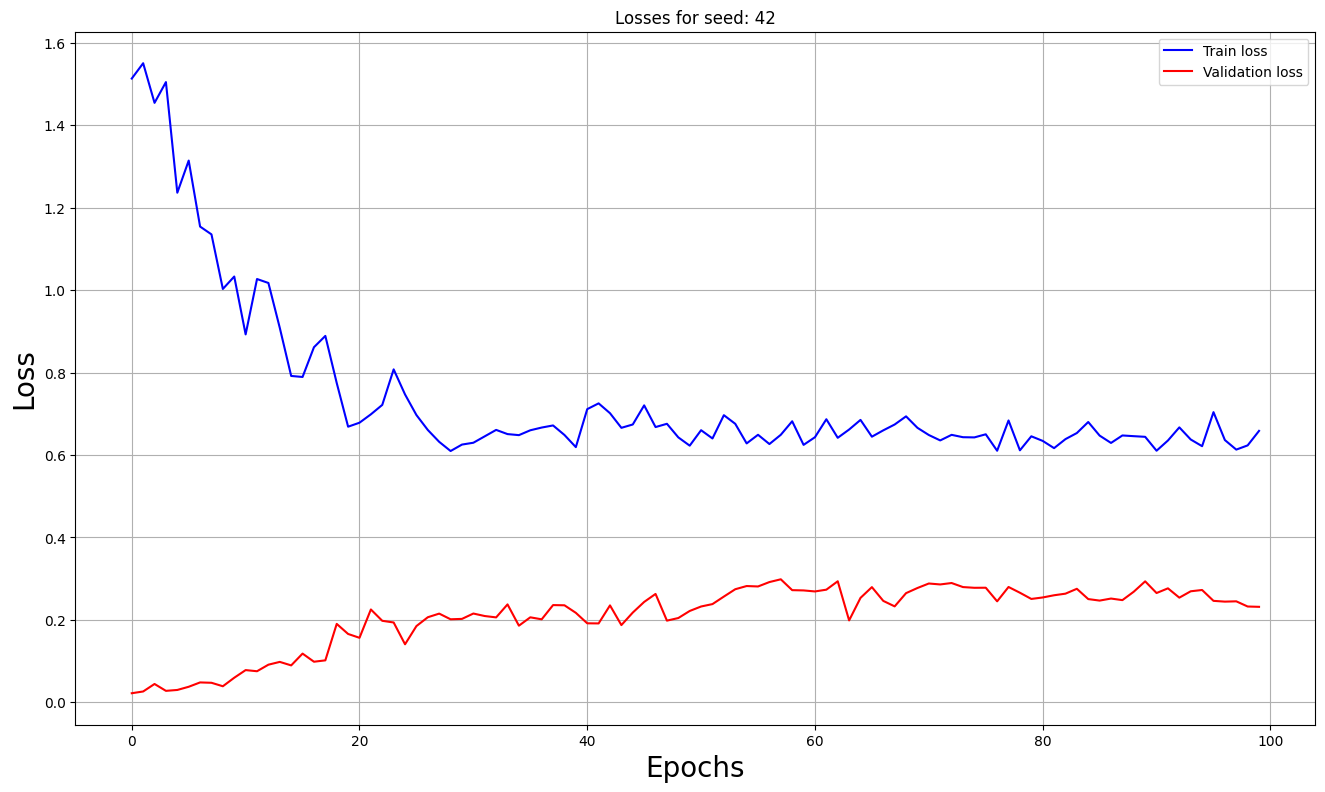

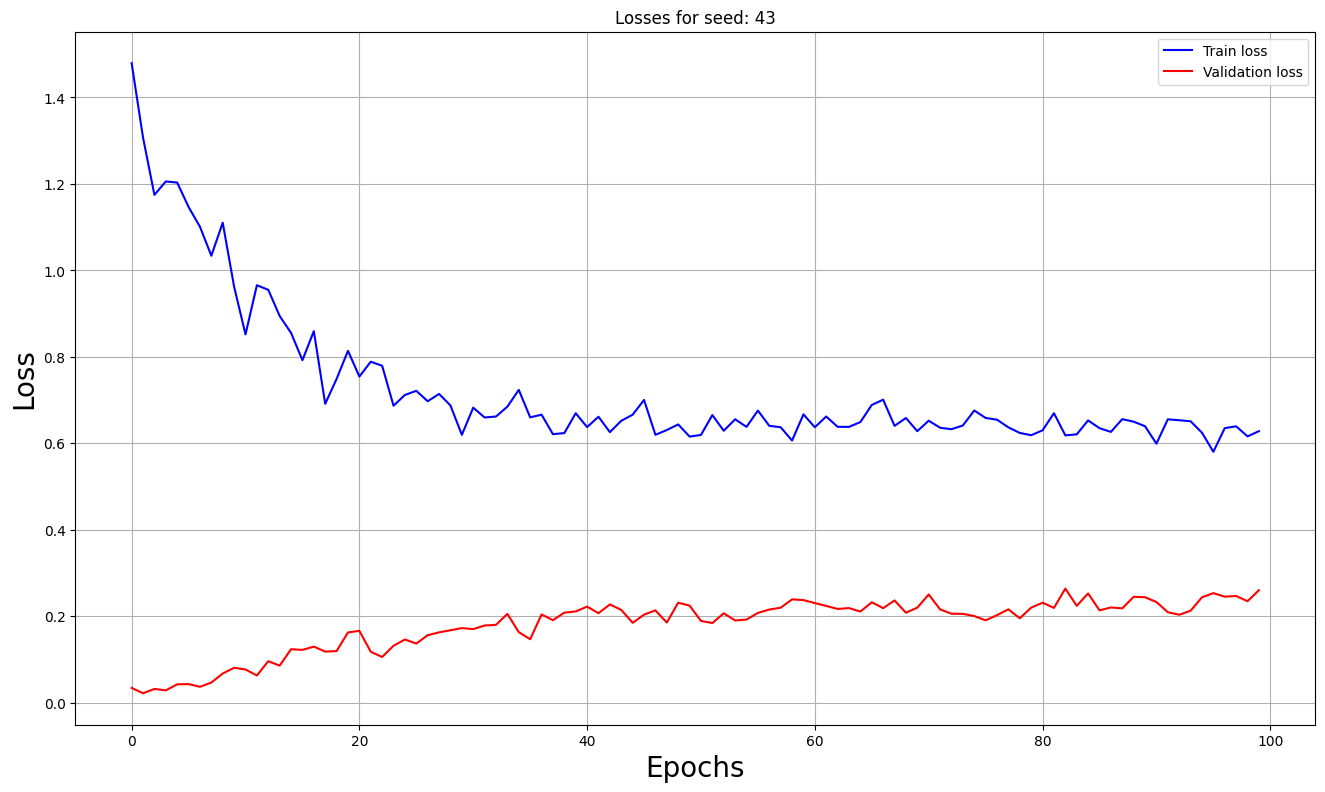

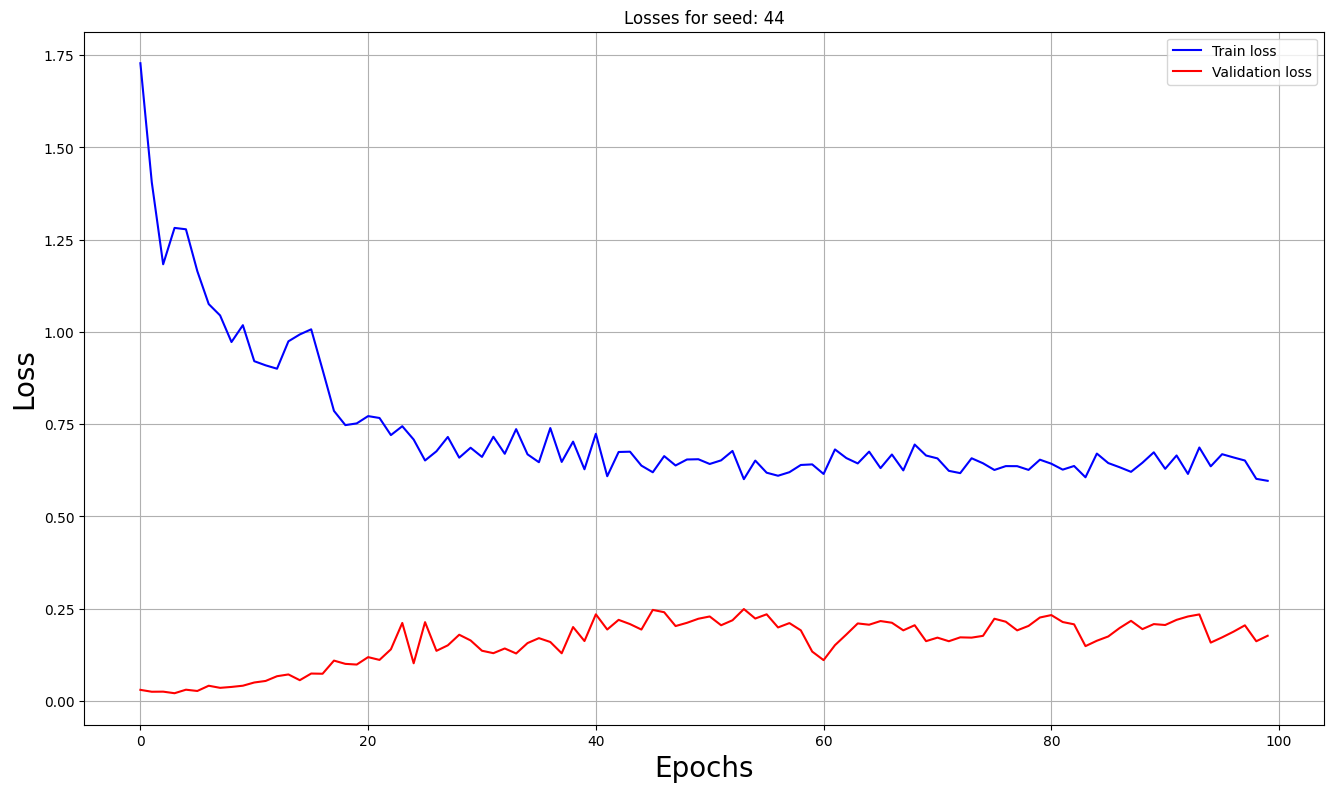

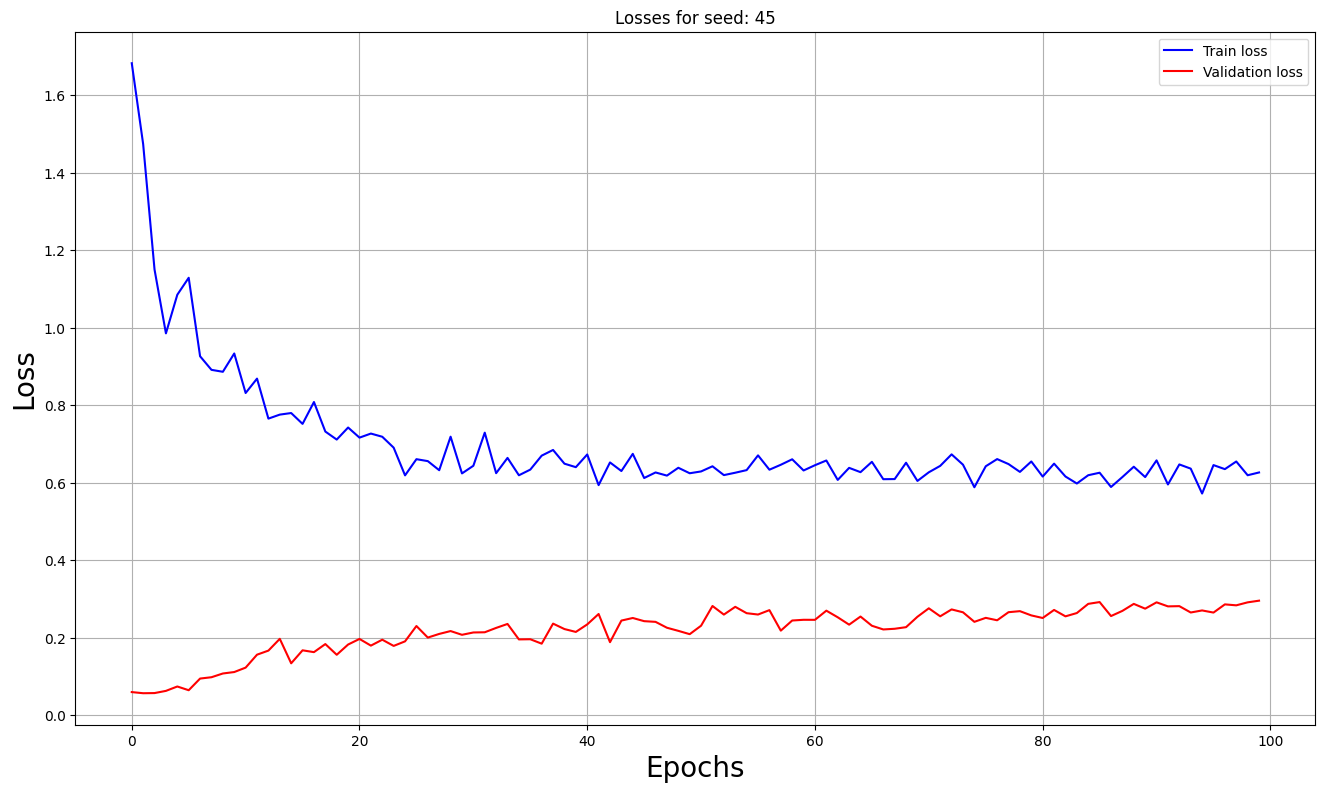

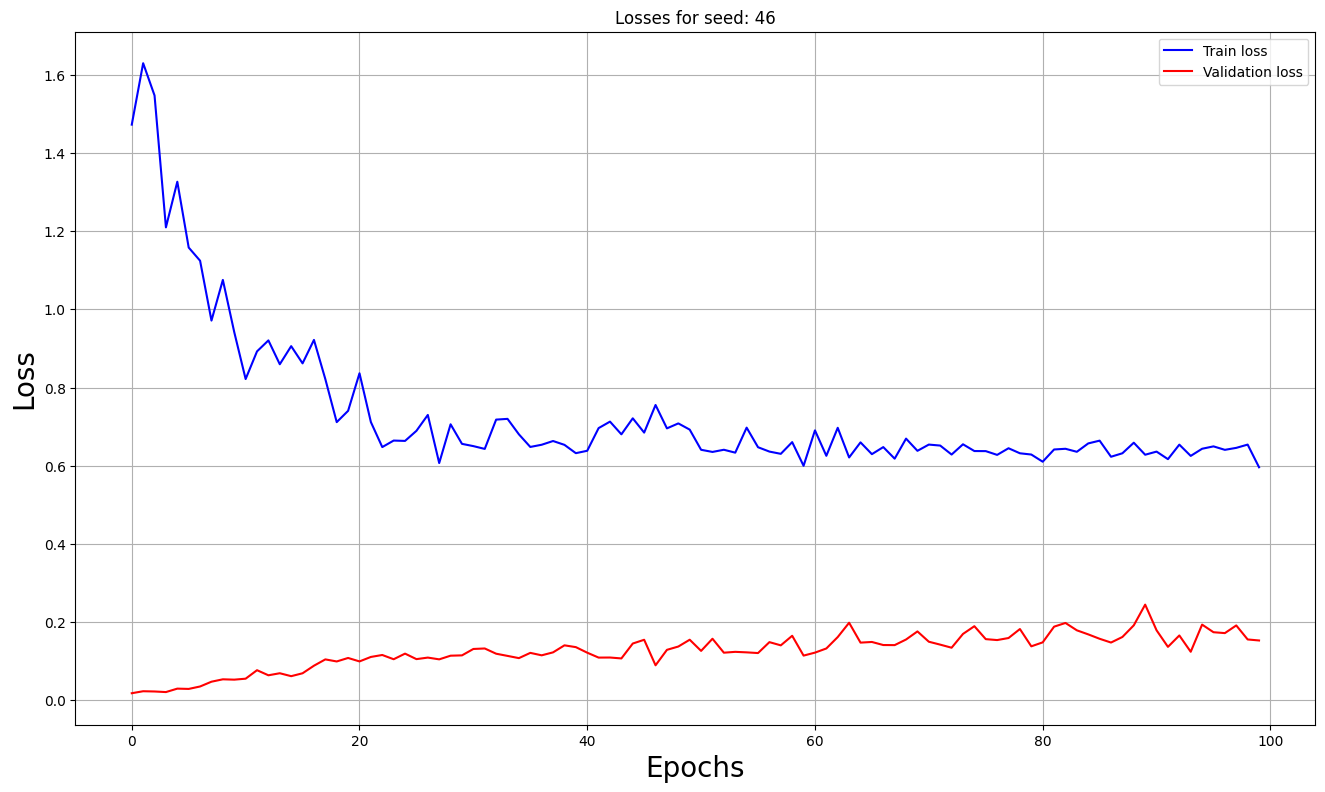

In [9]:
for seed in range(42, 47):
    def seed_everything(seed):
        import random
        import torch
        import numpy as np
    
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True
        
    seed_everything(seed)



    import pandas as pd
    import numpy as np
    import re
    from astropy.io import fits
    import matplotlib.pyplot as plt

    
    
    def parse_image(image_str):
        image_str = image_str.strip('[] ')
        
        rows = re.split(r'\]\s*\[', image_str)
        array = []
        for row in rows:
            elements = row.split()
            array.append([float(e) for e in elements])
        return np.array(array)
    
    # harps_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/data.csv', converters={'image': parse_image}))
    harps_images = pd.DataFrame(pd.read_pickle('/kaggle/input/harps-images/HARPS_data_with_candidates_and_phase.pkl'))
    # harps_images = pd.DataFrame(pd.read_pickle('/kaggle/input/harps-images/HARPS_data_with_candidates_and_phase_fast.pkl'))
    # harps_images = pd.DataFrame(pd.read_pickle('/kaggle/input/harps-images/HARPS_data_with_candidates_and_phase_slow.pkl'))
    # harps_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HARPS_GAFs_with_Candidates.csv', converters = {'image': parse_image}))
    # hires_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs.csv', converters={'image': parse_image}))
    hires_images = pd.DataFrame(pd.read_pickle('/kaggle/input/harps-images/HIRES_data_with_candidates_and_phase.pkl'))
    # hires_images = pd.DataFrame(pd.read_pickle('/kaggle/input/harps-images/HIRES_data_with_candidates_and_phase_fast.pkl'))
    # hires_images = pd.DataFrame(pd.read_pickle('/kaggle/input/harps-images/HIRES_data_with_candidates_and_phase_slow.pkl'))
    # hires_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs_with_candidates.csv', converters = {'image': parse_image}))
    hires_df = pd.read_csv('/kaggle/input/harps-n-dataset/preprocessed_HIRES_data.csv')
    with fits.open('/kaggle/input/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
        # Convert to native byte order immediately
            fits_data = data[1].data
            
            # Create DataFrame with native byte order arrays
            df_dict = {}
            for name in fits_data.dtype.names:
                arr = fits_data[name]
                # Convert to native byte order
                if not arr.dtype.isnative:
                    arr = arr.astype(arr.dtype.newbyteorder('='))
                df_dict[name] = arr
            
            harps_df = pd.DataFrame(df_dict)
    
    
    
    
    
    from torchvision import transforms
    
    
    
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    
    
    
    
    
    import torch
    from torch.utils.data import DataLoader, Dataset
    from sklearn.model_selection import train_test_split
    import random
    
    
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    
    positives = harps_images[harps_images['label'] == 1].sample(n=(len(harps_images[harps_images['label'] == 1])))
    negatives = harps_images[harps_images['label'] == 0].sample(n=(len(harps_images[harps_images['label'] == 1])))
    
    train_pos, temp_pos = train_test_split(positives, test_size=0.3, random_state=seed)
    val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=seed)  
    
    train_neg, temp_neg = train_test_split(negatives, test_size=0.3, random_state=seed)
    val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=seed)  
    
    
    
    hires_positives = hires_images[hires_images['label'] == 1].sample(n=(len(hires_images[hires_images['label'] == 1])))
    hires_negatives = hires_images[hires_images['label'] == 0].sample(n=(len(hires_images[hires_images['label'] == 1])))
    
    hires_train_pos, hires_temp_pos = train_test_split(hires_positives, test_size=0.3, random_state=seed)
    hires_val_pos, hires_test_pos = train_test_split(hires_temp_pos, test_size=0.5, random_state=seed)  
    
    hires_train_neg, hires_temp_neg = train_test_split(hires_negatives, test_size=0.3, random_state=seed)
    hires_val_neg, hires_test_neg = train_test_split(hires_temp_neg, test_size=0.5, random_state=seed)
    
    
    
    train_data = np.array((pd.concat([train_pos, train_neg, hires_train_pos, hires_train_neg]))['image'])
    val_data = np.array((pd.concat([val_pos, val_neg, hires_val_pos, hires_val_neg]))['image'])
    test_data = pd.concat([test_pos, test_neg, hires_test_pos, hires_test_neg])
    
    
    
    class TripletDataset(Dataset):
        def __init__(self, triplets):
            self.triplets = triplets
    
        def __len__(self):
            return len(self.triplets)
    
        def __getitem__(self, idx):
            anchor, pos, neg = self.triplets[idx]
            
            return anchor, pos, neg
    
    
    
    
    class ImageDataset(Dataset):
        def __init__(self, images, labels):
            self.data = images
            self.labels = labels
    
        def __len__(self):
            return len(self.data)
    
        def __getitem__(self, idx):
            image = torch.from_numpy(self.data[idx])
            label = torch.tensor(self.labels[idx])
    
            return image, label
    
    
    train_labels = []
    val_labels = []
    test_labels = []
    
    for i in range(len(train_pos) + len(hires_train_pos)):
        train_labels.append(1)
    for i in range(len(train_neg) + len(hires_train_neg)):
        train_labels.append(0)
    
    for i in range(len(val_pos) + len(hires_val_pos)):
        val_labels.append(1)
    for i in range(len(val_neg) + len(hires_val_neg)):
        val_labels.append(0)
    
    for i in range(len(test_pos) + len(hires_test_pos)):
        test_labels.append(1)
    for i in range(len(test_neg) + len(hires_test_neg)):
        test_labels.append(0)
    
    train_dataset = ImageDataset(train_data, train_labels)
    val_dataset = ImageDataset(val_data, val_labels)
    # test_dataset = ImageDataset(test_data, test_labels)
    
    
    batch_size = 32
    
    train_data = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        # batch_size = len(train_dataset),
        shuffle=True,
        drop_last=False,
        pin_memory=True if device.type == 'cuda' else False 
    )
    
    val_data = DataLoader(
        dataset=val_dataset,
        batch_size=batch_size,
        # batch_size = len(val_dataset),
        shuffle=False,
        drop_last=False,
        pin_memory=True if device.type == 'cuda' else False
    )


    test_pos = pd.concat([test_pos, hires_test_pos])
    test_neg = pd.concat([test_neg, hires_test_neg])
    
    # train_pos = pd.concat([train_pos, hires_train_pos])
    # train_neg = pd.concat([train_neg, hires_train_neg])
    
    # print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
    print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
    
    
    
    
    import torch.nn as nn
    import torch.nn.functional as F
    
    
    
    class HARPSNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = nn.Sequential(
                # Block 1: Input 1x128x128 -> Output 16x64x64
                nn.Conv2d(1, 16, kernel_size=3, padding=1),
                nn.BatchNorm2d(16),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
    
                # Block 2: Input 16x64x64 -> Output 32x32x32
                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
    
                # Block 3: Input 32x32x32 -> Output 64x16x16
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                
                # Block 4: Input 64x16x16 -> Output 128x8x8
                nn.Conv2d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
    
                nn.Flatten(),
                
                # The feature map is now 128 channels * 8 * 8 spatial size = 8192
                # This is the same size as before, but it contains much richer, 
                # high-level semantic info rather than low-level noise.
                nn.Linear(128 * 8 * 8, 512),
                nn.ReLU(inplace=True),
                nn.Dropout(0.5), # Increased dropout for the larger layer
                
                # Optional: Add a second linear layer if you have many classes
                # nn.Linear(512, 256) 
                # Note: If this is for classification, you'd usually add your final 
                # class projection here (e.g., nn.Linear(256, num_classes))
            )
    
        def forward(self, x):
            return self.encoder(x)
    
    
    
    
    model = HARPSNet()
    
    
    
    
    
    !pip install -q pytorch-metric-learning
    
    
    
    
    import torch.optim
    from pytorch_metric_learning import losses, miners
    from torch.optim.lr_scheduler import ReduceLROnPlateau
    
    
    
    model = model.to(device)
    
    
    
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.00001, momentum=0.9, weight_decay = 0.0001)
    # optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001, weight_decay = 0.0001)
    # optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0001, weight_decay = 0.01)
    
    # criterion = nn.BCELoss()
    # criterion = ContrastiveLoss()
    margin = 1.7
    criterion = nn.TripletMarginLoss(margin = margin, p = 2)
    
    # margin = 14.32394
    # margin = 1
    # criterion = losses.ArcFaceLoss(num_classes = 2, embedding_size = 256, margin = margin, scale = 64)
    optimizer = torch.optim.AdamW(model.parameters(), lr = 0.001, weight_decay = 0.1)
    
    
    
    miner = miners.TripletMarginMiner(
        margin=margin,
        type_of_triplets="semihard"
    )
    
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
                            
        factor=0.5,         
        patience=10,         
        min_lr=0.001,     
        verbose=True
    )
    
    
    
    train_losses = []
    val_losses = [100]
    epochs = 100
    patience = 10
    patience_counter = 0
    
    for epoch in range(epochs):
        epoch_loss = 0
        model.train()
        
        for images, labels in train_data:
            images = images.float().to(device)
            labels = labels.to(device)
    
            optimizer.zero_grad()
    
            current_embeddings = model.forward(images.view(-1, 1, 128, 128))
            hard_triplet_indices = miner(current_embeddings, labels)
            if hard_triplet_indices[0].shape[0] == 0:
                # print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping update.")
                continue
    
            emb_anchors = current_embeddings[hard_triplet_indices[0]]
            emb_positives = current_embeddings[hard_triplet_indices[1]]
            emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
            loss = criterion(emb_anchors, emb_positives, emb_negatives)
            # loss = criterion(current_embeddings, labels)
    
            loss.backward()
            optimizer.step()
    
            epoch_loss += loss.item()
    
        avg_train_loss = epoch_loss / len(train_data)
        train_losses.append(avg_train_loss)
    
    
        epoch_loss = 0
        model.eval()
        with torch.no_grad():
            for images, labels in val_data:
                images = images.float().to(device)
                labels = labels.to(device)
    
                current_embeddings = model.forward(images.view(-1, 1, 128, 128))
                hard_triplet_indices = miner(current_embeddings, labels)
                if hard_triplet_indices[0].shape[0] == 0:
                    # print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping.")
                    continue # Skip this batch if no triplets can be formed
        
                emb_anchors = current_embeddings[hard_triplet_indices[0]]
                emb_positives = current_embeddings[hard_triplet_indices[1]]
                emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
                loss = criterion(emb_anchors, emb_positives, emb_negatives)
                # loss = criterion(current_embeddings, labels)
        
                epoch_loss += loss.item()
                
        avg_val_loss = epoch_loss / len(val_data)
        val_losses.append(avg_val_loss)
        
    
        # if epoch % 100 == 0:
        #     print(f'Epoch: {epoch} | Average Train Loss: {avg_train_loss}\t Average Validation Loss: {avg_val_loss}')
    
    
        if avg_val_loss < val_losses[-2]:
            patience_counter = 0
        else:
            patience_counter += 1
    
    
        if avg_val_loss == sorted(val_losses)[0]:
            torch.save(model.state_dict(), '/kaggle/working/model.pth')
            # print(f'model saved at: \t{avg_val_loss}')
    
        
        if patience_counter >= patience:
            print("Patience reached")
            break
    
    
    val_losses.pop(0)
    print("Model training finished")

    plt.figure(figsize=(16,9))
    plt.plot(train_losses, c='b', label='Train loss')
    plt.plot(val_losses, c='r', label = 'Validation loss')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs', fontsize=20)
    plt.ylabel('Loss', fontsize=20)
    plt.title(f'Losses for seed: {seed}')
    
    
    
    
    
    import h5py as h5
    from astropy.timeseries import LombScargle
    
    
    
    def gen_periodogram(star_name):
            try:
                # Filter and clean data
                filtered = harps_df[harps_df['main_id_simbad'] == star_name]
                filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
                # Skip if insufficient data
                if len(filtered) < 3:
                    # Filter and clean data
                    filtered = hires_df[hires_df['main_id_simbad'] == star_name]
                    filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                    
                    # Skip if insufficient data
                    if len(filtered) < 3:
                        return 1, 1  # Placeholder for "not enough data"
                    
                    # Extract arrays with explicit native conversion
                    def to_native_float64(series):
                        arr = np.array(series)
                        if not arr.dtype.isnative:
                            arr = arr.astype(arr.dtype.newbyteorder('='))
                        return arr.astype(np.float64)
                    
                    time = to_native_float64(filtered['drs_bjd'])
                    rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
                    uncertainty = to_native_float64(filtered['drs_dvrms'])
                    
                    # Normalize timestamps for numerical stability
                    time -= np.min(time)
                    
                    # Generate periodogram
                    periodogram = LombScargle(time, rad_vel, uncertainty)
                    frequency, power = periodogram.autopower()
                    
                    # Resample to 1000 points
                    freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
                    power_interp = np.interp(freq_uniform, frequency, power)
                    
                    return freq_uniform, power_interp
                    
                
                # Extract arrays with explicit native conversion
                def to_native_float64(series):
                    arr = np.array(series)
                    if not arr.dtype.isnative:
                        arr = arr.astype(arr.dtype.newbyteorder('='))
                    return arr.astype(np.float64)
                
                time = to_native_float64(filtered['drs_bjd'])
                rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
                uncertainty = to_native_float64(filtered['drs_dvrms'])
                
                # Normalize timestamps for numerical stability
                time -= np.min(time)
                
                # Generate periodogram
                periodogram = LombScargle(time, rad_vel, uncertainty)
                frequency, power = periodogram.autopower()
                
                # Resample to 1000 points
                freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
                power_interp = np.interp(freq_uniform, frequency, power)
                
                return freq_uniform, power_interp
                
            except Exception as e:
                print(f"Error processing {star_name}: {e}")
                return 1, 1
    
    
    
    stars = list(test_data['star'])
    
    filename = "/kaggle/working/processed_data.h5"
    with h5.File(filename, 'w') as file:
            for star in stars:
                frequency, power = gen_periodogram(star)
                if type(frequency) == int:
                    pass
                else:
                    # star_group = file.create_group(clean_name(star))
                    star_group = file.create_group(star)
                    star_group.create_dataset('frequencies', data = frequency)
                    star_group.create_dataset('power', data = power)
    
    print("Test data h5 file created for Ante's model.")
    #Evaluate on test data using Ante's Model
    !python3 /kaggle/input/model-and-baselines-evaluation-data/modified_validateRealData.py /kaggle/working/processed_data.h5 /kaggle/input/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth --threshold 0.73 --catalog_path /kaggle/input/model-and-baselines-evaluation-data/catalog_of_exoplanets.csv
    
    
    preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
    star_level = pd.DataFrame(columns = preds.columns)
    # test_data = pd.DataFrame(pd.read_csv('/kaggle/input/model-and-baselines-evaluation-data/test_data.csv')).drop('Unnamed: 0', axis = 1)
    stars = list(set(preds['Star Name']))
    preds['Is True Planet'] = preds['Is True Planet'].astype(int)
    
    for i in range(len(stars)):
        star_level.loc[i, 'Star Name'] = stars[i]
    
    for i in range(len(preds)):
        if preds.iloc[i]['Prediction'] > 0.73:
            preds.loc[i, 'Prediction'] = 1.0
        else:
            preds.loc[i, 'Prediction'] = 0.0
    
        
        # if preds.iloc[i]['Is True Planet'] == True:
        #     preds.loc[i, 'Is True Planet'] = 1.0
        # else:
        #     preds.loc[i, 'Is True Planet'] = 0.0
    
    
    for i in range(len(stars)):
        star = stars[i]
        prediction = min(sum(list(preds[preds['Star Name'] == star]['Prediction'])), 1)
        star_level.loc[i, 'Prediction'] = prediction
    
        # label = sum(list(preds[preds['Star Name'] == star]['Is True Planet']))
        try:
            # label = test_data[test_data['star'] == star].iloc[0][-1]
            for idx in range(len(test_data)):
                if star in test_data.iloc[idx][0]:
                    label = test_data.iloc[idx][-1]
                    break
        except Exception as e:
            print(star)
            print(test_data[test_data['star'] == star])
        # print(label)
        try:
            star_level.loc[i, 'Is True Planet'] = label
        except Exception as e:
            print(e)
            print(test_data.iloc[idx][0])
    
    
    
    true_pos = 0
    true_neg = 0
    false_pos = 0
    false_neg = 0
    
    for i in range(len(star_level)):
        if star_level.iloc[i]['Prediction'] == star_level.iloc[i]['Is True Planet']:
            if star_level.iloc[i]['Is True Planet'] == 0.0:
                true_neg += 1
            elif star_level.iloc[i]['Is True Planet'] == 1.0:
                true_pos += 1
        else:
            if star_level.iloc[i]['Is True Planet'] == 0.0:
                false_pos += 1
            elif star_level.iloc[i]['Is True Planet'] == 1.0:
                false_neg += 1
    
    
    accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
    precision = true_pos / (true_pos + false_pos)
    recall = true_pos / (true_pos + false_neg)
    f1 = (2 * precision * recall) / (precision + recall)
    
    diplomski_accuracies.append(accuracy)
    diplomski_precisions.append(precision)
    diplomski_recalls.append(recall)
    diplomski_f1s.append(f1)
    
    
    
    
    
    preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
    pred_stars = list(set(preds['Star Name']))
    
    # test_df = pd.read_csv('/kaggle/working/test_data.csv', converters={'image': parse_image}).drop('Unnamed: 0', axis = 1)
    temp = pd.DataFrame(columns = test_data.columns)
    stars = list(test_data['star'])
    for pred_star in pred_stars:
        # print("".join(pred_star.split()))
        for star in stars:
            if "".join(pred_star.split()) == "".join(star.split()):
            # score = fuzz.ratio(pred_star, star)
            # if score >= 91:
                temp = pd.concat([temp, test_data[test_data['star'] == star]])
                break
    
    test_pos = temp[temp['label'] == 1]
    test_neg = temp[temp['label'] == 0]
    
    
    

    del model
    model = HARPSNet().to(device)
    model.load_state_dict(torch.load('/kaggle/working/model.pth'))
    model.eval()
    
    pos_embeddings = []
    
    with torch.no_grad():
        for i in range(len(train_pos)):
            image = torch.tensor(train_pos.iloc[i]['image']).float().to(device).view(1, -1, 128, 128)
            embedding = model.forward(image)
            pos_embeddings.append(embedding.detach())
            embedding = F.normalize(embedding, p=2, dim=1)
    
    stacked_embeddings = torch.cat(pos_embeddings, dim=0)
    mean_vector = torch.mean(stacked_embeddings, dim=0)
    pos_prototype = F.normalize(mean_vector, p=2, dim=0).view(1, -1)
    
    
    neg_embeddings = []
    
    with torch.no_grad():
        for i in range(len(train_neg)):
            image = torch.tensor(train_neg.iloc[i]['image']).float().to(device).view(1, -1, 128, 128)
            embedding = model.forward(image)
            neg_embeddings.append(embedding.detach())
            embedding = F.normalize(embedding, p=2, dim=1)
    
    stacked_embeddings = torch.cat(neg_embeddings, dim=0)
    mean_vector = torch.mean(stacked_embeddings, dim=0)
    neg_prototype = F.normalize(mean_vector, p=2, dim=0).view(1, -1)
    
    
    
    
    
    true_pos = 0
    true_neg = 0
    false_pos = 0
    false_neg = 0
    
    
    
    for idx in range(len(test_pos)):
        test_image = torch.tensor(test_pos.iloc[idx]['image']).float().to(device).view(1, -1, 128, 128)
    
        with torch.no_grad():
            embedding = model.forward(test_image)
    
        pos_sim = F.cosine_similarity(embedding, pos_prototype)
        neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
        if pos_sim > neg_sim:
            true_pos += 1
        else:
            false_neg += 1
    
    for idx in range(len(test_neg)):
        test_image = torch.tensor(test_neg.iloc[idx]['image']).float().to(device).view(1, -1, 128, 128)
    
        with torch.no_grad():
            embedding = model.forward(test_image)
    
        pos_sim = F.cosine_similarity(embedding, pos_prototype)
        neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
        if pos_sim > neg_sim:
            false_pos += 1
        else:
            true_neg += 1
    
    
    accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg) if (true_pos + true_neg + false_pos + false_neg) > 0 else 0
    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
    recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    siamese_accuracies.append(accuracy)
    siamese_precisions.append(precision)
    siamese_recalls.append(recall)
    siamese_f1s.append(f1)
    
    print("Model Evaluation Complete")
    
    
    
    
    
    def gen_pg(star_name):
        try:
            # Filter and clean data
            filtered = harps_df[harps_df['main_id_simbad'] == star_name]
            filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
            
            # Skip if insufficient data
            if len(filtered) < 3:
                filtered = hires_df[hires_df['main_id_simbad'] == star_name]
                filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
                # Skip if insufficient data
                if len(filtered) < 3:
                    return 1, 1  # Placeholder for "not enough data"
                
                # Extract arrays with explicit native conversion
                def to_native_float64(series):
                    arr = np.array(series)
                    if not arr.dtype.isnative:
                        arr = arr.astype(arr.dtype.newbyteorder('='))
                    return arr.astype(np.float64)
                
                time = to_native_float64(filtered['drs_bjd'])
                rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
                uncertainty = to_native_float64(filtered['drs_dvrms'])
                
                # Normalize timestamps for numerical stability
                time -= np.min(time)
                
                # Generate periodogram
                periodogram = LombScargle(time, rad_vel, uncertainty)
                frequency, power = periodogram.autopower()
                
                # Resample to 1000 points
                freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
                power_interp = np.interp(freq_uniform, frequency, power)
                
                return freq_uniform, power_interp
            
            # Extract arrays with explicit native conversion
            def to_native_float64(series):
                arr = np.array(series)
                if not arr.dtype.isnative:
                    arr = arr.astype(arr.dtype.newbyteorder('='))
                return arr.astype(np.float64)
            
            time = to_native_float64(filtered['drs_bjd'])
            rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
            uncertainty = to_native_float64(filtered['drs_dvrms'])
            
            # Normalize timestamps for numerical stability
            time -= np.min(time)
            
            # Generate periodogram
            periodogram = LombScargle(time, rad_vel, uncertainty)
            frequency, power = periodogram.autopower()
            
            # Resample to 1000 points
            freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
            power_interp = np.interp(freq_uniform, frequency, power)
            
            return freq_uniform, power_interp
            
        except Exception as e:
            print(f"Error processing {star_name}: {e}")
            return 1, 1
    
    
    def gen_peak_pow(power):
        peak_pow = max(list(power))
        peak = list(power).index(max(list(power)))
    
        return peak, peak_pow
    
    
    
    
    
    
    from tensorflow import keras
    from keras.models import Model
    # from keras.utils.vis_utils import plot_model
    from keras.utils import plot_model #I had to make this change, as the import statement above is not supported by current keras version
    from keras.models import load_model
    import tensorflow as tf
    
    
    
    model = load_model("/kaggle/input/model-and-baselines-evaluation-data/exoplANNET_trained.h5")
    
    def run_inference(star_name):
        freq, power = gen_pg(star_name)
        peak, peak_pow = gen_peak_pow(power)
    
        pg = np.transpose(np.array([power]))
        peak_pow = np.transpose(np.array([[peak, peak_pow]]))
    
        pg = np.expand_dims(pg, 0)
        peak_pow = np.expand_dims(peak_pow, 0)
    
        output = model.predict([pg, peak_pow])
        # print(output)
        if output < 0.77:
            output = 0
        else:
            output = 1
    
        return output
    
    
    
    predictions = {}
    for star in pred_stars:
        output = run_inference(star)
        predictions[star] = output
    
    
    
    
    
    true_pos = 0
    true_neg = 0
    false_pos = 0
    false_neg = 0
    
    
    for star in predictions:
        prediction = predictions[star]
        label = int(test_data[test_data['star'] == star]['label'])
    
        if label == 1:
            if prediction == 1:
                true_pos += 1
            else:
                false_neg += 1
        else:
            if prediction == 1:
                false_pos += 1
            else:
                true_neg += 1
    
    
    accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
    precision = true_pos / (true_pos + false_pos)
    recall = true_pos / (true_pos + false_neg)
    f1 = (2 * precision * recall) / (precision + recall)
    
    ExoplANNET_accuracies.append(accuracy)
    ExoplANNET_precisions.append(precision)
    ExoplANNET_recalls.append(recall)
    ExoplANNET_f1s.append(f1)
    
    print('ExoplANNET evaluation complete.')
    # break

In [10]:
# for seed in range(42, 47):
#     def seed_everything(seed):
#         import random
#         import torch
#         import numpy as np
    
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = True
        
#     seed_everything(seed)



#     import pandas as pd
#     import numpy as np
#     import re
#     from astropy.io import fits
#     import matplotlib.pyplot as plt

    
    
#     def parse_image(image_str):
#         image_str = image_str.strip('[] ')
        
#         rows = re.split(r'\]\s*\[', image_str)
#         array = []
#         for row in rows:
#             elements = row.split()
#             array.append([float(e) for e in elements])
#         return np.array(array)
    
#     # harps_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/data.csv', converters={'image': parse_image}))
#     harps_images = pd.DataFrame(pd.read_pickle('/kaggle/input/harps-images/HARPS_data_with_candidates_and_phase.pkl'))
#     # harps_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HARPS_GAFs_with_Candidates.csv', converters = {'image': parse_image}))
#     # hires_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs.csv', converters={'image': parse_image}))
#     hires_images = pd.DataFrame(pd.read_pickle('/kaggle/input/harps-images/HIRES_data_with_candidates_and_phase.pkl'))
#     # hires_images = pd.DataFrame(pd.read_csv('/kaggle/input/harps-images/HIRES_GAFs_with_candidates.csv', converters = {'image': parse_image}))
#     hires_df = pd.read_csv('/kaggle/input/harps-n-dataset/preprocessed_HIRES_data.csv')
#     with fits.open('/kaggle/input/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
#         # Convert to native byte order immediately
#             fits_data = data[1].data
            
#             # Create DataFrame with native byte order arrays
#             df_dict = {}
#             for name in fits_data.dtype.names:
#                 arr = fits_data[name]
#                 # Convert to native byte order
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 df_dict[name] = arr
            
#             harps_df = pd.DataFrame(df_dict)
    
    
    
    
    
#     from torchvision import transforms
    
    
    
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#     ])
    
    
    
    
    
#     import torch
#     from torch.utils.data import DataLoader, Dataset
#     from sklearn.model_selection import train_test_split
#     import random
    
    
    
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")
    
    
#     positives = harps_images[harps_images['label'] == 1].sample(n=(len(harps_images[harps_images['label'] == 1])))
#     negatives = harps_images[harps_images['label'] == 0].sample(n=(len(harps_images[harps_images['label'] == 1])))
    
#     train_pos, temp_pos = train_test_split(positives, test_size=0.3, random_state=seed)
#     val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=seed)  
    
#     train_neg, temp_neg = train_test_split(negatives, test_size=0.3, random_state=seed)
#     val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=seed)  
    
    
    
#     hires_positives = hires_images[hires_images['label'] == 1].sample(n=(len(hires_images[hires_images['label'] == 1])))
#     hires_negatives = hires_images[hires_images['label'] == 0].sample(n=(len(hires_images[hires_images['label'] == 1])))
    
#     hires_train_pos, hires_temp_pos = train_test_split(hires_positives, test_size=0.3, random_state=seed)
#     hires_val_pos, hires_test_pos = train_test_split(hires_temp_pos, test_size=0.5, random_state=seed)  
    
#     hires_train_neg, hires_temp_neg = train_test_split(hires_negatives, test_size=0.3, random_state=seed)
#     hires_val_neg, hires_test_neg = train_test_split(hires_temp_neg, test_size=0.5, random_state=seed)
    
    
    
#     train_data = np.array((pd.concat([train_pos, train_neg, hires_train_pos, hires_train_neg]))['image'])
#     val_data = np.array((pd.concat([val_pos, val_neg, hires_val_pos, hires_val_neg]))['image'])
#     test_data = pd.concat([test_pos, test_neg, hires_test_pos, hires_test_neg])
    
    
    
#     class TripletDataset(Dataset):
#         def __init__(self, triplets):
#             self.triplets = triplets
    
#         def __len__(self):
#             return len(self.triplets)
    
#         def __getitem__(self, idx):
#             anchor, pos, neg = self.triplets[idx]
            
#             return anchor, pos, neg
    
    
    
    
#     class ImageDataset(Dataset):
#         def __init__(self, images, labels):
#             self.data = images
#             self.labels = labels
    
#         def __len__(self):
#             return len(self.data)
    
#         def __getitem__(self, idx):
#             image = torch.from_numpy(self.data[idx])
#             label = torch.tensor(self.labels[idx])
    
#             return image, label
    
    
#     train_labels = []
#     val_labels = []
#     test_labels = []
    
#     for i in range(len(train_pos) + len(hires_train_pos)):
#         train_labels.append(1)
#     for i in range(len(train_neg) + len(hires_train_neg)):
#         train_labels.append(0)
    
#     for i in range(len(val_pos) + len(hires_val_pos)):
#         val_labels.append(1)
#     for i in range(len(val_neg) + len(hires_val_neg)):
#         val_labels.append(0)
    
#     for i in range(len(test_pos) + len(hires_test_pos)):
#         test_labels.append(1)
#     for i in range(len(test_neg) + len(hires_test_neg)):
#         test_labels.append(0)
    
#     train_dataset = ImageDataset(train_data, train_labels)
#     val_dataset = ImageDataset(val_data, val_labels)
#     # test_dataset = ImageDataset(test_data, test_labels)
    
    
#     batch_size = 32
    
#     train_data = DataLoader(
#         dataset=train_dataset,
#         batch_size=batch_size,
#         # batch_size = len(train_dataset),
#         shuffle=True,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False 
#     )
    
#     val_data = DataLoader(
#         dataset=val_dataset,
#         batch_size=batch_size,
#         # batch_size = len(val_dataset),
#         shuffle=False,
#         drop_last=False,
#         pin_memory=True if device.type == 'cuda' else False
#     )


#     test_pos = pd.concat([test_pos, hires_test_pos])
#     test_neg = pd.concat([test_neg, hires_test_neg])
    
#     # print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
#     print(f'Data splits created. Train size: {len(train_data) * batch_size} Val Size: {len(val_data) * batch_size} Test Size: {len(test_data)}')
    
    
    
    
#     import torch.nn as nn
#     import torch.nn.functional as F
    
    
    
#     class HARPSNet(nn.Module):
#         def __init__(self):
#             super().__init__()
#             self.encoder = nn.Sequential(
#                 # Block 1: Input 1x128x128 -> Output 16x64x64
#                 nn.Conv2d(1, 16, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(16),
#                 nn.ReLU(inplace=True),
#                 nn.MaxPool2d(2, 2),
        
#                 # Block 2: Input 16x64x64 -> Output 32x32x32
#                 nn.Conv2d(16, 32, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(32),
#                 nn.ReLU(inplace=True),
#                 nn.MaxPool2d(2, 2),
        
#                 # Block 3: Input 32x32x32 -> Output 64x16x16
#                 nn.Conv2d(32, 64, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(64),
#                 nn.ReLU(inplace=True),
#                 nn.MaxPool2d(2, 2),
                
#                 # Block 4: Input 64x16x16 -> Output 128x8x8
#                 nn.Conv2d(64, 128, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(128),
#                 nn.ReLU(inplace=True),
#                 nn.MaxPool2d(2, 2),
        
#                 # nn.Flatten(),
                
#                 # The feature map is now 128 channels * 8 * 8 spatial size = 8192
#                 # This is the same size as before, but it contains much richer, 
#                 # high-level semantic info rather than low-level noise.
#                 # nn.Linear(128 * 8 * 8, 512),
#                 # nn.ReLU(inplace=True),
#                 # nn.Dropout(0.5), # Increased dropout for the larger layer
                
#                 # Optional: Add a second linear layer if you have many classes
#                 # nn.Linear(512, 256)
#                 # Note: If this is for classification, you'd usually add your final 
#                 # class projection here (e.g., nn.Linear(256, num_classes))
    
                
#             )
    
#             self.norm = nn.LayerNorm(128)
#             self.mha = nn.MultiheadAttention(128, num_heads = 1, batch_first = 1)
#             self.scale = nn.Parameter(torch.zeros(1))

#             self.flatten = nn.Flatten()
#             self.linear = nn.Linear(128 * 8 * 8, 512)
#             self.relu = nn.ReLU(inplace = True)
#             self.do = nn.Dropout(0.5)
        
    
#         def use_attention(self, x):
#             bs, c, h, w = x.shape
#             x_att = x.reshape(bs, c, h * w).transpose(1, 2)  # BSxHWxC
            
#             # Apply Layer Normalization
#             x_att = self.norm(x_att)
#             # Apply Multi-head Attention
#             att_out, att_map  = self.mha(x_att, x_att, x_att)
#             return att_out.transpose(1, 2).reshape(bs, c, h, w), att_map
        
#         def forward(self, x):
#             x = self.encoder(x)
#             x = self.scale * self.use_attention(x)[0] + x
#             x = self.flatten(x)
#             x = self.linear(x)
#             x = self.relu(x)
#             x = self.do(x)
#             return x
    
    
    
    
#     model = HARPSNet()
    
    
    
    
    
#     !pip install -q pytorch-metric-learning
    
    
    
    
#     import torch.optim
#     from pytorch_metric_learning import losses, miners
#     from torch.optim.lr_scheduler import ReduceLROnPlateau
    
    
    
#     model = model.to(device)
    
    
    
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
#     # optimizer = torch.optim.SGD(model.parameters(), lr=0.00001, momentum=0.9, weight_decay = 0.0001)
#     # optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001, weight_decay = 0.0001)
#     # optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0001, weight_decay = 0.01)
    
#     # criterion = nn.BCELoss()
#     # criterion = ContrastiveLoss()
#     margin = 0.7
#     criterion = nn.TripletMarginLoss(margin = margin, p = 1)
    
#     # margin = 14.32394
#     # margin = 1
#     # criterion = losses.ArcFaceLoss(num_classes = 2, embedding_size = 256, margin = margin, scale = 64)
#     optimizer = torch.optim.AdamW(model.parameters(), lr = 0.00001, weight_decay = 0.1)
    
    
    
#     miner = miners.TripletMarginMiner(
#         margin=margin,
#         type_of_triplets="semihard"
#     )
    
#     scheduler = ReduceLROnPlateau(
#         optimizer,
#         mode='min',         
                            
#         factor=0.5,         
#         patience=10,         
#         min_lr=0.001,     
#         verbose=True        
#     )
    
    
    
#     train_losses = []
#     val_losses = [100]
#     epochs = 1000
#     patience = 10
#     patience_counter = 0
    
#     for epoch in range(epochs):
#         epoch_loss = 0
#         model.train()
        
#         for images, labels in train_data:
#             images = images.float().to(device)
#             labels = labels.to(device)
    
#             optimizer.zero_grad()
    
#             current_embeddings = model.forward(images.view(-1, 1, 128, 128))
#             hard_triplet_indices = miner(current_embeddings, labels)
#             if hard_triplet_indices[0].shape[0] == 0:
#                 # print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping update.")
#                 continue
    
#             emb_anchors = current_embeddings[hard_triplet_indices[0]]
#             emb_positives = current_embeddings[hard_triplet_indices[1]]
#             emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#             loss = criterion(emb_anchors, emb_positives, emb_negatives)
#             # loss = criterion(current_embeddings, labels)
    
#             loss.backward()
#             optimizer.step()
    
#             epoch_loss += loss.item()
    
#         avg_train_loss = epoch_loss / len(train_data)
#         train_losses.append(avg_train_loss)
    
    
#         epoch_loss = 0
#         model.eval()
#         with torch.no_grad():
#             for images, labels in val_data:
#                 images = images.float().to(device)
#                 labels = labels.to(device)
    
#                 current_embeddings = model.forward(images.view(-1, 1, 128, 128))
#                 hard_triplet_indices = miner(current_embeddings, labels)
#                 if hard_triplet_indices[0].shape[0] == 0:
#                     # print(f"Epoch {epoch}: No semi-hard triplets found in this batch. Skipping.")
#                     continue # Skip this batch if no triplets can be formed
        
#                 emb_anchors = current_embeddings[hard_triplet_indices[0]]
#                 emb_positives = current_embeddings[hard_triplet_indices[1]]
#                 emb_negatives = current_embeddings[hard_triplet_indices[2]]
            
#                 loss = criterion(emb_anchors, emb_positives, emb_negatives)
#                 # loss = criterion(current_embeddings, labels)
        
#                 epoch_loss += loss.item()
                
#         avg_val_loss = epoch_loss / len(val_data)
#         val_losses.append(avg_val_loss)
        
    
#         # if epoch % 100 == 0:
#         #     print(f'Epoch: {epoch} | Average Train Loss: {avg_train_loss}\t Average Validation Loss: {avg_val_loss}')
    
    
#         if avg_val_loss < val_losses[-2]:
#             patience_counter = 0
#         else:
#             patience_counter += 1
    
    
#         if avg_val_loss == sorted(val_losses)[0]:
#             torch.save(model.state_dict(), '/kaggle/working/model.pth')
#             # print(f'model saved at: \t{avg_val_loss}')
    
        
#         if patience_counter >= patience:
#             print("Patience reached")
#             break
    
    
#     val_losses.pop(0)
#     print("Model training finished")

#     plt.figure(figsize=(16,9))
#     plt.plot(train_losses, c='b', label='Train loss')
#     plt.plot(val_losses, c='r', label = 'Validation loss')
#     plt.legend()
#     plt.grid()
#     plt.xlabel('Epochs', fontsize=20)
#     plt.ylabel('Loss', fontsize=20)
#     plt.title(f'Losses for seed: {seed}')
    
    
    
    
    
#     import h5py as h5
#     from astropy.timeseries import LombScargle
    
    
    
#     def gen_periodogram(star_name):
#             try:
#                 # Filter and clean data
#                 filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     # Filter and clean data
#                     filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                     filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                    
#                     # Skip if insufficient data
#                     if len(filtered) < 3:
#                         return 1, 1  # Placeholder for "not enough data"
                    
#                     # Extract arrays with explicit native conversion
#                     def to_native_float64(series):
#                         arr = np.array(series)
#                         if not arr.dtype.isnative:
#                             arr = arr.astype(arr.dtype.newbyteorder('='))
#                         return arr.astype(np.float64)
                    
#                     time = to_native_float64(filtered['drs_bjd'])
#                     rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                     uncertainty = to_native_float64(filtered['drs_dvrms'])
                    
#                     # Normalize timestamps for numerical stability
#                     time -= np.min(time)
                    
#                     # Generate periodogram
#                     periodogram = LombScargle(time, rad_vel, uncertainty)
#                     frequency, power = periodogram.autopower()
                    
#                     # Resample to 1000 points
#                     freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                     power_interp = np.interp(freq_uniform, frequency, power)
                    
#                     return freq_uniform, power_interp
                    
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 1000)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
                
#             except Exception as e:
#                 print(f"Error processing {star_name}: {e}")
#                 return 1, 1
    
    
    
#     stars = list(test_data['star'])
    
#     filename = "/kaggle/working/processed_data.h5"
#     with h5.File(filename, 'w') as file:
#             for star in stars:
#                 frequency, power = gen_periodogram(star)
#                 if type(frequency) == int:
#                     pass
#                 else:
#                     # star_group = file.create_group(clean_name(star))
#                     star_group = file.create_group(star)
#                     star_group.create_dataset('frequencies', data = frequency)
#                     star_group.create_dataset('power', data = power)
    
#     print("Test data h5 file created for Ante's model.")
#     #Evaluate on test data using Ante's Model
#     !python3 /kaggle/input/model-and-baselines-evaluation-data/modified_validateRealData.py /kaggle/working/processed_data.h5 /kaggle/input/model-and-baselines-evaluation-data/top_current_model_trained_on_uneven_data_fully.pth --threshold 0.73 --catalog_path /kaggle/input/model-and-baselines-evaluation-data/catalog_of_exoplanets.csv
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     star_level = pd.DataFrame(columns = preds.columns)
#     # test_data = pd.DataFrame(pd.read_csv('/kaggle/input/model-and-baselines-evaluation-data/test_data.csv')).drop('Unnamed: 0', axis = 1)
#     stars = list(set(preds['Star Name']))
#     preds['Is True Planet'] = preds['Is True Planet'].astype(int)
    
#     for i in range(len(stars)):
#         star_level.loc[i, 'Star Name'] = stars[i]
    
#     for i in range(len(preds)):
#         if preds.iloc[i]['Prediction'] > 0.73:
#             preds.loc[i, 'Prediction'] = 1.0
#         else:
#             preds.loc[i, 'Prediction'] = 0.0
    
        
#         # if preds.iloc[i]['Is True Planet'] == True:
#         #     preds.loc[i, 'Is True Planet'] = 1.0
#         # else:
#         #     preds.loc[i, 'Is True Planet'] = 0.0
    
    
#     for i in range(len(stars)):
#         star = stars[i]
#         prediction = min(sum(list(preds[preds['Star Name'] == star]['Prediction'])), 1)
#         star_level.loc[i, 'Prediction'] = prediction
    
#         # label = sum(list(preds[preds['Star Name'] == star]['Is True Planet']))
#         try:
#             # label = test_data[test_data['star'] == star].iloc[0][-1]
#             for idx in range(len(test_data)):
#                 if star in test_data.iloc[idx][0]:
#                     label = test_data.iloc[idx][-1]
#                     break
#         except Exception as e:
#             print(star)
#             print(test_data[test_data['star'] == star])
#         # print(label)
#         try:
#             star_level.loc[i, 'Is True Planet'] = label
#         except Exception as e:
#             print(e)
#             print(test_data.iloc[idx][0])
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
#     for i in range(len(star_level)):
#         if star_level.iloc[i]['Prediction'] == star_level.iloc[i]['Is True Planet']:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 true_neg += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 true_pos += 1
#         else:
#             if star_level.iloc[i]['Is True Planet'] == 0.0:
#                 false_pos += 1
#             elif star_level.iloc[i]['Is True Planet'] == 1.0:
#                 false_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     diplomski_accuracies.append(accuracy)
#     diplomski_precisions.append(precision)
#     diplomski_recalls.append(recall)
#     diplomski_f1s.append(f1)
    
    
    
    
    
#     preds = pd.DataFrame(pd.read_csv('/kaggle/working/planet_predictions.csv'))
#     pred_stars = list(set(preds['Star Name']))
    
#     # test_df = pd.read_csv('/kaggle/working/test_data.csv', converters={'image': parse_image}).drop('Unnamed: 0', axis = 1)
#     temp = pd.DataFrame(columns = test_data.columns)
#     stars = list(test_data['star'])
#     for pred_star in pred_stars:
#         # print("".join(pred_star.split()))
#         for star in stars:
#             if "".join(pred_star.split()) == "".join(star.split()):
#             # score = fuzz.ratio(pred_star, star)
#             # if score >= 91:
#                 temp = pd.concat([temp, test_data[test_data['star'] == star]])
#                 break
    
#     test_pos = temp[temp['label'] == 1]
#     test_neg = temp[temp['label'] == 0]
    
    
    

#     del model
#     model = HARPSNet().to(device)
#     model.load_state_dict(torch.load('/kaggle/working/model.pth'))
#     model.eval()
    
#     pos_embeddings = []
    
#     with torch.no_grad():
#         for i in range(len(train_pos)):
#             image = torch.tensor(train_pos.iloc[i]['image']).float().to(device).view(1, -1, 128, 128)
#             embedding = model.forward(image)
#             pos_embeddings.append(embedding.detach())
#             embedding = F.normalize(embedding, p=2, dim=1)
    
#     stacked_embeddings = torch.cat(pos_embeddings, dim=0)
#     mean_vector = torch.mean(stacked_embeddings, dim=0)
#     pos_prototype = F.normalize(mean_vector, p=2, dim=0).view(1, -1)
    
    
#     neg_embeddings = []
    
#     with torch.no_grad():
#         for i in range(len(train_neg)):
#             image = torch.tensor(train_neg.iloc[i]['image']).float().to(device).view(1, -1, 128, 128)
#             embedding = model.forward(image)
#             neg_embeddings.append(embedding.detach())
#             embedding = F.normalize(embedding, p=2, dim=1)
    
#     stacked_embeddings = torch.cat(neg_embeddings, dim=0)
#     mean_vector = torch.mean(stacked_embeddings, dim=0)
#     neg_prototype = F.normalize(mean_vector, p=2, dim=0).view(1, -1)
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
    
#     for idx in range(len(test_pos)):
#         test_image = torch.tensor(test_pos.iloc[idx]['image']).float().to(device).view(1, -1, 128, 128)
    
#         with torch.no_grad():
#             embedding = model.forward(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             true_pos += 1
#         else:
#             false_neg += 1
    
#     for idx in range(len(test_neg)):
#         test_image = torch.tensor(test_neg.iloc[idx]['image']).float().to(device).view(1, -1, 128, 128)
    
#         with torch.no_grad():
#             embedding = model.forward(test_image)
    
#         pos_sim = F.cosine_similarity(embedding, pos_prototype)
#         neg_sim = F.cosine_similarity(embedding, neg_prototype)
    
#         if pos_sim > neg_sim:
#             false_pos += 1
#         else:
#             true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg) if (true_pos + true_neg + false_pos + false_neg) > 0 else 0
#     precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
#     recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
#     f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
#     siamese_accuracies.append(accuracy)
#     siamese_precisions.append(precision)
#     siamese_recalls.append(recall)
#     siamese_f1s.append(f1)
    
#     print("Model Evaluation Complete")
    
    
    
    
    
#     def gen_pg(star_name):
#         try:
#             # Filter and clean data
#             filtered = harps_df[harps_df['main_id_simbad'] == star_name]
#             filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
            
#             # Skip if insufficient data
#             if len(filtered) < 3:
#                 filtered = hires_df[hires_df['main_id_simbad'] == star_name]
#                 filtered = filtered.dropna(subset=['drs_bjd', 'drs_ccf_rvc', 'drs_dvrms'])
                
#                 # Skip if insufficient data
#                 if len(filtered) < 3:
#                     return 1, 1  # Placeholder for "not enough data"
                
#                 # Extract arrays with explicit native conversion
#                 def to_native_float64(series):
#                     arr = np.array(series)
#                     if not arr.dtype.isnative:
#                         arr = arr.astype(arr.dtype.newbyteorder('='))
#                     return arr.astype(np.float64)
                
#                 time = to_native_float64(filtered['drs_bjd'])
#                 rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#                 uncertainty = to_native_float64(filtered['drs_dvrms'])
                
#                 # Normalize timestamps for numerical stability
#                 time -= np.min(time)
                
#                 # Generate periodogram
#                 periodogram = LombScargle(time, rad_vel, uncertainty)
#                 frequency, power = periodogram.autopower()
                
#                 # Resample to 1000 points
#                 freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#                 power_interp = np.interp(freq_uniform, frequency, power)
                
#                 return freq_uniform, power_interp
            
#             # Extract arrays with explicit native conversion
#             def to_native_float64(series):
#                 arr = np.array(series)
#                 if not arr.dtype.isnative:
#                     arr = arr.astype(arr.dtype.newbyteorder('='))
#                 return arr.astype(np.float64)
            
#             time = to_native_float64(filtered['drs_bjd'])
#             rad_vel = to_native_float64(filtered['drs_ccf_rvc'])
#             uncertainty = to_native_float64(filtered['drs_dvrms'])
            
#             # Normalize timestamps for numerical stability
#             time -= np.min(time)
            
#             # Generate periodogram
#             periodogram = LombScargle(time, rad_vel, uncertainty)
#             frequency, power = periodogram.autopower()
            
#             # Resample to 1000 points
#             freq_uniform = np.linspace(frequency.min(), frequency.max(), 990)
#             power_interp = np.interp(freq_uniform, frequency, power)
            
#             return freq_uniform, power_interp
            
#         except Exception as e:
#             print(f"Error processing {star_name}: {e}")
#             return 1, 1
    
    
#     def gen_peak_pow(power):
#         peak_pow = max(list(power))
#         peak = list(power).index(max(list(power)))
    
#         return peak, peak_pow
    
    
    
    
    
    
#     from tensorflow import keras
#     from keras.models import Model
#     # from keras.utils.vis_utils import plot_model
#     from keras.utils import plot_model #I had to make this change, as the import statement above is not supported by current keras version
#     from keras.models import load_model
#     import tensorflow as tf
    
    
    
#     model = load_model("/kaggle/input/model-and-baselines-evaluation-data/exoplANNET_trained.h5")
    
#     def run_inference(star_name):
#         freq, power = gen_pg(star_name)
#         peak, peak_pow = gen_peak_pow(power)
    
#         pg = np.transpose(np.array([power]))
#         peak_pow = np.transpose(np.array([[peak, peak_pow]]))
    
#         pg = np.expand_dims(pg, 0)
#         peak_pow = np.expand_dims(peak_pow, 0)
    
#         output = model.predict([pg, peak_pow])
#         # print(output)
#         if output < 0.77:
#             output = 0
#         else:
#             output = 1
    
#         return output
    
    
    
#     predictions = {}
#     for star in pred_stars:
#         output = run_inference(star)
#         predictions[star] = output
    
    
    
    
    
#     true_pos = 0
#     true_neg = 0
#     false_pos = 0
#     false_neg = 0
    
    
#     for star in predictions:
#         prediction = predictions[star]
#         label = int(test_data[test_data['star'] == star]['label'])
    
#         if label == 1:
#             if prediction == 1:
#                 true_pos += 1
#             else:
#                 false_neg += 1
#         else:
#             if prediction == 1:
#                 false_pos += 1
#             else:
#                 true_neg += 1
    
    
#     accuracy = (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)
#     precision = true_pos / (true_pos + false_pos)
#     recall = true_pos / (true_pos + false_neg)
#     f1 = (2 * precision * recall) / (precision + recall)
    
#     ExoplANNET_accuracies.append(accuracy)
#     ExoplANNET_precisions.append(precision)
#     ExoplANNET_recalls.append(recall)
#     ExoplANNET_f1s.append(f1)
    
#     print('ExoplANNET evaluation complete.')
#     # break

In [11]:
def std_dev(metric):
    mean = sum(metric)/len(metric)

    sq_diffs = 0
    for data in metric:
        diff = (data - mean) ** 2
        sq_diffs += diff
    sq_diffs = sq_diffs / len(metric)

    return sq_diffs ** 0.5

In [12]:
siamese_mean_accuracy = sum(siamese_accuracies)/len(siamese_accuracies)
siamese_mean_precision = sum(siamese_precisions)/len(siamese_precisions)
siamese_mean_recall = sum(siamese_recalls)/len(siamese_recalls)
siamese_mean_f1 = sum(siamese_f1s)/len(siamese_f1s)

print(f'siamese_mean_accuracy: {siamese_mean_accuracy}\tsiamese_accuracy_std_dev: {std_dev(siamese_accuracies)}')
print(f'siamese_mean_precision: {siamese_mean_precision}\tsiamese_precision_std_dev: {std_dev(siamese_precisions)}')
print(f'siamese_mean_recall: {siamese_mean_recall}\tsiamese_recall_std_dev: {std_dev(siamese_recalls)}')
print(f'siamese_mean_f1: {siamese_mean_f1}\tsiamese_f1_std_dev: {std_dev(siamese_f1s)}')

siamese_mean_accuracy: 0.548511179682427	siamese_accuracy_std_dev: 0.037798043881853885
siamese_mean_precision: 0.5319587924727032	siamese_precision_std_dev: 0.03193585533180514
siamese_mean_recall: 0.7807752732240438	siamese_recall_std_dev: 0.0688158266106125
siamese_mean_f1: 0.6316217454301798	siamese_f1_std_dev: 0.0369321156850044


In [13]:
diplomski_mean_accuracy = sum(diplomski_accuracies)/len(diplomski_accuracies)
diplomski_mean_precision = sum(diplomski_precisions)/len(diplomski_precisions)
diplomski_mean_recall = sum(diplomski_recalls)/len(diplomski_recalls)
diplomski_mean_f1 = sum(diplomski_f1s)/len(diplomski_f1s)

print(f'diplomski_mean_accuracy: {diplomski_mean_accuracy}\tdiplomski_accuracy_std_dev: {std_dev(diplomski_accuracies)}')
print(f'diplomski_mean_precision: {diplomski_mean_precision}\tdiplomski_precision_std_dev: {std_dev(diplomski_precisions)}')
print(f'diplomski_mean_recall: {diplomski_mean_recall}\tdiplomski_recall_std_dev: {std_dev(diplomski_recalls)}')
print(f'diplomski_mean_f1: {diplomski_mean_f1}\tdiplomski_f1_std_dev: {std_dev(diplomski_f1s)}')

diplomski_mean_accuracy: 0.5408001220297204	diplomski_accuracy_std_dev: 0.033061301156235214
diplomski_mean_precision: 0.6022524091489607	diplomski_precision_std_dev: 0.07850219193340088
diplomski_mean_recall: 0.23268994325346784	diplomski_recall_std_dev: 0.032701602203040754
diplomski_mean_f1: 0.3350124436459033	diplomski_f1_std_dev: 0.04361320296086055


In [14]:
ExoplANNET_mean_accuracy = sum(ExoplANNET_accuracies)/len(ExoplANNET_accuracies)
ExoplANNET_mean_precision = sum(ExoplANNET_precisions)/len(ExoplANNET_precisions)
ExoplANNET_mean_recall = sum(ExoplANNET_recalls)/len(ExoplANNET_recalls)
ExoplANNET_mean_f1 = sum(ExoplANNET_f1s)/len(ExoplANNET_f1s)

print(f'ExoplANNET_mean_accuracy: {ExoplANNET_mean_accuracy}\tExoplANNET_accuracy_std_dev: {std_dev(ExoplANNET_accuracies)}')
print(f'ExoplANNET_mean_precision: {ExoplANNET_mean_precision}\tExoplANNET_precision_std_dev: {std_dev(ExoplANNET_precisions)}')
print(f'ExoplANNET_mean_recall: {ExoplANNET_mean_recall}\tExoplANNET_recall_std_dev: {std_dev(ExoplANNET_recalls)}')
print(f'ExoplANNET_mean_f1: {ExoplANNET_mean_f1}\tExoplANNET_f1_std_dev: {std_dev(ExoplANNET_f1s)}')

ExoplANNET_mean_accuracy: 0.5483097679393663	ExoplANNET_accuracy_std_dev: 0.021522625808458727
ExoplANNET_mean_precision: 0.6304093567251462	ExoplANNET_precision_std_dev: 0.052488434321209046
ExoplANNET_mean_recall: 0.2262739071038251	ExoplANNET_recall_std_dev: 0.03181662094198041
ExoplANNET_mean_f1: 0.33175657675657677	ExoplANNET_f1_std_dev: 0.03783253978476465
